In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler

current_dir = Path.cwd()
project_root = current_dir.parents[2]

full_set_path_HY3 = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/HY3/FULL_SET/'
full_set_path_HY4 = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/HY4/FULL_SET/'
full_set_path_MCID = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/MCID/FULL_SET/'

feature_selection_path_HY3 = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/HY3/FEATURE_SELECTION/'
feature_selection_path_HY4 = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/HY4/FEATURE_SELECTION/'
feature_selection_path_MCID = project_root / 'SCRIPTS/PYTHON/MODEL ANALYSIS/MODEL_PERFORMANCE_RESULTS/CLASSIFICATION/MCID/FEATURE_SELECTION/'


classification_models = {
    "decision_tree": DecisionTreeClassifier(random_state=42),

    "random_forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"

    ),

    "extra_trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "xgboost": XGBClassifier(
    tree_method="hist",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
    ),

    "adaboost": AdaBoostClassifier(
        algorithm="SAMME",
        random_state=42
    ),

    "svm": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "logistic_regression": LogisticRegression(
        random_state=42,
        n_jobs=-1,
        max_iter=10000,
        class_weight="balanced"
    ),

    "knn": KNeighborsClassifier(
        n_jobs=-1
    ),

    "gaussian_nb": GaussianNB()

    
}

In [5]:
import json

with open(project_root/"SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/Domain_data.json", "r") as archivo:
    datos = json.load(archivo)

print(datos)


{'M_data': ['NP1COG_mean', 'NP1COG_min', 'NP1COG_max', 'NP1COG_var', 'NP1COG_std', 'NP1HALL_mean', 'NP1HALL_min', 'NP1HALL_max', 'NP1HALL_var', 'NP1HALL_std', 'NP1DPRS_mean', 'NP1DPRS_min', 'NP1DPRS_max', 'NP1DPRS_var', 'NP1DPRS_std', 'NP1ANXS_mean', 'NP1ANXS_min', 'NP1ANXS_max', 'NP1ANXS_var', 'NP1ANXS_std', 'NP1APAT_mean', 'NP1APAT_min', 'NP1APAT_max', 'NP1APAT_var', 'NP1APAT_std', 'NP1DDS_mean', 'NP1DDS_min', 'NP1DDS_max', 'NP1DDS_var', 'NP1DDS_std', 'NP1SLPN_mean', 'NP1SLPN_min', 'NP1SLPN_max', 'NP1SLPN_var', 'NP1SLPN_std', 'NP1SLPD_mean', 'NP1SLPD_min', 'NP1SLPD_max', 'NP1SLPD_var', 'NP1SLPD_std', 'NP1PAIN_mean', 'NP1PAIN_min', 'NP1PAIN_max', 'NP1PAIN_var', 'NP1PAIN_std', 'NP1URIN_mean', 'NP1URIN_min', 'NP1URIN_max', 'NP1URIN_var', 'NP1URIN_std', 'NP1CNST_mean', 'NP1CNST_min', 'NP1CNST_max', 'NP1CNST_var', 'NP1CNST_std', 'NP1LTHD_mean', 'NP1LTHD_min', 'NP1LTHD_max', 'NP1LTHD_var', 'NP1LTHD_std', 'NP1FATG_mean', 'NP1FATG_min', 'NP1FATG_max', 'NP1FATG_var', 'NP1FATG_std', 'NP2SPCH_m

In [6]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd


def evaluate_models_10x10_oof_and_test(
    X_df: pd.DataFrame,
    y_df: pd.DataFrame,
    models: dict,
    scaler = StandardScaler(),
    outer_splits: int = 10,
    inner_splits: int = 10,
    test_size: float = 0.3,
    random_state: int = 42,
    decimals: int = 4,
):
    y = y_df.iloc[:, 0].to_numpy()
    X = X_df.to_numpy()
    classes = np.unique(y)

    def build_pipeline(estimator):
        return Pipeline([
            ("scaler", scaler),
            ("model", clone(estimator)),
        ])

    def compute_metrics(y_true, y_pred, y_proba):
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "AUC_macro": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
            "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
            "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
            "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "AUC_weighted": roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted"),
        }

    def summarize(metrics_list, suffix):
        df = pd.DataFrame(metrics_list)
        mean = df.mean()
        std = df.std(ddof=1)
        return {
            f"{col}_{suffix}": f"{mean[col]:.{decimals}f} ± {std[col]:.{decimals}f}"
            for col in df.columns
        }


    outer = StratifiedShuffleSplit(
        n_splits=outer_splits,
        test_size=test_size,
        random_state=random_state
    )

    test_summary_rows = []
    cv_summary_rows = []

    for model_name, estimator in models.items():
        print(f"Evaluating {model_name}...")

        test_metrics_all = []
        cv_metrics_all = []

        for train_idx, test_idx in outer.split(X, y):
            X_train, y_train = X[train_idx], y[train_idx]
            X_test, y_test = X[test_idx], y[test_idx]

            inner = StratifiedKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=random_state
            )

            oof_pred = np.zeros(len(y_train), dtype=y_train.dtype)
            oof_proba = np.zeros((len(y_train), len(classes)))

            for tr_idx, val_idx in inner.split(X_train, y_train):
                X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
                X_val = X_train[val_idx]

                model = build_pipeline(estimator)
                model.fit(X_tr, y_tr)

                oof_pred[val_idx] = model.predict(X_val)

                fold_proba = model.predict_proba(X_val)
                fold_classes = model.named_steps["model"].classes_

                aligned_proba = np.zeros((len(val_idx), len(classes)))
                for j, cls in enumerate(fold_classes):
                    aligned_proba[:, np.where(classes == cls)[0][0]] = fold_proba[:, j]

                oof_proba[val_idx] = aligned_proba

            cv_metrics_all.append(compute_metrics(y_train, oof_pred, oof_proba))

            model_full = build_pipeline(estimator)
            model_full.fit(X_train, y_train)

            test_pred = model_full.predict(X_test)
            test_proba_raw = model_full.predict_proba(X_test)
            test_classes = model_full.named_steps["model"].classes_

            test_proba = np.zeros((len(y_test), len(classes)))
            for j, cls in enumerate(test_classes):
                test_proba[:, np.where(classes == cls)[0][0]] = test_proba_raw[:, j]

            test_metrics_all.append(compute_metrics(y_test, test_pred, test_proba))

        test_summary_rows.append(
            pd.Series(summarize(test_metrics_all, "Testing"), name=model_name)
        )
        cv_summary_rows.append(
            pd.Series(summarize(cv_metrics_all, "CV"), name=model_name)
        )

    df_test_summary = pd.DataFrame(test_summary_rows)[[
        "Accuracy_Testing",
        "Precision_macro_Testing", "Recall_macro_Testing", "F1_macro_Testing", "AUC_macro_Testing",
        "Precision_weighted_Testing", "Recall_weighted_Testing", "F1_weighted_Testing", "AUC_weighted_Testing"
    ]]

    df_cv_summary = pd.DataFrame(cv_summary_rows)[[
        "Accuracy_CV",
        "Precision_macro_CV", "Recall_macro_CV", "F1_macro_CV", "AUC_macro_CV",
        "Precision_weighted_CV", "Recall_weighted_CV", "F1_weighted_CV", "AUC_weighted_CV"
    ]]

    df_final_summary = pd.concat([df_test_summary, df_cv_summary], axis=1)
    return df_final_summary

# ALL SET OF FEATURES SC M AND NM

## HY3

In [7]:
X_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)
y_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_data shape:", X_HY3_data.shape)
print("y_HY3_data shape:", y_HY3_data.shape)
X_HY3_data.head()

X_HY3_data shape: (909, 931)
y_HY3_data shape: (909, 1)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCAALTTM_mean,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,...,NP3PTRMR_std,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,1.000000,1.000000,1.0,1.0,...,0.577350,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350
3018,0,0,0.0,1.0,16.0,63.6,1.000000,0.666667,1.0,1.0,...,1.527525,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525
3020,0,0,0.0,1.0,15.0,77.0,0.666667,0.666667,1.0,1.0,...,1.154701,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701
3028,0,0,1.0,1.0,22.0,78.8,1.000000,1.000000,1.0,1.0,...,0.000000,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525
3051,0,0,1.0,1.0,18.0,74.7,1.000000,1.000000,1.0,1.0,...,0.577350,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350


In [8]:
df_HY3_full = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_data, 
    y_df=y_HY3_data, 
    models=classification_models, 
    random_state=42
)

df_HY3_full.to_csv(full_set_path_HY3 / "HY3_full_StandardScaler.csv", index=False)
df_HY3_full.head(10)



Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8267 ± 0.0251,0.6040 ± 0.0442,0.6074 ± 0.0463,0.6021 ± 0.0390,0.7507 ± 0.0264,0.8280 ± 0.0192,0.8267 ± 0.0251,0.8267 ± 0.0219,0.8409 ± 0.0202,0.8206 ± 0.0086,0.6249 ± 0.0272,0.6242 ± 0.0361,0.6223 ± 0.0294,0.7565 ± 0.0183,0.8206 ± 0.0104,0.8206 ± 0.0086,0.8203 ± 0.0090,0.8333 ± 0.0097
random_forest,0.8974 ± 0.0147,0.5985 ± 0.0098,0.6150 ± 0.0100,0.6064 ± 0.0099,0.9397 ± 0.0155,0.8750 ± 0.0141,0.8974 ± 0.0147,0.8857 ± 0.0145,0.9569 ± 0.0062,0.8981 ± 0.0074,0.5991 ± 0.0049,0.6166 ± 0.0051,0.6077 ± 0.0050,0.9514 ± 0.0073,0.8727 ± 0.0072,0.8981 ± 0.0074,0.8852 ± 0.0073,0.9594 ± 0.0029
extra_trees,0.8963 ± 0.0132,0.5984 ± 0.0084,0.6142 ± 0.0093,0.6060 ± 0.0087,0.9492 ± 0.0101,0.8748 ± 0.0124,0.8963 ± 0.0132,0.8851 ± 0.0127,0.9582 ± 0.0063,0.8987 ± 0.0052,0.6001 ± 0.0036,0.6171 ± 0.0036,0.6085 ± 0.0036,0.9545 ± 0.0105,0.8741 ± 0.0051,0.8987 ± 0.0052,0.8863 ± 0.0052,0.9608 ± 0.0033
xgboost,0.8982 ± 0.0153,0.7947 ± 0.1228,0.6841 ± 0.0537,0.7066 ± 0.0703,0.9334 ± 0.0214,0.8939 ± 0.0208,0.8982 ± 0.0153,0.8924 ± 0.0167,0.9584 ± 0.0076,0.8962 ± 0.0044,0.7758 ± 0.0609,0.6701 ± 0.0295,0.6915 ± 0.0403,0.9433 ± 0.0132,0.8890 ± 0.0060,0.8962 ± 0.0044,0.8897 ± 0.0048,0.9571 ± 0.0039
adaboost,0.8755 ± 0.0244,0.7191 ± 0.0958,0.6762 ± 0.0395,0.6820 ± 0.0429,0.9096 ± 0.0124,0.8758 ± 0.0211,0.8755 ± 0.0244,0.8739 ± 0.0219,0.9210 ± 0.0155,0.8725 ± 0.0052,0.7402 ± 0.0293,0.7082 ± 0.0352,0.7202 ± 0.0303,0.9178 ± 0.0136,0.8703 ± 0.0072,0.8725 ± 0.0052,0.8708 ± 0.0064,0.9222 ± 0.0101
svm,0.8905 ± 0.0169,0.5938 ± 0.0113,0.6106 ± 0.0117,0.6016 ± 0.0114,0.9426 ± 0.0164,0.8687 ± 0.0166,0.8905 ± 0.0169,0.8787 ± 0.0166,0.9517 ± 0.0086,0.8877 ± 0.0049,0.5920 ± 0.0033,0.6096 ± 0.0033,0.6007 ± 0.0033,0.9474 ± 0.0075,0.8626 ± 0.0047,0.8877 ± 0.0049,0.8750 ± 0.0048,0.9543 ± 0.0035
logistic_regression,0.8678 ± 0.0094,0.6930 ± 0.0662,0.6850 ± 0.0618,0.6860 ± 0.0606,0.9085 ± 0.0298,0.8657 ± 0.0117,0.8678 ± 0.0094,0.8656 ± 0.0101,0.9321 ± 0.0082,0.8722 ± 0.0121,0.7336 ± 0.0302,0.7021 ± 0.0284,0.7143 ± 0.0282,0.9125 ± 0.0159,0.8690 ± 0.0119,0.8722 ± 0.0121,0.8702 ± 0.0119,0.9361 ± 0.0092
knn,0.7447 ± 0.0182,0.5580 ± 0.1063,0.5244 ± 0.0199,0.5070 ± 0.0315,0.7830 ± 0.0190,0.7784 ± 0.0151,0.7447 ± 0.0182,0.7261 ± 0.0206,0.8632 ± 0.0191,0.7454 ± 0.0121,0.5540 ± 0.1056,0.5234 ± 0.0088,0.5041 ± 0.0126,0.7785 ± 0.0110,0.7701 ± 0.0131,0.7454 ± 0.0121,0.7265 ± 0.0134,0.8583 ± 0.0111
gaussian_nb,0.6978 ± 0.0815,0.5980 ± 0.0139,0.6086 ± 0.0705,0.5440 ± 0.0528,0.7712 ± 0.0428,0.8489 ± 0.0135,0.6978 ± 0.0815,0.7438 ± 0.0701,0.8711 ± 0.0112,0.7042 ± 0.0778,0.5991 ± 0.0201,0.6120 ± 0.0658,0.5543 ± 0.0532,0.7723 ± 0.0360,0.8435 ± 0.0185,0.7042 ± 0.0778,0.7518 ± 0.0628,0.8666 ± 0.0140


In [9]:
df_HY3_full_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_data, 
    y_df=y_HY3_data, 
    models=classification_models,
    scaler = MinMaxScaler(), 
    random_state=42
)
df_HY3_full_min_max.to_csv(full_set_path_HY3 / "HY3_full_MinMaxScaler.csv", index=False)
df_HY3_full_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8286 ± 0.0249,0.6134 ± 0.0469,0.6131 ± 0.0465,0.6092 ± 0.0404,0.7540 ± 0.0273,0.8301 ± 0.0201,0.8286 ± 0.0249,0.8287 ± 0.0222,0.8424 ± 0.0204,0.8203 ± 0.0078,0.6250 ± 0.0272,0.6239 ± 0.0363,0.6222 ± 0.0296,0.7563 ± 0.0184,0.8204 ± 0.0099,0.8203 ± 0.0078,0.8200 ± 0.0084,0.8329 ± 0.0093
random_forest,0.8982 ± 0.0137,0.5989 ± 0.0092,0.6156 ± 0.0093,0.6068 ± 0.0093,0.9397 ± 0.0165,0.8757 ± 0.0132,0.8982 ± 0.0137,0.8864 ± 0.0135,0.9567 ± 0.0067,0.8980 ± 0.0079,0.5990 ± 0.0053,0.6165 ± 0.0054,0.6076 ± 0.0053,0.9515 ± 0.0074,0.8726 ± 0.0076,0.8980 ± 0.0079,0.8851 ± 0.0077,0.9594 ± 0.0028
extra_trees,0.8963 ± 0.0132,0.5984 ± 0.0084,0.6142 ± 0.0093,0.6060 ± 0.0087,0.9492 ± 0.0101,0.8748 ± 0.0124,0.8963 ± 0.0132,0.8851 ± 0.0127,0.9582 ± 0.0063,0.8987 ± 0.0052,0.6001 ± 0.0036,0.6171 ± 0.0036,0.6085 ± 0.0036,0.9545 ± 0.0105,0.8741 ± 0.0051,0.8987 ± 0.0052,0.8863 ± 0.0052,0.9608 ± 0.0033
xgboost,0.8982 ± 0.0153,0.7947 ± 0.1228,0.6841 ± 0.0537,0.7066 ± 0.0703,0.9334 ± 0.0214,0.8939 ± 0.0208,0.8982 ± 0.0153,0.8924 ± 0.0167,0.9584 ± 0.0076,0.8964 ± 0.0046,0.7725 ± 0.0609,0.6685 ± 0.0308,0.6891 ± 0.0417,0.9431 ± 0.0132,0.8890 ± 0.0067,0.8964 ± 0.0046,0.8897 ± 0.0054,0.9571 ± 0.0039
adaboost,0.8755 ± 0.0244,0.7191 ± 0.0958,0.6762 ± 0.0395,0.6820 ± 0.0429,0.9096 ± 0.0124,0.8758 ± 0.0211,0.8755 ± 0.0244,0.8739 ± 0.0219,0.9210 ± 0.0155,0.8725 ± 0.0052,0.7402 ± 0.0293,0.7082 ± 0.0352,0.7202 ± 0.0303,0.9178 ± 0.0136,0.8703 ± 0.0072,0.8725 ± 0.0052,0.8708 ± 0.0064,0.9222 ± 0.0101
svm,0.8978 ± 0.0095,0.5988 ± 0.0062,0.6166 ± 0.0062,0.6065 ± 0.0065,0.9446 ± 0.0166,0.8769 ± 0.0087,0.8978 ± 0.0095,0.8858 ± 0.0095,0.9555 ± 0.0096,0.9009 ± 0.0062,0.6004 ± 0.0041,0.6200 ± 0.0042,0.6096 ± 0.0042,0.9498 ± 0.0071,0.8763 ± 0.0060,0.9009 ± 0.0062,0.8877 ± 0.0061,0.9574 ± 0.0033
logistic_regression,0.8725 ± 0.0102,0.7000 ± 0.0675,0.6932 ± 0.0615,0.6937 ± 0.0612,0.9131 ± 0.0186,0.8704 ± 0.0098,0.8725 ± 0.0102,0.8702 ± 0.0099,0.9364 ± 0.0081,0.8794 ± 0.0083,0.7312 ± 0.0342,0.7059 ± 0.0311,0.7159 ± 0.0319,0.9234 ± 0.0124,0.8766 ± 0.0082,0.8794 ± 0.0083,0.8774 ± 0.0080,0.9399 ± 0.0081
knn,0.7458 ± 0.0229,0.5240 ± 0.0099,0.5203 ± 0.0145,0.5001 ± 0.0173,0.7830 ± 0.0264,0.7745 ± 0.0141,0.7458 ± 0.0229,0.7277 ± 0.0260,0.8590 ± 0.0209,0.7454 ± 0.0131,0.5168 ± 0.0077,0.5209 ± 0.0086,0.5014 ± 0.0094,0.7886 ± 0.0055,0.7609 ± 0.0112,0.7454 ± 0.0131,0.7278 ± 0.0139,0.8575 ± 0.0100
gaussian_nb,0.7040 ± 0.0844,0.5998 ± 0.0160,0.6128 ± 0.0706,0.5480 ± 0.0552,0.7767 ± 0.0416,0.8508 ± 0.0156,0.7040 ± 0.0844,0.7489 ± 0.0734,0.8794 ± 0.0099,0.7107 ± 0.0750,0.6005 ± 0.0194,0.6162 ± 0.0645,0.5586 ± 0.0516,0.7784 ± 0.0349,0.8445 ± 0.0173,0.7107 ± 0.0750,0.7570 ± 0.0602,0.8753 ± 0.0110


## HY4

In [10]:
X_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_data shape:", X_HY4_data.shape)
print("y_HY4_data shape:", y_HY4_data.shape)

X_HY4_data shape: (909, 931)
y_HY4_data shape: (909, 1)


In [11]:
df_HY4_full = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_data, 
    y_df=y_HY4_data, 
    models=classification_models, 
    random_state=42
)
df_HY4_full.to_csv(full_set_path_HY4 / "HY4_full_StandardScaler.csv", index=False)
df_HY4_full.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7125 ± 0.0364,0.5103 ± 0.0363,0.5173 ± 0.0548,0.5108 ± 0.0426,0.7059 ± 0.0316,0.7271 ± 0.0317,0.7125 ± 0.0364,0.7183 ± 0.0339,0.7892 ± 0.0286,0.6964 ± 0.0141,0.4911 ± 0.0317,0.4892 ± 0.0333,0.4890 ± 0.0316,0.6890 ± 0.0184,0.7126 ± 0.0133,0.6964 ± 0.0141,0.7038 ± 0.0128,0.7777 ± 0.0105
random_forest,0.8352 ± 0.0116,0.4555 ± 0.0845,0.4840 ± 0.0074,0.4508 ± 0.0091,0.8928 ± 0.0134,0.7410 ± 0.0380,0.8352 ± 0.0116,0.7765 ± 0.0109,0.9304 ± 0.0069,0.8286 ± 0.0043,0.4403 ± 0.0788,0.4802 ± 0.0027,0.4454 ± 0.0031,0.8883 ± 0.0114,0.7299 ± 0.0340,0.8286 ± 0.0043,0.7693 ± 0.0040,0.9240 ± 0.0063
extra_trees,0.8370 ± 0.0098,0.4940 ± 0.1208,0.4890 ± 0.0136,0.4595 ± 0.0222,0.8818 ± 0.0127,0.7506 ± 0.0447,0.8370 ± 0.0098,0.7793 ± 0.0097,0.9243 ± 0.0066,0.8283 ± 0.0044,0.4405 ± 0.0789,0.4802 ± 0.0032,0.4461 ± 0.0047,0.8838 ± 0.0067,0.7301 ± 0.0343,0.8283 ± 0.0044,0.7695 ± 0.0042,0.9216 ± 0.0041
xgboost,0.8355 ± 0.0113,0.6621 ± 0.1049,0.5344 ± 0.0276,0.5344 ± 0.0350,0.8744 ± 0.0201,0.7966 ± 0.0232,0.8355 ± 0.0113,0.7951 ± 0.0096,0.9221 ± 0.0100,0.8176 ± 0.0085,0.6267 ± 0.0590,0.5109 ± 0.0206,0.5096 ± 0.0289,0.8601 ± 0.0127,0.7649 ± 0.0159,0.8176 ± 0.0085,0.7748 ± 0.0091,0.9127 ± 0.0066
adaboost,0.7883 ± 0.0206,0.5808 ± 0.0761,0.5504 ± 0.0618,0.5507 ± 0.0613,0.8493 ± 0.0128,0.7652 ± 0.0169,0.7883 ± 0.0206,0.7730 ± 0.0154,0.9015 ± 0.0091,0.7770 ± 0.0157,0.5912 ± 0.0428,0.5434 ± 0.0275,0.5575 ± 0.0316,0.8488 ± 0.0086,0.7602 ± 0.0129,0.7770 ± 0.0157,0.7668 ± 0.0137,0.8956 ± 0.0081
svm,0.8253 ± 0.0104,0.4128 ± 0.0054,0.4771 ± 0.0061,0.4424 ± 0.0056,0.8827 ± 0.0111,0.7152 ± 0.0093,0.8253 ± 0.0104,0.7658 ± 0.0096,0.9211 ± 0.0051,0.8181 ± 0.0064,0.4098 ± 0.0032,0.4738 ± 0.0037,0.4390 ± 0.0034,0.8754 ± 0.0077,0.7093 ± 0.0056,0.8181 ± 0.0064,0.7590 ± 0.0059,0.9151 ± 0.0046
logistic_regression,0.7491 ± 0.0226,0.5743 ± 0.0596,0.5467 ± 0.0428,0.5487 ± 0.0350,0.8157 ± 0.0197,0.7504 ± 0.0141,0.7491 ± 0.0226,0.7481 ± 0.0168,0.8815 ± 0.0067,0.7467 ± 0.0184,0.5423 ± 0.0295,0.5297 ± 0.0269,0.5345 ± 0.0271,0.8084 ± 0.0123,0.7432 ± 0.0156,0.7467 ± 0.0184,0.7446 ± 0.0168,0.8764 ± 0.0087
knn,0.6645 ± 0.0260,0.4497 ± 0.1006,0.3934 ± 0.0221,0.3781 ± 0.0318,0.7253 ± 0.0188,0.6465 ± 0.0252,0.6645 ± 0.0260,0.6164 ± 0.0283,0.8268 ± 0.0117,0.6604 ± 0.0114,0.4054 ± 0.0218,0.3870 ± 0.0052,0.3675 ± 0.0058,0.7149 ± 0.0097,0.6377 ± 0.0106,0.6604 ± 0.0114,0.6123 ± 0.0113,0.8157 ± 0.0040
gaussian_nb,0.4484 ± 0.0878,0.4513 ± 0.0444,0.4623 ± 0.0894,0.3514 ± 0.0670,0.7281 ± 0.0520,0.6981 ± 0.0481,0.4484 ± 0.0878,0.4800 ± 0.0808,0.8345 ± 0.0191,0.4442 ± 0.0608,0.4447 ± 0.0161,0.4449 ± 0.0366,0.3543 ± 0.0377,0.7122 ± 0.0202,0.6879 ± 0.0199,0.4442 ± 0.0608,0.4867 ± 0.0594,0.8181 ± 0.0109


In [12]:
df_HY4_full_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_data, 
    y_df=y_HY4_data, 
    models=classification_models,
    scaler = MinMaxScaler(), 
    random_state=42
)
df_HY4_full_min_max.to_csv(full_set_path_HY4 / "HY4_full_MinMaxScaler.csv", index=False)
df_HY4_full_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7128 ± 0.0361,0.5102 ± 0.0354,0.5169 ± 0.0540,0.5105 ± 0.0417,0.7058 ± 0.0309,0.7272 ± 0.0300,0.7128 ± 0.0361,0.7186 ± 0.0329,0.7895 ± 0.0277,0.6967 ± 0.0141,0.4921 ± 0.0321,0.4892 ± 0.0334,0.4894 ± 0.0319,0.6890 ± 0.0184,0.7125 ± 0.0130,0.6967 ± 0.0141,0.7039 ± 0.0128,0.7778 ± 0.0105
random_forest,0.8355 ± 0.0118,0.4557 ± 0.0847,0.4842 ± 0.0076,0.4510 ± 0.0094,0.8930 ± 0.0126,0.7413 ± 0.0384,0.8355 ± 0.0118,0.7768 ± 0.0112,0.9306 ± 0.0071,0.8292 ± 0.0049,0.4406 ± 0.0787,0.4805 ± 0.0029,0.4457 ± 0.0033,0.8866 ± 0.0106,0.7304 ± 0.0338,0.8292 ± 0.0049,0.7698 ± 0.0045,0.9233 ± 0.0063
extra_trees,0.8370 ± 0.0098,0.4940 ± 0.1208,0.4890 ± 0.0136,0.4595 ± 0.0222,0.8818 ± 0.0127,0.7506 ± 0.0447,0.8370 ± 0.0098,0.7793 ± 0.0097,0.9243 ± 0.0066,0.8283 ± 0.0044,0.4405 ± 0.0789,0.4802 ± 0.0032,0.4461 ± 0.0047,0.8838 ± 0.0067,0.7301 ± 0.0343,0.8283 ± 0.0044,0.7695 ± 0.0042,0.9216 ± 0.0041
xgboost,0.8355 ± 0.0113,0.6621 ± 0.1049,0.5344 ± 0.0276,0.5344 ± 0.0350,0.8754 ± 0.0199,0.7966 ± 0.0232,0.8355 ± 0.0113,0.7951 ± 0.0096,0.9223 ± 0.0099,0.8186 ± 0.0084,0.6305 ± 0.0577,0.5118 ± 0.0203,0.5106 ± 0.0284,0.8598 ± 0.0129,0.7669 ± 0.0152,0.8186 ± 0.0084,0.7756 ± 0.0089,0.9125 ± 0.0064
adaboost,0.7883 ± 0.0206,0.5808 ± 0.0761,0.5504 ± 0.0618,0.5507 ± 0.0613,0.8493 ± 0.0128,0.7652 ± 0.0169,0.7883 ± 0.0206,0.7730 ± 0.0154,0.9015 ± 0.0091,0.7770 ± 0.0157,0.5912 ± 0.0428,0.5434 ± 0.0275,0.5575 ± 0.0316,0.8488 ± 0.0087,0.7602 ± 0.0129,0.7770 ± 0.0157,0.7668 ± 0.0137,0.8956 ± 0.0081
svm,0.8344 ± 0.0086,0.4169 ± 0.0045,0.4822 ± 0.0052,0.4471 ± 0.0048,0.8844 ± 0.0137,0.7220 ± 0.0079,0.8344 ± 0.0086,0.7740 ± 0.0082,0.9216 ± 0.0062,0.8272 ± 0.0032,0.4134 ± 0.0016,0.4788 ± 0.0019,0.4436 ± 0.0018,0.8758 ± 0.0067,0.7150 ± 0.0028,0.8272 ± 0.0032,0.7669 ± 0.0029,0.9145 ± 0.0037
logistic_regression,0.7564 ± 0.0126,0.5728 ± 0.0671,0.5468 ± 0.0296,0.5484 ± 0.0282,0.8354 ± 0.0156,0.7645 ± 0.0124,0.7564 ± 0.0126,0.7585 ± 0.0102,0.8917 ± 0.0053,0.7426 ± 0.0121,0.5304 ± 0.0142,0.5208 ± 0.0165,0.5244 ± 0.0149,0.8252 ± 0.0086,0.7481 ± 0.0110,0.7426 ± 0.0121,0.7450 ± 0.0109,0.8830 ± 0.0045
knn,0.6560 ± 0.0106,0.3991 ± 0.0302,0.3828 ± 0.0089,0.3628 ± 0.0141,0.7484 ± 0.0226,0.6395 ± 0.0148,0.6560 ± 0.0106,0.6073 ± 0.0116,0.8369 ± 0.0126,0.6596 ± 0.0069,0.4052 ± 0.0202,0.3875 ± 0.0070,0.3683 ± 0.0106,0.7297 ± 0.0104,0.6394 ± 0.0115,0.6596 ± 0.0069,0.6118 ± 0.0086,0.8213 ± 0.0084
gaussian_nb,0.4747 ± 0.0614,0.4533 ± 0.0397,0.4745 ± 0.0708,0.3676 ± 0.0497,0.7342 ± 0.0515,0.6984 ± 0.0438,0.4747 ± 0.0614,0.5042 ± 0.0539,0.8412 ± 0.0182,0.4772 ± 0.0479,0.4496 ± 0.0145,0.4622 ± 0.0297,0.3745 ± 0.0289,0.7194 ± 0.0193,0.6917 ± 0.0179,0.4772 ± 0.0479,0.5161 ± 0.0421,0.8268 ± 0.0099


## HY4_3

In [13]:
X_HY43_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY43_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY4_3_data shape:", X_HY4_data.shape)
print("y_HY4_3_data shape:", y_HY4_data.shape)

X_HY4_3_data shape: (909, 931)
y_HY4_3_data shape: (909, 1)


In [14]:
df_HY43_full = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_data, 
    y_df=y_HY43_data, 
    models=classification_models, 
    random_state=42
)
df_HY43_full.to_csv(full_set_path_HY4 / "HY43_full_StandardScaler.csv", index=False)
df_HY43_full.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7586 ± 0.0285,0.6217 ± 0.0313,0.6191 ± 0.0352,0.6195 ± 0.0334,0.7482 ± 0.0236,0.7668 ± 0.0204,0.7586 ± 0.0285,0.7618 ± 0.0242,0.8160 ± 0.0193,0.7476 ± 0.0140,0.6108 ± 0.0188,0.6090 ± 0.0210,0.6096 ± 0.0199,0.7400 ± 0.0134,0.7566 ± 0.0117,0.7476 ± 0.0140,0.7519 ± 0.0127,0.8065 ± 0.0105
random_forest,0.8612 ± 0.0078,0.5747 ± 0.0061,0.6450 ± 0.0059,0.6077 ± 0.0059,0.8862 ± 0.0183,0.7675 ± 0.0082,0.8612 ± 0.0078,0.8115 ± 0.0078,0.9384 ± 0.0105,0.8558 ± 0.0031,0.5879 ± 0.0527,0.6403 ± 0.0025,0.6044 ± 0.0035,0.8852 ± 0.0067,0.7696 ± 0.0174,0.8558 ± 0.0031,0.8074 ± 0.0030,0.9361 ± 0.0040
extra_trees,0.8579 ± 0.0108,0.6396 ± 0.1438,0.6442 ± 0.0103,0.6095 ± 0.0138,0.8810 ± 0.0148,0.7870 ± 0.0512,0.8579 ± 0.0108,0.8095 ± 0.0113,0.9354 ± 0.0087,0.8558 ± 0.0048,0.6713 ± 0.1600,0.6418 ± 0.0046,0.6079 ± 0.0079,0.8774 ± 0.0086,0.7968 ± 0.0511,0.8558 ± 0.0048,0.8083 ± 0.0046,0.9328 ± 0.0042
xgboost,0.8509 ± 0.0069,0.6533 ± 0.0523,0.6481 ± 0.0117,0.6268 ± 0.0199,0.8805 ± 0.0123,0.7934 ± 0.0193,0.8509 ± 0.0069,0.8127 ± 0.0093,0.9331 ± 0.0072,0.8445 ± 0.0056,0.6775 ± 0.0481,0.6457 ± 0.0092,0.6287 ± 0.0150,0.8755 ± 0.0154,0.7974 ± 0.0170,0.8445 ± 0.0056,0.8089 ± 0.0070,0.9282 ± 0.0075
adaboost,0.8179 ± 0.0214,0.6702 ± 0.0372,0.6610 ± 0.0224,0.6610 ± 0.0262,0.8525 ± 0.0172,0.8012 ± 0.0164,0.8179 ± 0.0214,0.8073 ± 0.0168,0.9216 ± 0.0081,0.8053 ± 0.0089,0.6450 ± 0.0092,0.6447 ± 0.0079,0.6434 ± 0.0087,0.8343 ± 0.0119,0.7887 ± 0.0072,0.8053 ± 0.0089,0.7963 ± 0.0075,0.9127 ± 0.0055
svm,0.8531 ± 0.0103,0.5696 ± 0.0074,0.6390 ± 0.0077,0.6020 ± 0.0074,0.8668 ± 0.0164,0.7606 ± 0.0099,0.8531 ± 0.0103,0.8038 ± 0.0099,0.9260 ± 0.0101,0.8458 ± 0.0034,0.5643 ± 0.0023,0.6325 ± 0.0025,0.5963 ± 0.0024,0.8672 ± 0.0106,0.7549 ± 0.0031,0.8458 ± 0.0034,0.7975 ± 0.0032,0.9246 ± 0.0054
logistic_regression,0.7846 ± 0.0237,0.6315 ± 0.0270,0.6310 ± 0.0265,0.6303 ± 0.0268,0.8271 ± 0.0178,0.7812 ± 0.0186,0.7846 ± 0.0237,0.7821 ± 0.0205,0.8979 ± 0.0098,0.7799 ± 0.0133,0.6330 ± 0.0174,0.6334 ± 0.0176,0.6330 ± 0.0175,0.8245 ± 0.0164,0.7784 ± 0.0116,0.7799 ± 0.0133,0.7790 ± 0.0121,0.8939 ± 0.0093
knn,0.6956 ± 0.0225,0.5458 ± 0.0477,0.5263 ± 0.0211,0.5016 ± 0.0275,0.7661 ± 0.0204,0.6986 ± 0.0216,0.6956 ± 0.0225,0.6576 ± 0.0254,0.8465 ± 0.0174,0.6912 ± 0.0093,0.5570 ± 0.0243,0.5232 ± 0.0089,0.5010 ± 0.0124,0.7685 ± 0.0137,0.7025 ± 0.0092,0.6912 ± 0.0093,0.6541 ± 0.0101,0.8433 ± 0.0089
gaussian_nb,0.5205 ± 0.0796,0.6191 ± 0.0250,0.5541 ± 0.0618,0.4858 ± 0.0602,0.8006 ± 0.0223,0.7765 ± 0.0257,0.5205 ± 0.0796,0.5675 ± 0.0707,0.8694 ± 0.0163,0.4934 ± 0.0628,0.6072 ± 0.0161,0.5331 ± 0.0373,0.4655 ± 0.0456,0.7779 ± 0.0113,0.7652 ± 0.0186,0.4934 ± 0.0628,0.5461 ± 0.0579,0.8485 ± 0.0088


In [15]:
df_HY43_full_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_data, 
    y_df=y_HY43_data, 
    scaler = MinMaxScaler(),
    models=classification_models, 
    random_state=42
)
df_HY43_full_min_max.to_csv(full_set_path_HY4 / "HY43_full_MinMaxScaler.csv", index=False)
df_HY43_full_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7590 ± 0.0283,0.6219 ± 0.0311,0.6194 ± 0.0351,0.6198 ± 0.0333,0.7485 ± 0.0235,0.7671 ± 0.0201,0.7590 ± 0.0283,0.7622 ± 0.0240,0.8163 ± 0.0191,0.7473 ± 0.0138,0.6107 ± 0.0185,0.6088 ± 0.0206,0.6093 ± 0.0196,0.7399 ± 0.0133,0.7568 ± 0.0125,0.7473 ± 0.0138,0.7518 ± 0.0129,0.8065 ± 0.0108
random_forest,0.8615 ± 0.0082,0.5750 ± 0.0062,0.6452 ± 0.0062,0.6080 ± 0.0061,0.8863 ± 0.0181,0.7678 ± 0.0083,0.8615 ± 0.0082,0.8118 ± 0.0082,0.9385 ± 0.0102,0.8563 ± 0.0029,0.5882 ± 0.0526,0.6407 ± 0.0023,0.6047 ± 0.0034,0.8849 ± 0.0073,0.7700 ± 0.0172,0.8563 ± 0.0029,0.8079 ± 0.0028,0.9361 ± 0.0043
extra_trees,0.8579 ± 0.0108,0.6396 ± 0.1438,0.6442 ± 0.0103,0.6095 ± 0.0138,0.8810 ± 0.0148,0.7870 ± 0.0512,0.8579 ± 0.0108,0.8095 ± 0.0113,0.9354 ± 0.0087,0.8558 ± 0.0048,0.6713 ± 0.1600,0.6418 ± 0.0046,0.6079 ± 0.0079,0.8774 ± 0.0086,0.7968 ± 0.0511,0.8558 ± 0.0048,0.8083 ± 0.0046,0.9328 ± 0.0042
xgboost,0.8516 ± 0.0058,0.6567 ± 0.0514,0.6495 ± 0.0109,0.6290 ± 0.0196,0.8801 ± 0.0120,0.7952 ± 0.0186,0.8516 ± 0.0058,0.8139 ± 0.0085,0.9329 ± 0.0071,0.8440 ± 0.0053,0.6737 ± 0.0457,0.6449 ± 0.0091,0.6277 ± 0.0149,0.8758 ± 0.0154,0.7962 ± 0.0162,0.8440 ± 0.0053,0.8084 ± 0.0068,0.9283 ± 0.0075
adaboost,0.8179 ± 0.0214,0.6702 ± 0.0372,0.6610 ± 0.0224,0.6610 ± 0.0262,0.8525 ± 0.0172,0.8012 ± 0.0164,0.8179 ± 0.0214,0.8073 ± 0.0168,0.9216 ± 0.0081,0.8052 ± 0.0089,0.6449 ± 0.0093,0.6446 ± 0.0080,0.6432 ± 0.0089,0.8343 ± 0.0119,0.7885 ± 0.0074,0.8052 ± 0.0089,0.7961 ± 0.0076,0.9127 ± 0.0055
svm,0.8623 ± 0.0074,0.5752 ± 0.0050,0.6458 ± 0.0055,0.6083 ± 0.0053,0.8673 ± 0.0160,0.7680 ± 0.0067,0.8623 ± 0.0074,0.8122 ± 0.0071,0.9277 ± 0.0088,0.8542 ± 0.0041,0.5694 ± 0.0027,0.6387 ± 0.0031,0.6021 ± 0.0029,0.8665 ± 0.0101,0.7616 ± 0.0037,0.8542 ± 0.0041,0.8052 ± 0.0039,0.9256 ± 0.0056
logistic_regression,0.7938 ± 0.0261,0.6498 ± 0.0342,0.6488 ± 0.0353,0.6486 ± 0.0348,0.8406 ± 0.0139,0.7962 ± 0.0199,0.7938 ± 0.0261,0.7944 ± 0.0226,0.9077 ± 0.0083,0.7789 ± 0.0079,0.6355 ± 0.0110,0.6353 ± 0.0115,0.6351 ± 0.0112,0.8321 ± 0.0138,0.7838 ± 0.0043,0.7789 ± 0.0079,0.7812 ± 0.0058,0.9012 ± 0.0078
knn,0.6879 ± 0.0270,0.5734 ± 0.0593,0.5246 ± 0.0275,0.5032 ± 0.0357,0.7828 ± 0.0186,0.7058 ± 0.0219,0.6879 ± 0.0270,0.6503 ± 0.0306,0.8478 ± 0.0120,0.6869 ± 0.0060,0.5755 ± 0.0245,0.5240 ± 0.0042,0.5048 ± 0.0074,0.7800 ± 0.0108,0.7065 ± 0.0086,0.6869 ± 0.0060,0.6507 ± 0.0064,0.8472 ± 0.0104
gaussian_nb,0.5451 ± 0.0559,0.6235 ± 0.0193,0.5658 ± 0.0456,0.5059 ± 0.0390,0.8052 ± 0.0187,0.7814 ± 0.0204,0.5451 ± 0.0559,0.5939 ± 0.0436,0.8740 ± 0.0134,0.5269 ± 0.0471,0.6106 ± 0.0134,0.5496 ± 0.0278,0.4897 ± 0.0315,0.7851 ± 0.0109,0.7683 ± 0.0148,0.5269 ± 0.0471,0.5774 ± 0.0399,0.8551 ± 0.0079


## MCID

In [16]:
X_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)
y_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_data shape:", X_MCID_data.shape)
print("y_MCID_data shape:", y_MCID_data.shape)

X_MCID_data shape: (909, 936)
y_MCID_data shape: (909, 1)


In [17]:
df_MCID_full = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_data, 
    y_df=y_MCID_data, 
    models=classification_models, 
    random_state=42
)

df_MCID_full.to_csv(full_set_path_MCID / "MCID_full_StandardScaler.csv", index=False)
df_MCID_full.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4850 ± 0.0345,0.4121 ± 0.0307,0.4124 ± 0.0298,0.4111 ± 0.0301,0.5677 ± 0.0226,0.4893 ± 0.0289,0.4850 ± 0.0345,0.4861 ± 0.0313,0.5846 ± 0.0239,0.4882 ± 0.0234,0.4142 ± 0.0259,0.4140 ± 0.0257,0.4138 ± 0.0255,0.5692 ± 0.0187,0.4920 ± 0.0223,0.4882 ± 0.0234,0.4898 ± 0.0225,0.5864 ± 0.0180
random_forest,0.5711 ± 0.0149,0.4580 ± 0.0838,0.4330 ± 0.0153,0.4081 ± 0.0167,0.7150 ± 0.0148,0.5209 ± 0.0451,0.5711 ± 0.0149,0.5205 ± 0.0144,0.7357 ± 0.0142,0.5631 ± 0.0108,0.4342 ± 0.0367,0.4240 ± 0.0134,0.4018 ± 0.0156,0.7065 ± 0.0080,0.5025 ± 0.0218,0.5631 ± 0.0108,0.5129 ± 0.0129,0.7247 ± 0.0081
extra_trees,0.5875 ± 0.0180,0.4425 ± 0.0478,0.4546 ± 0.0219,0.4257 ± 0.0249,0.7103 ± 0.0158,0.5229 ± 0.0299,0.5875 ± 0.0180,0.5393 ± 0.0190,0.7330 ± 0.0162,0.5764 ± 0.0188,0.4626 ± 0.0419,0.4520 ± 0.0214,0.4301 ± 0.0233,0.7055 ± 0.0122,0.5313 ± 0.0297,0.5764 ± 0.0188,0.5365 ± 0.0205,0.7236 ± 0.0117
xgboost,0.5575 ± 0.0178,0.4270 ± 0.0312,0.4329 ± 0.0201,0.4205 ± 0.0241,0.6980 ± 0.0148,0.5093 ± 0.0226,0.5575 ± 0.0178,0.5258 ± 0.0193,0.7203 ± 0.0163,0.5541 ± 0.0128,0.4443 ± 0.0181,0.4392 ± 0.0146,0.4329 ± 0.0154,0.6862 ± 0.0103,0.5180 ± 0.0141,0.5541 ± 0.0128,0.5296 ± 0.0134,0.7051 ± 0.0100
adaboost,0.5692 ± 0.0317,0.4524 ± 0.0459,0.4489 ± 0.0300,0.4390 ± 0.0334,0.6761 ± 0.0205,0.5288 ± 0.0339,0.5692 ± 0.0317,0.5401 ± 0.0283,0.7024 ± 0.0201,0.5597 ± 0.0104,0.4567 ± 0.0121,0.4506 ± 0.0073,0.4460 ± 0.0081,0.6653 ± 0.0169,0.5287 ± 0.0062,0.5597 ± 0.0104,0.5388 ± 0.0067,0.6887 ± 0.0138
svm,0.5897 ± 0.0158,0.4129 ± 0.0806,0.4469 ± 0.0180,0.4062 ± 0.0215,0.7149 ± 0.0183,0.5004 ± 0.0482,0.5897 ± 0.0158,0.5270 ± 0.0175,0.7367 ± 0.0198,0.5766 ± 0.0120,0.3813 ± 0.0421,0.4346 ± 0.0123,0.3938 ± 0.0115,0.6994 ± 0.0107,0.4778 ± 0.0259,0.5766 ± 0.0120,0.5150 ± 0.0124,0.7182 ± 0.0116
logistic_regression,0.5121 ± 0.0239,0.4301 ± 0.0261,0.4299 ± 0.0251,0.4288 ± 0.0255,0.6200 ± 0.0249,0.5147 ± 0.0249,0.5121 ± 0.0239,0.5123 ± 0.0234,0.6470 ± 0.0228,0.4759 ± 0.0208,0.4070 ± 0.0194,0.4063 ± 0.0201,0.4062 ± 0.0199,0.5876 ± 0.0216,0.4871 ± 0.0187,0.4759 ± 0.0208,0.4810 ± 0.0196,0.6112 ± 0.0204
knn,0.5487 ± 0.0198,0.4439 ± 0.0398,0.4062 ± 0.0219,0.3881 ± 0.0264,0.6373 ± 0.0256,0.5012 ± 0.0333,0.5487 ± 0.0198,0.4885 ± 0.0213,0.6628 ± 0.0263,0.5522 ± 0.0095,0.4455 ± 0.0181,0.4099 ± 0.0110,0.3952 ± 0.0143,0.6324 ± 0.0106,0.5017 ± 0.0117,0.5522 ± 0.0095,0.4946 ± 0.0112,0.6571 ± 0.0116
gaussian_nb,0.4828 ± 0.0433,0.4794 ± 0.0288,0.4594 ± 0.0270,0.4297 ± 0.0251,0.6627 ± 0.0292,0.5793 ± 0.0249,0.4828 ± 0.0433,0.4975 ± 0.0330,0.6926 ± 0.0240,0.4525 ± 0.0426,0.4630 ± 0.0142,0.4445 ± 0.0155,0.4118 ± 0.0316,0.6370 ± 0.0142,0.5659 ± 0.0162,0.4525 ± 0.0426,0.4703 ± 0.0419,0.6672 ± 0.0118


In [18]:
df_MCID_full_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_data, 
    y_df=y_MCID_data, 
    models=classification_models,
    scaler = MinMaxScaler(), 
    random_state=42
)
df_MCID_full_min_max.to_csv(full_set_path_MCID / "MCID_full_MinMaxScaler.csv", index=False)
df_MCID_full_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4861 ± 0.0343,0.4132 ± 0.0309,0.4139 ± 0.0294,0.4123 ± 0.0301,0.5688 ± 0.0223,0.4902 ± 0.0291,0.4861 ± 0.0343,0.4871 ± 0.0313,0.5855 ± 0.0237,0.4865 ± 0.0228,0.4123 ± 0.0247,0.4120 ± 0.0244,0.4119 ± 0.0243,0.5677 ± 0.0177,0.4903 ± 0.0210,0.4865 ± 0.0228,0.4881 ± 0.0216,0.5850 ± 0.0171
random_forest,0.5751 ± 0.0088,0.4523 ± 0.0922,0.4361 ± 0.0113,0.4091 ± 0.0155,0.7164 ± 0.0133,0.5197 ± 0.0489,0.5751 ± 0.0088,0.5233 ± 0.0116,0.7374 ± 0.0126,0.5659 ± 0.0104,0.4441 ± 0.0342,0.4272 ± 0.0126,0.4052 ± 0.0160,0.7072 ± 0.0091,0.5088 ± 0.0196,0.5659 ± 0.0104,0.5157 ± 0.0128,0.7254 ± 0.0091
extra_trees,0.5875 ± 0.0180,0.4425 ± 0.0478,0.4546 ± 0.0219,0.4257 ± 0.0249,0.7103 ± 0.0158,0.5229 ± 0.0299,0.5875 ± 0.0180,0.5393 ± 0.0190,0.7330 ± 0.0162,0.5764 ± 0.0188,0.4626 ± 0.0419,0.4520 ± 0.0214,0.4301 ± 0.0233,0.7055 ± 0.0122,0.5313 ± 0.0297,0.5764 ± 0.0188,0.5365 ± 0.0205,0.7236 ± 0.0117
xgboost,0.5582 ± 0.0171,0.4301 ± 0.0310,0.4344 ± 0.0207,0.4226 ± 0.0246,0.6977 ± 0.0152,0.5112 ± 0.0230,0.5582 ± 0.0171,0.5271 ± 0.0195,0.7202 ± 0.0165,0.5539 ± 0.0114,0.4448 ± 0.0167,0.4397 ± 0.0137,0.4337 ± 0.0146,0.6865 ± 0.0099,0.5184 ± 0.0131,0.5539 ± 0.0114,0.5300 ± 0.0124,0.7055 ± 0.0097
adaboost,0.5692 ± 0.0317,0.4524 ± 0.0459,0.4489 ± 0.0300,0.4390 ± 0.0334,0.6761 ± 0.0205,0.5288 ± 0.0339,0.5692 ± 0.0317,0.5401 ± 0.0283,0.7024 ± 0.0201,0.5597 ± 0.0104,0.4567 ± 0.0121,0.4506 ± 0.0073,0.4460 ± 0.0081,0.6653 ± 0.0169,0.5287 ± 0.0062,0.5597 ± 0.0104,0.5388 ± 0.0067,0.6887 ± 0.0138
svm,0.5905 ± 0.0173,0.3801 ± 0.0416,0.4461 ± 0.0175,0.4030 ± 0.0173,0.7165 ± 0.0193,0.4801 ± 0.0270,0.5905 ± 0.0173,0.5245 ± 0.0171,0.7385 ± 0.0198,0.5822 ± 0.0076,0.3603 ± 0.0071,0.4355 ± 0.0097,0.3931 ± 0.0087,0.6995 ± 0.0102,0.4666 ± 0.0080,0.5822 ± 0.0076,0.5167 ± 0.0084,0.7196 ± 0.0109
logistic_regression,0.5227 ± 0.0122,0.4449 ± 0.0229,0.4446 ± 0.0225,0.4430 ± 0.0211,0.6373 ± 0.0197,0.5313 ± 0.0241,0.5227 ± 0.0122,0.5255 ± 0.0158,0.6652 ± 0.0195,0.4846 ± 0.0179,0.4164 ± 0.0154,0.4154 ± 0.0160,0.4149 ± 0.0156,0.6054 ± 0.0210,0.5022 ± 0.0186,0.4846 ± 0.0179,0.4924 ± 0.0178,0.6315 ± 0.0203
knn,0.5527 ± 0.0190,0.4361 ± 0.0494,0.4008 ± 0.0260,0.3812 ± 0.0341,0.6226 ± 0.0231,0.4992 ± 0.0384,0.5527 ± 0.0190,0.4890 ± 0.0255,0.6526 ± 0.0228,0.5546 ± 0.0098,0.4464 ± 0.0225,0.4076 ± 0.0124,0.3919 ± 0.0153,0.6217 ± 0.0086,0.5039 ± 0.0144,0.5546 ± 0.0098,0.4946 ± 0.0106,0.6451 ± 0.0101
gaussian_nb,0.5103 ± 0.0372,0.4837 ± 0.0360,0.4708 ± 0.0333,0.4486 ± 0.0284,0.6698 ± 0.0256,0.5783 ± 0.0282,0.5103 ± 0.0372,0.5219 ± 0.0286,0.6972 ± 0.0225,0.4791 ± 0.0293,0.4636 ± 0.0161,0.4523 ± 0.0162,0.4289 ± 0.0263,0.6446 ± 0.0102,0.5622 ± 0.0165,0.4791 ± 0.0293,0.4959 ± 0.0281,0.6722 ± 0.0083


# SET OF FEATURES M

## HY3

In [19]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[valid_cols]
y_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_motor_data shape:", X_HY3_motor_data.shape)
print("y_HY3_motor_data shape:", y_HY3_motor_data.shape)

X_HY3_motor_data shape: (909, 300)
y_HY3_motor_data shape: (909, 1)


In [20]:
df_HY3_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_motor_data, 
    y_df=y_HY3_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY3_motor_data.to_csv(full_set_path_HY3 / "HY3_motor_data_StandardScaler.csv", index=False)
df_HY3_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8293 ± 0.0182,0.6258 ± 0.0364,0.6269 ± 0.0377,0.6222 ± 0.0313,0.7607 ± 0.0186,0.8301 ± 0.0144,0.8293 ± 0.0182,0.8289 ± 0.0159,0.8419 ± 0.0152,0.8303 ± 0.0082,0.6443 ± 0.0129,0.6501 ± 0.0238,0.6463 ± 0.0179,0.7728 ± 0.0126,0.8318 ± 0.0089,0.8303 ± 0.0082,0.8309 ± 0.0083,0.8432 ± 0.0084
random_forest,0.9022 ± 0.0086,0.7017 ± 0.1614,0.6320 ± 0.0233,0.6343 ± 0.0405,0.9341 ± 0.0225,0.8876 ± 0.0152,0.9022 ± 0.0086,0.8918 ± 0.0088,0.9586 ± 0.0075,0.8965 ± 0.0052,0.6480 ± 0.1142,0.6209 ± 0.0138,0.6165 ± 0.0240,0.9518 ± 0.0074,0.8755 ± 0.0128,0.8965 ± 0.0052,0.8843 ± 0.0059,0.9612 ± 0.0037
extra_trees,0.9004 ± 0.0110,0.6845 ± 0.1430,0.6309 ± 0.0242,0.6325 ± 0.0398,0.9491 ± 0.0102,0.8857 ± 0.0165,0.9004 ± 0.0110,0.8904 ± 0.0108,0.9604 ± 0.0064,0.8984 ± 0.0045,0.7721 ± 0.1372,0.6381 ± 0.0183,0.6465 ± 0.0322,0.9570 ± 0.0082,0.8888 ± 0.0124,0.8984 ± 0.0045,0.8885 ± 0.0048,0.9623 ± 0.0029
xgboost,0.8952 ± 0.0131,0.8200 ± 0.1050,0.6907 ± 0.0411,0.7182 ± 0.0533,0.9250 ± 0.0237,0.8927 ± 0.0155,0.8952 ± 0.0131,0.8904 ± 0.0136,0.9546 ± 0.0057,0.8921 ± 0.0062,0.7757 ± 0.0473,0.6864 ± 0.0329,0.7096 ± 0.0397,0.9398 ± 0.0117,0.8865 ± 0.0085,0.8921 ± 0.0062,0.8872 ± 0.0075,0.9545 ± 0.0035
adaboost,0.8788 ± 0.0151,0.7394 ± 0.0777,0.6969 ± 0.0321,0.7017 ± 0.0288,0.9180 ± 0.0084,0.8806 ± 0.0118,0.8788 ± 0.0151,0.8777 ± 0.0145,0.9291 ± 0.0102,0.8791 ± 0.0072,0.7623 ± 0.0348,0.7218 ± 0.0288,0.7333 ± 0.0173,0.9198 ± 0.0126,0.8781 ± 0.0062,0.8791 ± 0.0072,0.8777 ± 0.0069,0.9245 ± 0.0106
svm,0.8949 ± 0.0123,0.5966 ± 0.0082,0.6140 ± 0.0083,0.6046 ± 0.0084,0.9464 ± 0.0089,0.8730 ± 0.0118,0.8949 ± 0.0123,0.8830 ± 0.0122,0.9543 ± 0.0070,0.8959 ± 0.0066,0.5973 ± 0.0044,0.6156 ± 0.0046,0.6062 ± 0.0045,0.9494 ± 0.0054,0.8706 ± 0.0064,0.8959 ± 0.0066,0.8830 ± 0.0065,0.9554 ± 0.0036
logistic_regression,0.8505 ± 0.0255,0.6565 ± 0.0385,0.6790 ± 0.0594,0.6602 ± 0.0397,0.8948 ± 0.0278,0.8583 ± 0.0198,0.8505 ± 0.0255,0.8524 ± 0.0226,0.9125 ± 0.0131,0.8497 ± 0.0109,0.6823 ± 0.0307,0.6974 ± 0.0331,0.6889 ± 0.0316,0.9011 ± 0.0160,0.8525 ± 0.0107,0.8497 ± 0.0109,0.8509 ± 0.0107,0.9147 ± 0.0097
knn,0.8502 ± 0.0147,0.6579 ± 0.1409,0.6008 ± 0.0227,0.5979 ± 0.0380,0.8549 ± 0.0348,0.8515 ± 0.0143,0.8502 ± 0.0147,0.8393 ± 0.0148,0.9210 ± 0.0093,0.8550 ± 0.0059,0.7824 ± 0.1250,0.6180 ± 0.0206,0.6247 ± 0.0345,0.8635 ± 0.0078,0.8608 ± 0.0106,0.8550 ± 0.0059,0.8444 ± 0.0053,0.9209 ± 0.0044
gaussian_nb,0.7949 ± 0.0275,0.6495 ± 0.0161,0.7853 ± 0.0389,0.6405 ± 0.0259,0.8978 ± 0.0296,0.8867 ± 0.0156,0.7949 ± 0.0275,0.8230 ± 0.0244,0.9257 ± 0.0115,0.8072 ± 0.0200,0.6593 ± 0.0129,0.7986 ± 0.0290,0.6607 ± 0.0229,0.8912 ± 0.0157,0.8852 ± 0.0084,0.8072 ± 0.0200,0.8330 ± 0.0156,0.9234 ± 0.0069


In [21]:
df_HY3_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_motor_data, 
    y_df=y_HY3_motor_data,
    scaler = MinMaxScaler(), 
    models=classification_models, 
    random_state=42
)
df_HY3_motor_data_min_max.to_csv(full_set_path_HY3 / "HY3_motor_data_MinMaxScaler.csv", index=False)
df_HY3_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.8300 ± 0.0196,0.6272 ± 0.0380,0.6274 ± 0.0378,0.6232 ± 0.0324,0.7612 ± 0.0190,0.8306 ± 0.0160,0.8300 ± 0.0196,0.8295 ± 0.0174,0.8425 ± 0.0167,0.8297 ± 0.0078,0.6433 ± 0.0142,0.6479 ± 0.0263,0.6444 ± 0.0202,0.7714 ± 0.0137,0.8307 ± 0.0087,0.8297 ± 0.0078,0.8300 ± 0.0080,0.8424 ± 0.0081
random_forest,0.9029 ± 0.0097,0.7022 ± 0.1617,0.6326 ± 0.0237,0.6348 ± 0.0408,0.9342 ± 0.0227,0.8885 ± 0.0160,0.9029 ± 0.0097,0.8925 ± 0.0099,0.9586 ± 0.0071,0.8976 ± 0.0043,0.6820 ± 0.1423,0.6234 ± 0.0132,0.6207 ± 0.0240,0.9517 ± 0.0074,0.8794 ± 0.0136,0.8976 ± 0.0043,0.8856 ± 0.0049,0.9612 ± 0.0036
extra_trees,0.9004 ± 0.0110,0.6845 ± 0.1430,0.6309 ± 0.0242,0.6325 ± 0.0398,0.9491 ± 0.0102,0.8857 ± 0.0165,0.9004 ± 0.0110,0.8904 ± 0.0108,0.9604 ± 0.0064,0.8984 ± 0.0045,0.7721 ± 0.1372,0.6381 ± 0.0183,0.6465 ± 0.0322,0.9570 ± 0.0082,0.8888 ± 0.0124,0.8984 ± 0.0045,0.8885 ± 0.0048,0.9623 ± 0.0029
xgboost,0.8952 ± 0.0131,0.8200 ± 0.1050,0.6907 ± 0.0411,0.7182 ± 0.0533,0.9247 ± 0.0239,0.8927 ± 0.0155,0.8952 ± 0.0131,0.8904 ± 0.0136,0.9547 ± 0.0056,0.8921 ± 0.0063,0.7757 ± 0.0472,0.6864 ± 0.0329,0.7096 ± 0.0397,0.9397 ± 0.0115,0.8865 ± 0.0085,0.8921 ± 0.0063,0.8872 ± 0.0076,0.9545 ± 0.0035
adaboost,0.8788 ± 0.0151,0.7394 ± 0.0777,0.6969 ± 0.0321,0.7017 ± 0.0288,0.9180 ± 0.0084,0.8806 ± 0.0118,0.8788 ± 0.0151,0.8777 ± 0.0145,0.9291 ± 0.0102,0.8791 ± 0.0072,0.7623 ± 0.0348,0.7218 ± 0.0288,0.7333 ± 0.0173,0.9198 ± 0.0126,0.8781 ± 0.0062,0.8791 ± 0.0072,0.8777 ± 0.0069,0.9245 ± 0.0106
svm,0.8989 ± 0.0121,0.5994 ± 0.0079,0.6171 ± 0.0082,0.6073 ± 0.0082,0.9466 ± 0.0082,0.8776 ± 0.0115,0.8989 ± 0.0121,0.8869 ± 0.0120,0.9562 ± 0.0068,0.8994 ± 0.0059,0.5994 ± 0.0040,0.6184 ± 0.0040,0.6085 ± 0.0040,0.9503 ± 0.0061,0.8742 ± 0.0057,0.8994 ± 0.0059,0.8863 ± 0.0059,0.9572 ± 0.0035
logistic_regression,0.8736 ± 0.0162,0.6687 ± 0.0348,0.7003 ± 0.0599,0.6763 ± 0.0393,0.9310 ± 0.0103,0.8849 ± 0.0101,0.8736 ± 0.0162,0.8761 ± 0.0135,0.9429 ± 0.0069,0.8838 ± 0.0087,0.7202 ± 0.0319,0.7502 ± 0.0299,0.7319 ± 0.0309,0.9331 ± 0.0095,0.8901 ± 0.0067,0.8838 ± 0.0087,0.8855 ± 0.0079,0.9439 ± 0.0052
knn,0.8707 ± 0.0135,0.6744 ± 0.1475,0.6184 ± 0.0331,0.6178 ± 0.0503,0.8641 ± 0.0403,0.8672 ± 0.0171,0.8707 ± 0.0135,0.8604 ± 0.0138,0.9308 ± 0.0092,0.8747 ± 0.0073,0.8413 ± 0.1148,0.6304 ± 0.0165,0.6404 ± 0.0277,0.8652 ± 0.0134,0.8794 ± 0.0114,0.8747 ± 0.0073,0.8644 ± 0.0078,0.9297 ± 0.0054
gaussian_nb,0.8040 ± 0.0249,0.6528 ± 0.0164,0.7910 ± 0.0386,0.6493 ± 0.0241,0.8989 ± 0.0301,0.8869 ± 0.0161,0.8040 ± 0.0249,0.8298 ± 0.0222,0.9259 ± 0.0119,0.8203 ± 0.0130,0.6655 ± 0.0115,0.8067 ± 0.0255,0.6741 ± 0.0176,0.8923 ± 0.0153,0.8861 ± 0.0085,0.8203 ± 0.0130,0.8424 ± 0.0106,0.9231 ± 0.0065


## HY4

In [22]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY4_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY4_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_motor_data shape:", X_HY4_motor_data.shape)
print("y_HY4_motor_data shape:", y_HY4_motor_data.shape)

X_HY4_motor_data shape: (909, 300)
y_HY4_motor_data shape: (909, 1)


In [23]:
df_HY4_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_motor_data, 
    y_df=y_HY4_motor_data, 
    models=classification_models, 
    random_state=42
)
    
df_HY4_motor_data.to_csv(full_set_path_HY4 / "HY4_motor_data_StandardScaler.csv", index=False)
df_HY4_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7333 ± 0.0198,0.5288 ± 0.0242,0.5346 ± 0.0368,0.5278 ± 0.0270,0.7184 ± 0.0202,0.7443 ± 0.0153,0.7333 ± 0.0198,0.7371 ± 0.0160,0.8044 ± 0.0126,0.7190 ± 0.0160,0.5122 ± 0.0220,0.5162 ± 0.0243,0.5133 ± 0.0228,0.7069 ± 0.0140,0.7341 ± 0.0157,0.7190 ± 0.0160,0.7261 ± 0.0157,0.7955 ± 0.0128
random_forest,0.8436 ± 0.0125,0.6716 ± 0.1555,0.5067 ± 0.0206,0.4930 ± 0.0355,0.8944 ± 0.0132,0.8234 ± 0.0467,0.8436 ± 0.0125,0.7939 ± 0.0142,0.9289 ± 0.0098,0.8346 ± 0.0056,0.6854 ± 0.1525,0.4995 ± 0.0139,0.4831 ± 0.0247,0.8922 ± 0.0092,0.8140 ± 0.0413,0.8346 ± 0.0056,0.7836 ± 0.0087,0.9277 ± 0.0041
extra_trees,0.8451 ± 0.0096,0.7711 ± 0.1494,0.5300 ± 0.0248,0.5327 ± 0.0382,0.8950 ± 0.0104,0.8419 ± 0.0319,0.8451 ± 0.0096,0.8014 ± 0.0095,0.9297 ± 0.0079,0.8349 ± 0.0070,0.7549 ± 0.1171,0.5155 ± 0.0208,0.5111 ± 0.0328,0.8910 ± 0.0104,0.8222 ± 0.0252,0.8349 ± 0.0070,0.7868 ± 0.0086,0.9265 ± 0.0048
xgboost,0.8278 ± 0.0171,0.6655 ± 0.1150,0.5597 ± 0.0516,0.5681 ± 0.0561,0.8736 ± 0.0167,0.7975 ± 0.0272,0.8278 ± 0.0171,0.7992 ± 0.0166,0.9177 ± 0.0103,0.8138 ± 0.0110,0.6196 ± 0.0437,0.5354 ± 0.0207,0.5468 ± 0.0269,0.8662 ± 0.0126,0.7747 ± 0.0142,0.8138 ± 0.0110,0.7840 ± 0.0111,0.9141 ± 0.0080
adaboost,0.7949 ± 0.0151,0.6378 ± 0.0368,0.5752 ± 0.0369,0.5880 ± 0.0320,0.8553 ± 0.0148,0.7705 ± 0.0151,0.7949 ± 0.0151,0.7788 ± 0.0143,0.9035 ± 0.0099,0.7759 ± 0.0135,0.5879 ± 0.0407,0.5490 ± 0.0272,0.5609 ± 0.0298,0.8506 ± 0.0076,0.7573 ± 0.0173,0.7759 ± 0.0135,0.7650 ± 0.0152,0.8971 ± 0.0068
svm,0.8308 ± 0.0093,0.5158 ± 0.1149,0.4833 ± 0.0066,0.4530 ± 0.0096,0.8820 ± 0.0064,0.7644 ± 0.0510,0.8308 ± 0.0093,0.7741 ± 0.0090,0.9197 ± 0.0051,0.8231 ± 0.0035,0.5275 ± 0.0965,0.4794 ± 0.0033,0.4486 ± 0.0064,0.8792 ± 0.0031,0.7645 ± 0.0427,0.8231 ± 0.0035,0.7666 ± 0.0039,0.9160 ± 0.0037
logistic_regression,0.7355 ± 0.0337,0.5516 ± 0.0428,0.5577 ± 0.0488,0.5506 ± 0.0444,0.8127 ± 0.0293,0.7529 ± 0.0204,0.7355 ± 0.0337,0.7420 ± 0.0264,0.8685 ± 0.0146,0.7137 ± 0.0126,0.5246 ± 0.0219,0.5273 ± 0.0251,0.5242 ± 0.0228,0.8013 ± 0.0215,0.7342 ± 0.0118,0.7137 ± 0.0126,0.7230 ± 0.0120,0.8603 ± 0.0131
knn,0.7641 ± 0.0102,0.5792 ± 0.1286,0.4831 ± 0.0306,0.4882 ± 0.0470,0.8002 ± 0.0259,0.7302 ± 0.0224,0.7641 ± 0.0102,0.7324 ± 0.0114,0.8777 ± 0.0139,0.7550 ± 0.0087,0.5874 ± 0.1064,0.4713 ± 0.0193,0.4731 ± 0.0305,0.7922 ± 0.0126,0.7203 ± 0.0188,0.7550 ± 0.0087,0.7226 ± 0.0111,0.8740 ± 0.0080
gaussian_nb,0.6223 ± 0.0411,0.5228 ± 0.0348,0.6222 ± 0.0528,0.4814 ± 0.0460,0.8388 ± 0.0361,0.7666 ± 0.0364,0.6223 ± 0.0411,0.6326 ± 0.0464,0.8909 ± 0.0152,0.6148 ± 0.0296,0.5186 ± 0.0206,0.6085 ± 0.0357,0.4816 ± 0.0282,0.8195 ± 0.0133,0.7590 ± 0.0235,0.6148 ± 0.0296,0.6313 ± 0.0349,0.8800 ± 0.0065


In [24]:
df_HY4_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_motor_data, 
    y_df=y_HY4_motor_data, 
    models=classification_models,
    scaler= MinMaxScaler(), 
    random_state=42
)
    
df_HY4_motor_data_min_max.to_csv(full_set_path_HY4 / "HY4_motor_data_MinMaxScaler.csv", index=False)
df_HY4_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7322 ± 0.0186,0.5281 ± 0.0233,0.5340 ± 0.0372,0.5271 ± 0.0270,0.7180 ± 0.0204,0.7442 ± 0.0153,0.7322 ± 0.0186,0.7365 ± 0.0152,0.8039 ± 0.0121,0.7187 ± 0.0164,0.5123 ± 0.0225,0.5157 ± 0.0243,0.5131 ± 0.0230,0.7066 ± 0.0141,0.7338 ± 0.0156,0.7187 ± 0.0164,0.7258 ± 0.0158,0.7952 ± 0.0129
random_forest,0.8443 ± 0.0117,0.6732 ± 0.1548,0.5077 ± 0.0204,0.4946 ± 0.0356,0.8937 ± 0.0129,0.8245 ± 0.0463,0.8443 ± 0.0117,0.7949 ± 0.0139,0.9284 ± 0.0098,0.8344 ± 0.0063,0.7130 ± 0.1120,0.5002 ± 0.0090,0.4851 ± 0.0158,0.8922 ± 0.0093,0.8190 ± 0.0347,0.8344 ± 0.0063,0.7840 ± 0.0086,0.9277 ± 0.0042
extra_trees,0.8451 ± 0.0096,0.7711 ± 0.1494,0.5300 ± 0.0248,0.5327 ± 0.0382,0.8950 ± 0.0104,0.8419 ± 0.0319,0.8451 ± 0.0096,0.8014 ± 0.0095,0.9297 ± 0.0079,0.8349 ± 0.0070,0.7549 ± 0.1171,0.5155 ± 0.0208,0.5111 ± 0.0328,0.8910 ± 0.0104,0.8222 ± 0.0252,0.8349 ± 0.0070,0.7868 ± 0.0086,0.9265 ± 0.0048
xgboost,0.8278 ± 0.0171,0.6671 ± 0.1168,0.5591 ± 0.0520,0.5669 ± 0.0567,0.8743 ± 0.0168,0.7979 ± 0.0273,0.8278 ± 0.0171,0.7986 ± 0.0170,0.9179 ± 0.0102,0.8140 ± 0.0114,0.6216 ± 0.0470,0.5368 ± 0.0226,0.5485 ± 0.0291,0.8662 ± 0.0127,0.7751 ± 0.0151,0.8140 ± 0.0114,0.7842 ± 0.0114,0.9141 ± 0.0081
adaboost,0.7949 ± 0.0151,0.6378 ± 0.0368,0.5752 ± 0.0369,0.5880 ± 0.0320,0.8553 ± 0.0148,0.7705 ± 0.0151,0.7949 ± 0.0151,0.7788 ± 0.0143,0.9035 ± 0.0099,0.7759 ± 0.0135,0.5879 ± 0.0407,0.5490 ± 0.0272,0.5609 ± 0.0298,0.8506 ± 0.0076,0.7573 ± 0.0173,0.7759 ± 0.0135,0.7650 ± 0.0152,0.8971 ± 0.0068
svm,0.8341 ± 0.0099,0.4842 ± 0.1123,0.4845 ± 0.0090,0.4532 ± 0.0137,0.8851 ± 0.0057,0.7527 ± 0.0528,0.8341 ± 0.0099,0.7766 ± 0.0112,0.9226 ± 0.0052,0.8253 ± 0.0048,0.4782 ± 0.0718,0.4797 ± 0.0036,0.4477 ± 0.0063,0.8842 ± 0.0032,0.7439 ± 0.0304,0.8253 ± 0.0048,0.7679 ± 0.0048,0.9195 ± 0.0037
logistic_regression,0.7399 ± 0.0288,0.5534 ± 0.0366,0.5786 ± 0.0519,0.5589 ± 0.0433,0.8555 ± 0.0144,0.7675 ± 0.0170,0.7399 ± 0.0288,0.7499 ± 0.0228,0.9005 ± 0.0119,0.7330 ± 0.0055,0.5445 ± 0.0114,0.5588 ± 0.0191,0.5481 ± 0.0133,0.8524 ± 0.0107,0.7588 ± 0.0097,0.7330 ± 0.0055,0.7439 ± 0.0067,0.8958 ± 0.0076
knn,0.7832 ± 0.0173,0.5580 ± 0.1147,0.4923 ± 0.0311,0.4943 ± 0.0444,0.8089 ± 0.0269,0.7442 ± 0.0249,0.7832 ± 0.0173,0.7531 ± 0.0191,0.8899 ± 0.0140,0.7723 ± 0.0071,0.5898 ± 0.0823,0.4818 ± 0.0148,0.4838 ± 0.0229,0.8012 ± 0.0141,0.7332 ± 0.0137,0.7723 ± 0.0071,0.7406 ± 0.0096,0.8864 ± 0.0082
gaussian_nb,0.6385 ± 0.0337,0.5293 ± 0.0300,0.6293 ± 0.0487,0.4980 ± 0.0373,0.8403 ± 0.0358,0.7710 ± 0.0304,0.6385 ± 0.0337,0.6528 ± 0.0359,0.8914 ± 0.0146,0.6261 ± 0.0249,0.5209 ± 0.0172,0.6083 ± 0.0327,0.4914 ± 0.0226,0.8207 ± 0.0137,0.7603 ± 0.0196,0.6261 ± 0.0249,0.6457 ± 0.0282,0.8806 ± 0.0068


## HY4_3

In [25]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY43_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY43_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY43_motor_data shape:", X_HY4_data.shape)
print("y_HY43_motor_data shape:", y_HY4_data.shape)

X_HY43_motor_data shape: (909, 931)
y_HY43_motor_data shape: (909, 1)


In [26]:
df_HY43_motor = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_motor_data, 
    y_df=y_HY43_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY43_motor.to_csv(full_set_path_HY4 / "HY43_motor_StandardScaler.csv", index=False)
df_HY43_motor.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7505 ± 0.0204,0.6161 ± 0.0283,0.6156 ± 0.0329,0.6141 ± 0.0287,0.7450 ± 0.0208,0.7637 ± 0.0209,0.7505 ± 0.0204,0.7561 ± 0.0186,0.8117 ± 0.0155,0.7541 ± 0.0212,0.6244 ± 0.0256,0.6237 ± 0.0289,0.6231 ± 0.0272,0.7498 ± 0.0193,0.7681 ± 0.0181,0.7541 ± 0.0212,0.7606 ± 0.0193,0.8139 ± 0.0158
random_forest,0.8700 ± 0.0063,0.8668 ± 0.0629,0.6708 ± 0.0111,0.6571 ± 0.0208,0.8925 ± 0.0117,0.8697 ± 0.0200,0.8700 ± 0.0063,0.8311 ± 0.0080,0.9407 ± 0.0074,0.8623 ± 0.0055,0.8043 ± 0.0620,0.6582 ± 0.0114,0.6390 ± 0.0198,0.8909 ± 0.0068,0.8447 ± 0.0216,0.8623 ± 0.0055,0.8217 ± 0.0086,0.9387 ± 0.0038
extra_trees,0.8645 ± 0.0052,0.7718 ± 0.1458,0.6600 ± 0.0113,0.6390 ± 0.0228,0.8851 ± 0.0133,0.8350 ± 0.0476,0.8645 ± 0.0052,0.8224 ± 0.0077,0.9368 ± 0.0082,0.8604 ± 0.0062,0.7943 ± 0.0897,0.6569 ± 0.0112,0.6379 ± 0.0194,0.8906 ± 0.0056,0.8404 ± 0.0307,0.8604 ± 0.0062,0.8200 ± 0.0092,0.9385 ± 0.0030
xgboost,0.8454 ± 0.0140,0.6946 ± 0.0551,0.6616 ± 0.0174,0.6555 ± 0.0229,0.8757 ± 0.0137,0.8098 ± 0.0227,0.8454 ± 0.0140,0.8190 ± 0.0140,0.9308 ± 0.0071,0.8423 ± 0.0065,0.6987 ± 0.0288,0.6615 ± 0.0098,0.6582 ± 0.0131,0.8735 ± 0.0122,0.8084 ± 0.0099,0.8423 ± 0.0065,0.8173 ± 0.0072,0.9274 ± 0.0060
adaboost,0.8231 ± 0.0125,0.6551 ± 0.0236,0.6506 ± 0.0141,0.6461 ± 0.0188,0.8470 ± 0.0110,0.7932 ± 0.0126,0.8231 ± 0.0125,0.8050 ± 0.0108,0.9185 ± 0.0049,0.8127 ± 0.0106,0.6515 ± 0.0252,0.6488 ± 0.0184,0.6474 ± 0.0216,0.8353 ± 0.0092,0.7906 ± 0.0142,0.8127 ± 0.0106,0.8005 ± 0.0123,0.9124 ± 0.0054
svm,0.8590 ± 0.0067,0.7234 ± 0.1637,0.6492 ± 0.0067,0.6200 ± 0.0146,0.8628 ± 0.0146,0.8151 ± 0.0521,0.8590 ± 0.0067,0.8131 ± 0.0058,0.9240 ± 0.0081,0.8491 ± 0.0046,0.6951 ± 0.1326,0.6375 ± 0.0052,0.6052 ± 0.0081,0.8633 ± 0.0075,0.8005 ± 0.0449,0.8491 ± 0.0046,0.8029 ± 0.0054,0.9223 ± 0.0043
logistic_regression,0.7538 ± 0.0163,0.6292 ± 0.0179,0.6272 ± 0.0198,0.6254 ± 0.0180,0.8058 ± 0.0131,0.7782 ± 0.0151,0.7538 ± 0.0163,0.7642 ± 0.0143,0.8779 ± 0.0084,0.7506 ± 0.0104,0.6270 ± 0.0125,0.6265 ± 0.0151,0.6249 ± 0.0134,0.8024 ± 0.0152,0.7727 ± 0.0092,0.7506 ± 0.0104,0.7607 ± 0.0092,0.8746 ± 0.0094
knn,0.7853 ± 0.0231,0.6338 ± 0.0366,0.6155 ± 0.0259,0.6081 ± 0.0312,0.8235 ± 0.0216,0.7643 ± 0.0223,0.7853 ± 0.0231,0.7616 ± 0.0247,0.8918 ± 0.0164,0.7890 ± 0.0069,0.6355 ± 0.0243,0.6156 ± 0.0134,0.6079 ± 0.0180,0.8307 ± 0.0140,0.7629 ± 0.0111,0.7890 ± 0.0069,0.7635 ± 0.0080,0.8941 ± 0.0066
gaussian_nb,0.7150 ± 0.0364,0.6642 ± 0.0276,0.6555 ± 0.0431,0.6256 ± 0.0372,0.8469 ± 0.0168,0.8179 ± 0.0229,0.7150 ± 0.0364,0.7397 ± 0.0333,0.9068 ± 0.0136,0.6950 ± 0.0355,0.6430 ± 0.0148,0.6307 ± 0.0259,0.6047 ± 0.0297,0.8307 ± 0.0073,0.7975 ± 0.0125,0.6950 ± 0.0355,0.7217 ± 0.0332,0.8938 ± 0.0046


In [27]:
df_HY43_motor_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_motor_data, 
    y_df=y_HY43_motor_data,
    scaler=MinMaxScaler(),
    models=classification_models, 
    random_state=42
)
df_HY43_motor_min_max.to_csv(full_set_path_HY4 / "HY43_motor_MinMaxScaler.csv", index=False)
df_HY43_motor_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.7502 ± 0.0190,0.6159 ± 0.0281,0.6153 ± 0.0326,0.6139 ± 0.0283,0.7448 ± 0.0204,0.7636 ± 0.0206,0.7502 ± 0.0190,0.7559 ± 0.0177,0.8115 ± 0.0148,0.7541 ± 0.0214,0.6248 ± 0.0253,0.6240 ± 0.0287,0.6235 ± 0.0269,0.7500 ± 0.0192,0.7683 ± 0.0181,0.7541 ± 0.0214,0.7607 ± 0.0195,0.8139 ± 0.0160
random_forest,0.8692 ± 0.0071,0.8615 ± 0.0682,0.6702 ± 0.0109,0.6565 ± 0.0203,0.8927 ± 0.0115,0.8677 ± 0.0222,0.8692 ± 0.0071,0.8305 ± 0.0081,0.9408 ± 0.0073,0.8627 ± 0.0044,0.8037 ± 0.0584,0.6590 ± 0.0106,0.6401 ± 0.0193,0.8908 ± 0.0068,0.8448 ± 0.0196,0.8627 ± 0.0044,0.8223 ± 0.0076,0.9386 ± 0.0038
extra_trees,0.8645 ± 0.0052,0.7718 ± 0.1458,0.6600 ± 0.0113,0.6390 ± 0.0228,0.8851 ± 0.0133,0.8350 ± 0.0476,0.8645 ± 0.0052,0.8224 ± 0.0077,0.9368 ± 0.0082,0.8604 ± 0.0062,0.7943 ± 0.0897,0.6569 ± 0.0112,0.6379 ± 0.0194,0.8906 ± 0.0056,0.8404 ± 0.0307,0.8604 ± 0.0062,0.8200 ± 0.0092,0.9385 ± 0.0030
xgboost,0.8454 ± 0.0140,0.6946 ± 0.0551,0.6616 ± 0.0174,0.6555 ± 0.0229,0.8757 ± 0.0137,0.8098 ± 0.0227,0.8454 ± 0.0140,0.8190 ± 0.0140,0.9308 ± 0.0071,0.8420 ± 0.0066,0.6985 ± 0.0289,0.6613 ± 0.0095,0.6580 ± 0.0128,0.8734 ± 0.0121,0.8081 ± 0.0097,0.8420 ± 0.0066,0.8170 ± 0.0069,0.9273 ± 0.0060
adaboost,0.8231 ± 0.0125,0.6551 ± 0.0236,0.6506 ± 0.0141,0.6461 ± 0.0188,0.8470 ± 0.0110,0.7932 ± 0.0126,0.8231 ± 0.0125,0.8050 ± 0.0108,0.9185 ± 0.0049,0.8127 ± 0.0106,0.6515 ± 0.0252,0.6488 ± 0.0184,0.6474 ± 0.0216,0.8353 ± 0.0092,0.7906 ± 0.0142,0.8127 ± 0.0106,0.8005 ± 0.0123,0.9124 ± 0.0054
svm,0.8593 ± 0.0092,0.6853 ± 0.1352,0.6486 ± 0.0073,0.6185 ± 0.0127,0.8685 ± 0.0151,0.8033 ± 0.0441,0.8593 ± 0.0092,0.8133 ± 0.0075,0.9280 ± 0.0082,0.8513 ± 0.0055,0.6130 ± 0.0730,0.6376 ± 0.0045,0.6032 ± 0.0058,0.8696 ± 0.0076,0.7750 ± 0.0240,0.8513 ± 0.0055,0.8039 ± 0.0054,0.9265 ± 0.0042
logistic_regression,0.7722 ± 0.0187,0.6503 ± 0.0140,0.6493 ± 0.0183,0.6464 ± 0.0169,0.8503 ± 0.0130,0.7989 ± 0.0104,0.7722 ± 0.0187,0.7832 ± 0.0149,0.9146 ± 0.0061,0.7656 ± 0.0168,0.6451 ± 0.0196,0.6448 ± 0.0236,0.6416 ± 0.0211,0.8405 ± 0.0149,0.7943 ± 0.0152,0.7656 ± 0.0168,0.7780 ± 0.0158,0.9060 ± 0.0080
knn,0.8004 ± 0.0231,0.6402 ± 0.0507,0.6301 ± 0.0311,0.6242 ± 0.0382,0.8429 ± 0.0165,0.7755 ± 0.0255,0.8004 ± 0.0231,0.7796 ± 0.0248,0.9057 ± 0.0125,0.8019 ± 0.0097,0.6421 ± 0.0295,0.6279 ± 0.0148,0.6211 ± 0.0198,0.8443 ± 0.0126,0.7742 ± 0.0132,0.8019 ± 0.0097,0.7788 ± 0.0098,0.9051 ± 0.0070
gaussian_nb,0.7187 ± 0.0340,0.6629 ± 0.0282,0.6557 ± 0.0424,0.6280 ± 0.0356,0.8475 ± 0.0170,0.8159 ± 0.0238,0.7187 ± 0.0340,0.7432 ± 0.0311,0.9069 ± 0.0136,0.6994 ± 0.0315,0.6424 ± 0.0140,0.6315 ± 0.0240,0.6079 ± 0.0257,0.8311 ± 0.0077,0.7965 ± 0.0115,0.6994 ± 0.0315,0.7264 ± 0.0282,0.8941 ± 0.0048


## MCID

In [28]:
cols=datos['M_data']
X_MCID_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)[cols]
y_MCID_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_motor_data shape:", X_MCID_motor_data.shape)
print("y_MCID_motor_data shape:", y_MCID_motor_data.shape)

X_MCID_motor_data shape: (909, 305)
y_MCID_motor_data shape: (909, 1)


In [29]:
df_MCID_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_motor_data, 
    y_df=y_MCID_motor_data, 
    models=classification_models, 
    random_state=42
)

df_MCID_motor_data.to_csv(full_set_path_MCID / "MCID_motor_data_StandardScaler.csv", index=False)
df_MCID_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4857 ± 0.0289,0.4077 ± 0.0293,0.4086 ± 0.0318,0.4063 ± 0.0304,0.5660 ± 0.0221,0.4882 ± 0.0237,0.4857 ± 0.0289,0.4855 ± 0.0255,0.5853 ± 0.0197,0.4909 ± 0.0172,0.4138 ± 0.0212,0.4129 ± 0.0204,0.4130 ± 0.0209,0.5672 ± 0.0151,0.4877 ± 0.0184,0.4909 ± 0.0172,0.4890 ± 0.0179,0.5823 ± 0.0163
random_forest,0.5744 ± 0.0173,0.4294 ± 0.0397,0.4443 ± 0.0206,0.4216 ± 0.0239,0.7024 ± 0.0157,0.5140 ± 0.0257,0.5744 ± 0.0173,0.5331 ± 0.0177,0.7270 ± 0.0173,0.5679 ± 0.0087,0.4525 ± 0.0227,0.4406 ± 0.0120,0.4254 ± 0.0135,0.6982 ± 0.0099,0.5209 ± 0.0136,0.5679 ± 0.0087,0.5299 ± 0.0096,0.7188 ± 0.0092
extra_trees,0.5773 ± 0.0213,0.4589 ± 0.0346,0.4572 ± 0.0243,0.4405 ± 0.0274,0.6962 ± 0.0168,0.5335 ± 0.0236,0.5773 ± 0.0213,0.5437 ± 0.0201,0.7190 ± 0.0173,0.5638 ± 0.0171,0.4569 ± 0.0356,0.4477 ± 0.0222,0.4324 ± 0.0226,0.6950 ± 0.0096,0.5288 ± 0.0266,0.5638 ± 0.0171,0.5338 ± 0.0185,0.7140 ± 0.0102
xgboost,0.5304 ± 0.0259,0.4193 ± 0.0304,0.4197 ± 0.0245,0.4137 ± 0.0264,0.6681 ± 0.0202,0.4981 ± 0.0261,0.5304 ± 0.0259,0.5097 ± 0.0244,0.6898 ± 0.0207,0.5377 ± 0.0126,0.4278 ± 0.0203,0.4282 ± 0.0165,0.4225 ± 0.0179,0.6755 ± 0.0112,0.5062 ± 0.0145,0.5377 ± 0.0126,0.5179 ± 0.0134,0.6957 ± 0.0118
adaboost,0.5645 ± 0.0187,0.4599 ± 0.0438,0.4524 ± 0.0253,0.4431 ± 0.0319,0.6922 ± 0.0215,0.5333 ± 0.0270,0.5645 ± 0.0187,0.5400 ± 0.0210,0.7144 ± 0.0208,0.5536 ± 0.0128,0.4462 ± 0.0266,0.4437 ± 0.0170,0.4378 ± 0.0195,0.6780 ± 0.0139,0.5242 ± 0.0175,0.5536 ± 0.0128,0.5340 ± 0.0138,0.6980 ± 0.0124
svm,0.5857 ± 0.0124,0.4138 ± 0.0692,0.4540 ± 0.0167,0.4109 ± 0.0180,0.6983 ± 0.0186,0.5062 ± 0.0433,0.5857 ± 0.0124,0.5301 ± 0.0146,0.7193 ± 0.0201,0.5750 ± 0.0118,0.4002 ± 0.0403,0.4461 ± 0.0144,0.4037 ± 0.0131,0.6926 ± 0.0113,0.4961 ± 0.0263,0.5750 ± 0.0118,0.5222 ± 0.0121,0.7113 ± 0.0124
logistic_regression,0.4828 ± 0.0282,0.4148 ± 0.0296,0.4132 ± 0.0306,0.4128 ± 0.0300,0.5623 ± 0.0373,0.4924 ± 0.0281,0.4828 ± 0.0282,0.4866 ± 0.0275,0.5880 ± 0.0372,0.4904 ± 0.0141,0.4236 ± 0.0166,0.4230 ± 0.0173,0.4223 ± 0.0167,0.5635 ± 0.0148,0.5068 ± 0.0147,0.4904 ± 0.0141,0.4977 ± 0.0142,0.5916 ± 0.0156
knn,0.5491 ± 0.0159,0.4374 ± 0.0300,0.4163 ± 0.0213,0.4064 ± 0.0259,0.6551 ± 0.0115,0.5062 ± 0.0249,0.5491 ± 0.0159,0.5069 ± 0.0202,0.6830 ± 0.0108,0.5462 ± 0.0118,0.4412 ± 0.0209,0.4195 ± 0.0185,0.4117 ± 0.0224,0.6529 ± 0.0107,0.5053 ± 0.0176,0.5462 ± 0.0118,0.5067 ± 0.0174,0.6768 ± 0.0102
gaussian_nb,0.5553 ± 0.0290,0.4741 ± 0.0332,0.4740 ± 0.0240,0.4594 ± 0.0279,0.7046 ± 0.0189,0.5600 ± 0.0255,0.5553 ± 0.0290,0.5469 ± 0.0245,0.7200 ± 0.0186,0.5420 ± 0.0154,0.4739 ± 0.0142,0.4720 ± 0.0137,0.4602 ± 0.0126,0.6828 ± 0.0075,0.5585 ± 0.0145,0.5420 ± 0.0154,0.5413 ± 0.0115,0.6998 ± 0.0078


In [30]:
df_MCID_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_motor_data, 
    y_df=y_MCID_motor_data, 
    models=classification_models,
    scaler=MinMaxScaler(), 
    random_state=42
)

df_MCID_motor_data_min_max.to_csv(full_set_path_MCID / "MCID_motor_data_MinMaxScaler.csv", index=False)
df_MCID_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4850 ± 0.0297,0.4073 ± 0.0299,0.4083 ± 0.0326,0.4060 ± 0.0311,0.5658 ± 0.0228,0.4879 ± 0.0245,0.4850 ± 0.0297,0.4849 ± 0.0264,0.5849 ± 0.0205,0.4909 ± 0.0169,0.4145 ± 0.0207,0.4135 ± 0.0201,0.4137 ± 0.0205,0.5676 ± 0.0149,0.4882 ± 0.0182,0.4909 ± 0.0169,0.4893 ± 0.0177,0.5826 ± 0.0161
random_forest,0.5780 ± 0.0127,0.4332 ± 0.0408,0.4492 ± 0.0195,0.4260 ± 0.0246,0.7043 ± 0.0146,0.5180 ± 0.0255,0.5780 ± 0.0127,0.5371 ± 0.0165,0.7286 ± 0.0163,0.5662 ± 0.0106,0.4532 ± 0.0274,0.4392 ± 0.0139,0.4237 ± 0.0157,0.6977 ± 0.0106,0.5205 ± 0.0172,0.5662 ± 0.0106,0.5281 ± 0.0116,0.7183 ± 0.0096
extra_trees,0.5773 ± 0.0213,0.4589 ± 0.0346,0.4572 ± 0.0243,0.4405 ± 0.0274,0.6962 ± 0.0168,0.5335 ± 0.0236,0.5773 ± 0.0213,0.5437 ± 0.0201,0.7190 ± 0.0173,0.5638 ± 0.0171,0.4569 ± 0.0356,0.4477 ± 0.0222,0.4324 ± 0.0226,0.6950 ± 0.0096,0.5288 ± 0.0266,0.5638 ± 0.0171,0.5338 ± 0.0185,0.7140 ± 0.0102
xgboost,0.5308 ± 0.0260,0.4190 ± 0.0305,0.4201 ± 0.0244,0.4137 ± 0.0264,0.6675 ± 0.0204,0.4980 ± 0.0262,0.5308 ± 0.0260,0.5097 ± 0.0244,0.6893 ± 0.0207,0.5374 ± 0.0124,0.4278 ± 0.0200,0.4281 ± 0.0165,0.4225 ± 0.0181,0.6749 ± 0.0108,0.5059 ± 0.0149,0.5374 ± 0.0124,0.5176 ± 0.0137,0.6951 ± 0.0114
adaboost,0.5645 ± 0.0187,0.4599 ± 0.0438,0.4524 ± 0.0253,0.4431 ± 0.0319,0.6922 ± 0.0215,0.5333 ± 0.0270,0.5645 ± 0.0187,0.5400 ± 0.0210,0.7144 ± 0.0208,0.5536 ± 0.0128,0.4462 ± 0.0266,0.4437 ± 0.0170,0.4378 ± 0.0195,0.6780 ± 0.0139,0.5242 ± 0.0175,0.5536 ± 0.0128,0.5340 ± 0.0138,0.6980 ± 0.0124
svm,0.5842 ± 0.0172,0.4281 ± 0.1215,0.4521 ± 0.0212,0.4087 ± 0.0215,0.7013 ± 0.0199,0.5132 ± 0.0733,0.5842 ± 0.0172,0.5282 ± 0.0179,0.7226 ± 0.0206,0.5786 ± 0.0109,0.4147 ± 0.0484,0.4485 ± 0.0133,0.4084 ± 0.0153,0.6933 ± 0.0112,0.5052 ± 0.0311,0.5786 ± 0.0109,0.5264 ± 0.0130,0.7126 ± 0.0118
logistic_regression,0.5238 ± 0.0285,0.4494 ± 0.0285,0.4478 ± 0.0289,0.4473 ± 0.0284,0.6371 ± 0.0240,0.5382 ± 0.0282,0.5238 ± 0.0285,0.5299 ± 0.0275,0.6703 ± 0.0234,0.5134 ± 0.0163,0.4466 ± 0.0185,0.4447 ± 0.0190,0.4440 ± 0.0183,0.6314 ± 0.0153,0.5358 ± 0.0177,0.5134 ± 0.0163,0.5231 ± 0.0166,0.6616 ± 0.0155
knn,0.5538 ± 0.0168,0.4485 ± 0.0317,0.4269 ± 0.0195,0.4195 ± 0.0228,0.6627 ± 0.0251,0.5132 ± 0.0249,0.5538 ± 0.0168,0.5149 ± 0.0175,0.6902 ± 0.0247,0.5436 ± 0.0083,0.4375 ± 0.0173,0.4198 ± 0.0128,0.4111 ± 0.0147,0.6595 ± 0.0086,0.5031 ± 0.0136,0.5436 ± 0.0083,0.5054 ± 0.0107,0.6825 ± 0.0088
gaussian_nb,0.5546 ± 0.0256,0.4688 ± 0.0348,0.4699 ± 0.0265,0.4575 ± 0.0288,0.7049 ± 0.0189,0.5553 ± 0.0262,0.5546 ± 0.0256,0.5460 ± 0.0228,0.7201 ± 0.0186,0.5429 ± 0.0168,0.4728 ± 0.0163,0.4708 ± 0.0162,0.4605 ± 0.0159,0.6832 ± 0.0072,0.5569 ± 0.0149,0.5429 ± 0.0168,0.5420 ± 0.0138,0.6998 ± 0.0072


# SET OF FEATURES NM

## HY3

In [31]:
cols=datos['NM_data']
X_HY3_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[cols]
y_HY3_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_NO_motor_data shape:", X_HY3_NO_motor_data.shape)
print("y_HY3_NO_motor_data shape:", y_HY3_NO_motor_data.shape)

X_HY3_NO_motor_data shape: (909, 625)
y_HY3_NO_motor_data shape: (909, 1)


In [32]:
df_HY3_NO_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_NO_motor_data, 
    y_df=y_HY3_NO_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY3_NO_motor_data.to_csv(full_set_path_HY3 / "HY3_NO_motor_data_StandardScaler.csv", index=False)
df_HY3_NO_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.5634 ± 0.0271,0.3933 ± 0.0284,0.3929 ± 0.0297,0.3921 ± 0.0286,0.5582 ± 0.0219,0.5668 ± 0.0263,0.5634 ± 0.0271,0.5640 ± 0.0265,0.5852 ± 0.0243,0.5643 ± 0.0230,0.4006 ± 0.0135,0.4002 ± 0.0147,0.4002 ± 0.0139,0.5626 ± 0.0130,0.5662 ± 0.0225,0.5643 ± 0.0230,0.5650 ± 0.0227,0.5873 ± 0.0221
random_forest,0.6670 ± 0.0325,0.4489 ± 0.0225,0.4511 ± 0.0227,0.4452 ± 0.0232,0.7439 ± 0.0463,0.6546 ± 0.0324,0.6670 ± 0.0325,0.6539 ± 0.0333,0.7310 ± 0.0327,0.6555 ± 0.0170,0.4409 ± 0.0118,0.4437 ± 0.0122,0.4375 ± 0.0126,0.7290 ± 0.0190,0.6410 ± 0.0170,0.6555 ± 0.0170,0.6412 ± 0.0178,0.7215 ± 0.0139
extra_trees,0.6685 ± 0.0180,0.4478 ± 0.0125,0.4533 ± 0.0122,0.4477 ± 0.0124,0.7436 ± 0.0294,0.6537 ± 0.0178,0.6685 ± 0.0180,0.6570 ± 0.0180,0.7416 ± 0.0302,0.6621 ± 0.0141,0.4434 ± 0.0095,0.4494 ± 0.0100,0.4435 ± 0.0101,0.7341 ± 0.0190,0.6454 ± 0.0138,0.6621 ± 0.0141,0.6495 ± 0.0145,0.7360 ± 0.0119
xgboost,0.6718 ± 0.0244,0.4491 ± 0.0169,0.4581 ± 0.0166,0.4524 ± 0.0173,0.7490 ± 0.0198,0.6568 ± 0.0243,0.6718 ± 0.0244,0.6625 ± 0.0251,0.7508 ± 0.0253,0.6695 ± 0.0133,0.4466 ± 0.0093,0.4572 ± 0.0093,0.4514 ± 0.0093,0.7373 ± 0.0070,0.6511 ± 0.0134,0.6695 ± 0.0133,0.6595 ± 0.0133,0.7447 ± 0.0080
adaboost,0.6311 ± 0.0241,0.4646 ± 0.1075,0.4380 ± 0.0198,0.4368 ± 0.0304,0.6936 ± 0.0190,0.6253 ± 0.0238,0.6311 ± 0.0241,0.6219 ± 0.0230,0.6453 ± 0.0231,0.6116 ± 0.0189,0.4373 ± 0.0451,0.4255 ± 0.0168,0.4252 ± 0.0218,0.6779 ± 0.0199,0.6011 ± 0.0187,0.6116 ± 0.0189,0.6054 ± 0.0189,0.6248 ± 0.0208
svm,0.6648 ± 0.0231,0.4448 ± 0.0159,0.4510 ± 0.0166,0.4455 ± 0.0167,0.7682 ± 0.0337,0.6496 ± 0.0229,0.6648 ± 0.0231,0.6536 ± 0.0238,0.7383 ± 0.0265,0.6538 ± 0.0145,0.4371 ± 0.0096,0.4444 ± 0.0106,0.4386 ± 0.0106,0.7482 ± 0.0184,0.6364 ± 0.0140,0.6538 ± 0.0145,0.6420 ± 0.0150,0.7244 ± 0.0149
logistic_regression,0.6220 ± 0.0189,0.4657 ± 0.0416,0.4703 ± 0.0491,0.4664 ± 0.0440,0.6919 ± 0.0427,0.6213 ± 0.0184,0.6220 ± 0.0189,0.6205 ± 0.0183,0.6838 ± 0.0311,0.6080 ± 0.0179,0.4719 ± 0.0251,0.4602 ± 0.0210,0.4644 ± 0.0224,0.6893 ± 0.0321,0.6059 ± 0.0170,0.6080 ± 0.0179,0.6067 ± 0.0175,0.6730 ± 0.0194
knn,0.5495 ± 0.0244,0.3746 ± 0.0182,0.3832 ± 0.0170,0.3679 ± 0.0166,0.5671 ± 0.0230,0.5509 ± 0.0274,0.5495 ± 0.0244,0.5342 ± 0.0245,0.5955 ± 0.0277,0.5327 ± 0.0194,0.3623 ± 0.0126,0.3727 ± 0.0128,0.3571 ± 0.0145,0.5634 ± 0.0139,0.5312 ± 0.0186,0.5327 ± 0.0194,0.5169 ± 0.0220,0.5853 ± 0.0159
gaussian_nb,0.3429 ± 0.1174,0.3946 ± 0.0284,0.3764 ± 0.0909,0.2869 ± 0.0732,0.5423 ± 0.0553,0.5653 ± 0.0401,0.3429 ± 0.1174,0.3903 ± 0.0976,0.5527 ± 0.0261,0.3591 ± 0.1104,0.3866 ± 0.0317,0.3899 ± 0.0989,0.2992 ± 0.0757,0.5497 ± 0.0598,0.5451 ± 0.0372,0.3591 ± 0.1104,0.3963 ± 0.0945,0.5512 ± 0.0297


In [33]:
df_HY3_NO_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY3_NO_motor_data, 
    y_df=y_HY3_NO_motor_data, 
    models=classification_models,
    scaler=MinMaxScaler(),
    random_state=42
)
df_HY3_NO_motor_data_min_max.to_csv(full_set_path_HY3 / "HY3_NO_motor_data_MinMaxScaler.csv", index=False)
df_HY3_NO_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.5641 ± 0.0257,0.3940 ± 0.0284,0.3933 ± 0.0299,0.3928 ± 0.0288,0.5585 ± 0.0217,0.5671 ± 0.0253,0.5641 ± 0.0257,0.5645 ± 0.0252,0.5855 ± 0.0233,0.5649 ± 0.0233,0.4011 ± 0.0139,0.4007 ± 0.0151,0.4007 ± 0.0144,0.5630 ± 0.0133,0.5669 ± 0.0229,0.5649 ± 0.0233,0.5657 ± 0.0231,0.5880 ± 0.0225
random_forest,0.6645 ± 0.0302,0.4472 ± 0.0211,0.4493 ± 0.0211,0.4434 ± 0.0215,0.7457 ± 0.0489,0.6521 ± 0.0302,0.6645 ± 0.0302,0.6512 ± 0.0309,0.7313 ± 0.0344,0.6547 ± 0.0167,0.4399 ± 0.0115,0.4433 ± 0.0121,0.4372 ± 0.0125,0.7298 ± 0.0186,0.6398 ± 0.0165,0.6547 ± 0.0167,0.6407 ± 0.0177,0.7221 ± 0.0127
extra_trees,0.6685 ± 0.0180,0.4478 ± 0.0125,0.4533 ± 0.0122,0.4477 ± 0.0124,0.7436 ± 0.0294,0.6537 ± 0.0178,0.6685 ± 0.0180,0.6570 ± 0.0180,0.7416 ± 0.0302,0.6621 ± 0.0141,0.4434 ± 0.0095,0.4494 ± 0.0100,0.4435 ± 0.0101,0.7341 ± 0.0190,0.6454 ± 0.0138,0.6621 ± 0.0141,0.6495 ± 0.0145,0.7360 ± 0.0119
xgboost,0.6751 ± 0.0247,0.4514 ± 0.0170,0.4603 ± 0.0167,0.4546 ± 0.0175,0.7493 ± 0.0199,0.6601 ± 0.0243,0.6751 ± 0.0247,0.6657 ± 0.0254,0.7515 ± 0.0252,0.6704 ± 0.0137,0.4472 ± 0.0094,0.4579 ± 0.0096,0.4520 ± 0.0095,0.7383 ± 0.0067,0.6520 ± 0.0136,0.6704 ± 0.0137,0.6604 ± 0.0136,0.7446 ± 0.0085
adaboost,0.6311 ± 0.0241,0.4646 ± 0.1075,0.4380 ± 0.0198,0.4368 ± 0.0304,0.6936 ± 0.0190,0.6253 ± 0.0238,0.6311 ± 0.0241,0.6219 ± 0.0230,0.6453 ± 0.0231,0.6116 ± 0.0189,0.4373 ± 0.0451,0.4255 ± 0.0168,0.4252 ± 0.0218,0.6779 ± 0.0199,0.6011 ± 0.0187,0.6116 ± 0.0189,0.6054 ± 0.0189,0.6248 ± 0.0208
svm,0.6535 ± 0.0242,0.4367 ± 0.0170,0.4437 ± 0.0159,0.4381 ± 0.0161,0.7491 ± 0.0367,0.6383 ± 0.0241,0.6535 ± 0.0242,0.6427 ± 0.0237,0.7158 ± 0.0292,0.6396 ± 0.0147,0.4266 ± 0.0101,0.4351 ± 0.0104,0.4293 ± 0.0103,0.7401 ± 0.0168,0.6218 ± 0.0145,0.6396 ± 0.0147,0.6284 ± 0.0148,0.7039 ± 0.0140
logistic_regression,0.6440 ± 0.0264,0.4776 ± 0.0448,0.4857 ± 0.0516,0.4796 ± 0.0462,0.7151 ± 0.0475,0.6466 ± 0.0279,0.6440 ± 0.0264,0.6442 ± 0.0275,0.7134 ± 0.0278,0.6245 ± 0.0156,0.4763 ± 0.0148,0.4756 ± 0.0161,0.4754 ± 0.0149,0.7144 ± 0.0352,0.6248 ± 0.0149,0.6245 ± 0.0156,0.6244 ± 0.0152,0.6967 ± 0.0224
knn,0.5341 ± 0.0196,0.3598 ± 0.0150,0.3693 ± 0.0148,0.3599 ± 0.0127,0.5613 ± 0.0306,0.5289 ± 0.0223,0.5341 ± 0.0196,0.5248 ± 0.0178,0.5716 ± 0.0246,0.5245 ± 0.0144,0.3534 ± 0.0105,0.3636 ± 0.0102,0.3543 ± 0.0095,0.5730 ± 0.0291,0.5182 ± 0.0157,0.5245 ± 0.0144,0.5153 ± 0.0139,0.5678 ± 0.0172
gaussian_nb,0.3447 ± 0.1209,0.3965 ± 0.0236,0.3778 ± 0.0914,0.2901 ± 0.0751,0.5446 ± 0.0556,0.5675 ± 0.0310,0.3447 ± 0.1209,0.3948 ± 0.1009,0.5558 ± 0.0264,0.3642 ± 0.1077,0.3904 ± 0.0268,0.3935 ± 0.0973,0.3059 ± 0.0725,0.5514 ± 0.0595,0.5508 ± 0.0296,0.3642 ± 0.1077,0.4059 ± 0.0892,0.5532 ± 0.0297


## HY4

In [34]:
cols=datos['NM_data']
X_HY4_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[cols]
y_HY4_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_NO_motor_data shape:", X_HY4_NO_motor_data.shape)
print("y_HY4_NO_motor_data shape:", y_HY4_NO_motor_data.shape)

X_HY4_NO_motor_data shape: (909, 625)
y_HY4_NO_motor_data shape: (909, 1)


In [35]:
df_HY4_NO_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_NO_motor_data, 
    y_df=y_HY4_NO_motor_data, 
    models=classification_models, 
    random_state=42
)

df_HY4_NO_motor_data.to_csv(full_set_path_HY4 / "HY4_NO_motor_data_StandardScaler.csv", index=False)
df_HY4_NO_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4480 ± 0.0207,0.2992 ± 0.0266,0.3102 ± 0.0460,0.3017 ± 0.0317,0.5453 ± 0.0248,0.4570 ± 0.0175,0.4480 ± 0.0207,0.4514 ± 0.0186,0.5610 ± 0.0148,0.4508 ± 0.0263,0.2995 ± 0.0246,0.3014 ± 0.0263,0.2999 ± 0.0254,0.5413 ± 0.0178,0.4581 ± 0.0245,0.4508 ± 0.0263,0.4541 ± 0.0252,0.5623 ± 0.0203
random_forest,0.5912 ± 0.0165,0.2959 ± 0.0087,0.3410 ± 0.0096,0.3161 ± 0.0088,0.6796 ± 0.0276,0.5123 ± 0.0150,0.5912 ± 0.0165,0.5475 ± 0.0153,0.6998 ± 0.0207,0.5829 ± 0.0134,0.2907 ± 0.0068,0.3368 ± 0.0079,0.3120 ± 0.0073,0.6701 ± 0.0154,0.5027 ± 0.0117,0.5829 ± 0.0134,0.5397 ± 0.0125,0.6870 ± 0.0132
extra_trees,0.6143 ± 0.0212,0.3074 ± 0.0108,0.3546 ± 0.0125,0.3286 ± 0.0115,0.6909 ± 0.0184,0.5327 ± 0.0188,0.6143 ± 0.0212,0.5693 ± 0.0198,0.7160 ± 0.0129,0.6011 ± 0.0135,0.3001 ± 0.0070,0.3475 ± 0.0080,0.3220 ± 0.0075,0.6734 ± 0.0193,0.5191 ± 0.0121,0.6011 ± 0.0135,0.5570 ± 0.0129,0.6992 ± 0.0110
xgboost,0.6040 ± 0.0250,0.3305 ± 0.0337,0.3512 ± 0.0150,0.3314 ± 0.0148,0.6776 ± 0.0272,0.5421 ± 0.0247,0.6040 ± 0.0250,0.5668 ± 0.0230,0.7173 ± 0.0138,0.5882 ± 0.0082,0.3186 ± 0.0193,0.3425 ± 0.0049,0.3228 ± 0.0060,0.6660 ± 0.0132,0.5244 ± 0.0104,0.5882 ± 0.0082,0.5511 ± 0.0066,0.7010 ± 0.0091
adaboost,0.5634 ± 0.0340,0.3387 ± 0.0582,0.3405 ± 0.0294,0.3269 ± 0.0369,0.6569 ± 0.0143,0.5164 ± 0.0272,0.5634 ± 0.0340,0.5317 ± 0.0291,0.6512 ± 0.0240,0.5533 ± 0.0164,0.3132 ± 0.0256,0.3255 ± 0.0111,0.3106 ± 0.0142,0.6410 ± 0.0180,0.5012 ± 0.0175,0.5533 ± 0.0164,0.5219 ± 0.0159,0.6354 ± 0.0162
svm,0.5971 ± 0.0192,0.2982 ± 0.0100,0.3445 ± 0.0115,0.3192 ± 0.0108,0.7023 ± 0.0212,0.5167 ± 0.0174,0.5971 ± 0.0192,0.5531 ± 0.0185,0.7060 ± 0.0115,0.5896 ± 0.0117,0.2944 ± 0.0058,0.3410 ± 0.0067,0.3159 ± 0.0062,0.6923 ± 0.0101,0.5093 ± 0.0099,0.5896 ± 0.0117,0.5464 ± 0.0107,0.7010 ± 0.0107
logistic_regression,0.4868 ± 0.0203,0.3545 ± 0.0783,0.3367 ± 0.0286,0.3388 ± 0.0366,0.6238 ± 0.0178,0.5062 ± 0.0224,0.4868 ± 0.0203,0.4943 ± 0.0193,0.6354 ± 0.0180,0.4925 ± 0.0193,0.3428 ± 0.0192,0.3345 ± 0.0208,0.3371 ± 0.0199,0.6201 ± 0.0210,0.5063 ± 0.0202,0.4925 ± 0.0193,0.4987 ± 0.0197,0.6355 ± 0.0203
knn,0.4864 ± 0.0200,0.2888 ± 0.0358,0.2846 ± 0.0163,0.2590 ± 0.0199,0.5645 ± 0.0174,0.4573 ± 0.0313,0.4864 ± 0.0200,0.4299 ± 0.0225,0.5887 ± 0.0125,0.4855 ± 0.0201,0.2910 ± 0.0253,0.2868 ± 0.0144,0.2608 ± 0.0190,0.5607 ± 0.0118,0.4611 ± 0.0288,0.4855 ± 0.0201,0.4291 ± 0.0236,0.5846 ± 0.0155
gaussian_nb,0.1249 ± 0.0220,0.2872 ± 0.0254,0.2879 ± 0.0673,0.1209 ± 0.0206,0.5432 ± 0.0429,0.4400 ± 0.0440,0.1249 ± 0.0220,0.1128 ± 0.0101,0.5479 ± 0.0131,0.1382 ± 0.0231,0.2658 ± 0.0338,0.2834 ± 0.0385,0.1292 ± 0.0178,0.5293 ± 0.0313,0.4028 ± 0.0556,0.1382 ± 0.0231,0.1283 ± 0.0218,0.5346 ± 0.0155


In [36]:
df_HY4_NO_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY4_NO_motor_data, 
    y_df=y_HY4_NO_motor_data, 
    models=classification_models,
    scaler=MinMaxScaler(),
    random_state=42
)

df_HY4_NO_motor_data_min_max.to_csv(full_set_path_HY4 / "HY4_NO_motor_data_MinMaxScaler.csv", index=False)
df_HY4_NO_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4476 ± 0.0213,0.2988 ± 0.0255,0.3100 ± 0.0445,0.3013 ± 0.0304,0.5452 ± 0.0238,0.4569 ± 0.0174,0.4476 ± 0.0213,0.4511 ± 0.0189,0.5609 ± 0.0148,0.4505 ± 0.0255,0.2991 ± 0.0244,0.3010 ± 0.0260,0.2995 ± 0.0251,0.5410 ± 0.0175,0.4576 ± 0.0241,0.4505 ± 0.0255,0.4537 ± 0.0246,0.5619 ± 0.0199
random_forest,0.5945 ± 0.0177,0.2975 ± 0.0090,0.3429 ± 0.0103,0.3178 ± 0.0096,0.6789 ± 0.0286,0.5150 ± 0.0156,0.5945 ± 0.0177,0.5506 ± 0.0165,0.6996 ± 0.0210,0.5805 ± 0.0139,0.2896 ± 0.0070,0.3355 ± 0.0081,0.3108 ± 0.0075,0.6692 ± 0.0171,0.5008 ± 0.0121,0.5805 ± 0.0139,0.5377 ± 0.0129,0.6860 ± 0.0147
extra_trees,0.6143 ± 0.0212,0.3074 ± 0.0108,0.3546 ± 0.0125,0.3286 ± 0.0115,0.6909 ± 0.0184,0.5327 ± 0.0188,0.6143 ± 0.0212,0.5693 ± 0.0198,0.7160 ± 0.0129,0.6011 ± 0.0135,0.3001 ± 0.0070,0.3475 ± 0.0080,0.3220 ± 0.0075,0.6734 ± 0.0193,0.5191 ± 0.0121,0.6011 ± 0.0135,0.5570 ± 0.0129,0.6992 ± 0.0110
xgboost,0.6048 ± 0.0248,0.3268 ± 0.0338,0.3509 ± 0.0150,0.3306 ± 0.0149,0.6786 ± 0.0283,0.5412 ± 0.0247,0.6048 ± 0.0248,0.5671 ± 0.0229,0.7187 ± 0.0149,0.5877 ± 0.0109,0.3205 ± 0.0203,0.3425 ± 0.0068,0.3231 ± 0.0077,0.6653 ± 0.0142,0.5250 ± 0.0125,0.5877 ± 0.0109,0.5509 ± 0.0093,0.7014 ± 0.0107
adaboost,0.5634 ± 0.0340,0.3387 ± 0.0582,0.3405 ± 0.0294,0.3269 ± 0.0369,0.6569 ± 0.0143,0.5164 ± 0.0272,0.5634 ± 0.0340,0.5317 ± 0.0291,0.6512 ± 0.0240,0.5533 ± 0.0164,0.3132 ± 0.0256,0.3255 ± 0.0111,0.3106 ± 0.0142,0.6410 ± 0.0180,0.5012 ± 0.0175,0.5533 ± 0.0164,0.5219 ± 0.0159,0.6354 ± 0.0162
svm,0.5799 ± 0.0317,0.2893 ± 0.0161,0.3340 ± 0.0184,0.3094 ± 0.0172,0.6977 ± 0.0235,0.5008 ± 0.0277,0.5799 ± 0.0317,0.5364 ± 0.0296,0.6919 ± 0.0243,0.5748 ± 0.0107,0.2863 ± 0.0054,0.3316 ± 0.0063,0.3068 ± 0.0060,0.6852 ± 0.0183,0.4950 ± 0.0094,0.5748 ± 0.0107,0.5312 ± 0.0103,0.6825 ± 0.0167
logistic_regression,0.4949 ± 0.0288,0.3518 ± 0.0418,0.3562 ± 0.0497,0.3498 ± 0.0442,0.6458 ± 0.0173,0.5266 ± 0.0305,0.4949 ± 0.0288,0.5079 ± 0.0293,0.6530 ± 0.0229,0.4918 ± 0.0202,0.3639 ± 0.0200,0.3540 ± 0.0163,0.3562 ± 0.0166,0.6395 ± 0.0268,0.5178 ± 0.0200,0.4918 ± 0.0202,0.5034 ± 0.0199,0.6521 ± 0.0180
knn,0.4744 ± 0.0175,0.2800 ± 0.0234,0.2839 ± 0.0149,0.2639 ± 0.0183,0.5731 ± 0.0265,0.4375 ± 0.0248,0.4744 ± 0.0175,0.4281 ± 0.0182,0.5709 ± 0.0220,0.4656 ± 0.0106,0.2755 ± 0.0107,0.2761 ± 0.0054,0.2550 ± 0.0070,0.5512 ± 0.0183,0.4277 ± 0.0118,0.4656 ± 0.0106,0.4169 ± 0.0102,0.5522 ± 0.0146
gaussian_nb,0.1282 ± 0.0201,0.2828 ± 0.0229,0.2948 ± 0.0627,0.1224 ± 0.0225,0.5468 ± 0.0437,0.4320 ± 0.0372,0.1282 ± 0.0201,0.1129 ± 0.0111,0.5526 ± 0.0146,0.1403 ± 0.0203,0.2623 ± 0.0343,0.2863 ± 0.0324,0.1297 ± 0.0163,0.5323 ± 0.0308,0.3968 ± 0.0575,0.1403 ± 0.0203,0.1285 ± 0.0217,0.5380 ± 0.0152


## HY4_3

In [37]:
cols=datos['NM_data']
X_HY43_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[cols]
y_HY43_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY43_NO_motor_data shape:", X_HY4_data.shape)
print("y_HY43_NO_motor_data shape:", y_HY4_data.shape)

X_HY43_NO_motor_data shape: (909, 931)
y_HY43_NO_motor_data shape: (909, 1)


In [38]:
df_HY43_NO_motor = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_NO_motor_data, 
    y_df=y_HY43_NO_motor_data, 
    models=classification_models, 
    random_state=42
)
df_HY43_NO_motor.to_csv(full_set_path_HY4 / "HY43_NO_motor_StandardScaler.csv", index=False)
df_HY43_NO_motor.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4930 ± 0.0484,0.3938 ± 0.0459,0.3918 ± 0.0442,0.3916 ± 0.0439,0.5551 ± 0.0356,0.4942 ± 0.0476,0.4930 ± 0.0484,0.4926 ± 0.0469,0.5776 ± 0.0413,0.4926 ± 0.0248,0.4030 ± 0.0263,0.4023 ± 0.0282,0.4022 ± 0.0272,0.5610 ± 0.0206,0.4994 ± 0.0239,0.4926 ± 0.0248,0.4957 ± 0.0243,0.5797 ± 0.0205
random_forest,0.6194 ± 0.0155,0.4130 ± 0.0104,0.4639 ± 0.0116,0.4367 ± 0.0111,0.6625 ± 0.0237,0.5514 ± 0.0138,0.6194 ± 0.0155,0.5831 ± 0.0149,0.7060 ± 0.0146,0.6119 ± 0.0119,0.4080 ± 0.0079,0.4576 ± 0.0089,0.4313 ± 0.0083,0.6622 ± 0.0204,0.5457 ± 0.0105,0.6119 ± 0.0119,0.5768 ± 0.0112,0.7072 ± 0.0120
extra_trees,0.6322 ± 0.0216,0.4222 ± 0.0146,0.4735 ± 0.0162,0.4459 ± 0.0151,0.6628 ± 0.0155,0.5637 ± 0.0195,0.6322 ± 0.0216,0.5954 ± 0.0202,0.7167 ± 0.0150,0.6267 ± 0.0147,0.4182 ± 0.0095,0.4687 ± 0.0109,0.4418 ± 0.0103,0.6644 ± 0.0180,0.5593 ± 0.0126,0.6267 ± 0.0147,0.5909 ± 0.0138,0.7136 ± 0.0111
xgboost,0.6286 ± 0.0235,0.4555 ± 0.0604,0.4741 ± 0.0176,0.4529 ± 0.0192,0.6856 ± 0.0228,0.5766 ± 0.0275,0.6286 ± 0.0235,0.5970 ± 0.0215,0.7325 ± 0.0226,0.6285 ± 0.0177,0.4722 ± 0.0340,0.4743 ± 0.0133,0.4548 ± 0.0136,0.6761 ± 0.0154,0.5818 ± 0.0178,0.6285 ± 0.0177,0.5979 ± 0.0167,0.7270 ± 0.0150
adaboost,0.6275 ± 0.0192,0.4272 ± 0.0257,0.4707 ± 0.0155,0.4456 ± 0.0166,0.6594 ± 0.0242,0.5648 ± 0.0202,0.6275 ± 0.0192,0.5931 ± 0.0190,0.7074 ± 0.0233,0.6212 ± 0.0218,0.4417 ± 0.0409,0.4656 ± 0.0158,0.4422 ± 0.0142,0.6461 ± 0.0224,0.5663 ± 0.0206,0.6212 ± 0.0218,0.5886 ± 0.0199,0.7014 ± 0.0153
svm,0.6245 ± 0.0154,0.4170 ± 0.0105,0.4678 ± 0.0115,0.4404 ± 0.0108,0.6689 ± 0.0214,0.5568 ± 0.0141,0.6245 ± 0.0154,0.5880 ± 0.0145,0.7168 ± 0.0151,0.6186 ± 0.0137,0.4125 ± 0.0092,0.4626 ± 0.0103,0.4360 ± 0.0097,0.6632 ± 0.0139,0.5518 ± 0.0123,0.6186 ± 0.0137,0.5831 ± 0.0129,0.7108 ± 0.0100
logistic_regression,0.5333 ± 0.0271,0.4477 ± 0.0240,0.4471 ± 0.0265,0.4450 ± 0.0249,0.6221 ± 0.0327,0.5509 ± 0.0258,0.5333 ± 0.0271,0.5404 ± 0.0266,0.6546 ± 0.0320,0.5143 ± 0.0229,0.4290 ± 0.0196,0.4250 ± 0.0211,0.4253 ± 0.0202,0.6076 ± 0.0243,0.5351 ± 0.0222,0.5143 ± 0.0229,0.5238 ± 0.0223,0.6421 ± 0.0250
knn,0.4971 ± 0.0185,0.4071 ± 0.0338,0.3841 ± 0.0205,0.3552 ± 0.0298,0.5907 ± 0.0173,0.4983 ± 0.0263,0.4971 ± 0.0185,0.4509 ± 0.0276,0.6048 ± 0.0165,0.5000 ± 0.0167,0.4084 ± 0.0244,0.3851 ± 0.0145,0.3574 ± 0.0202,0.5966 ± 0.0188,0.5024 ± 0.0162,0.5000 ± 0.0167,0.4548 ± 0.0185,0.6083 ± 0.0169
gaussian_nb,0.1747 ± 0.0173,0.3703 ± 0.0529,0.3502 ± 0.0166,0.1633 ± 0.0196,0.5600 ± 0.0172,0.4562 ± 0.0709,0.1747 ± 0.0173,0.1505 ± 0.0272,0.5755 ± 0.0179,0.1750 ± 0.0125,0.3630 ± 0.0282,0.3456 ± 0.0155,0.1676 ± 0.0126,0.5345 ± 0.0104,0.4478 ± 0.0376,0.1750 ± 0.0125,0.1578 ± 0.0144,0.5437 ± 0.0133


In [39]:
df_HY43_NO_motor_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_HY43_NO_motor_data, 
    y_df=y_HY43_NO_motor_data,
    scaler=MinMaxScaler(),
    models=classification_models, 
    random_state=42
)
df_HY43_NO_motor_min_max.to_csv(full_set_path_HY4 / "HY43_NO_motor_MinMaxScaler.csv", index=False)
df_HY43_NO_motor_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4927 ± 0.0488,0.3935 ± 0.0460,0.3915 ± 0.0443,0.3913 ± 0.0441,0.5548 ± 0.0357,0.4939 ± 0.0480,0.4927 ± 0.0488,0.4922 ± 0.0474,0.5773 ± 0.0417,0.4939 ± 0.0250,0.4040 ± 0.0264,0.4032 ± 0.0283,0.4032 ± 0.0273,0.5618 ± 0.0208,0.5005 ± 0.0244,0.4939 ± 0.0250,0.4969 ± 0.0247,0.5806 ± 0.0209
random_forest,0.6194 ± 0.0208,0.4130 ± 0.0138,0.4638 ± 0.0156,0.4367 ± 0.0147,0.6622 ± 0.0232,0.5514 ± 0.0184,0.6194 ± 0.0208,0.5831 ± 0.0197,0.7056 ± 0.0149,0.6132 ± 0.0133,0.4088 ± 0.0088,0.4585 ± 0.0099,0.4322 ± 0.0093,0.6603 ± 0.0214,0.5468 ± 0.0118,0.6132 ± 0.0133,0.5780 ± 0.0125,0.7063 ± 0.0123
extra_trees,0.6322 ± 0.0216,0.4222 ± 0.0146,0.4735 ± 0.0162,0.4459 ± 0.0151,0.6628 ± 0.0155,0.5637 ± 0.0195,0.6322 ± 0.0216,0.5954 ± 0.0202,0.7167 ± 0.0150,0.6267 ± 0.0147,0.4182 ± 0.0095,0.4687 ± 0.0109,0.4418 ± 0.0103,0.6644 ± 0.0180,0.5593 ± 0.0126,0.6267 ± 0.0147,0.5909 ± 0.0138,0.7136 ± 0.0111
xgboost,0.6267 ± 0.0235,0.4544 ± 0.0611,0.4727 ± 0.0179,0.4516 ± 0.0199,0.6853 ± 0.0232,0.5751 ± 0.0284,0.6267 ± 0.0235,0.5953 ± 0.0220,0.7322 ± 0.0230,0.6277 ± 0.0155,0.4704 ± 0.0334,0.4737 ± 0.0122,0.4544 ± 0.0130,0.6750 ± 0.0159,0.5809 ± 0.0176,0.6277 ± 0.0155,0.5973 ± 0.0147,0.7262 ± 0.0146
adaboost,0.6275 ± 0.0192,0.4272 ± 0.0257,0.4707 ± 0.0155,0.4456 ± 0.0166,0.6594 ± 0.0242,0.5648 ± 0.0202,0.6275 ± 0.0192,0.5931 ± 0.0190,0.7074 ± 0.0233,0.6212 ± 0.0218,0.4417 ± 0.0409,0.4656 ± 0.0158,0.4422 ± 0.0142,0.6461 ± 0.0224,0.5663 ± 0.0206,0.6212 ± 0.0218,0.5886 ± 0.0199,0.7014 ± 0.0153
svm,0.6103 ± 0.0219,0.4075 ± 0.0147,0.4570 ± 0.0165,0.4298 ± 0.0158,0.6586 ± 0.0222,0.5440 ± 0.0196,0.6103 ± 0.0219,0.5739 ± 0.0211,0.6988 ± 0.0164,0.6014 ± 0.0171,0.4013 ± 0.0112,0.4495 ± 0.0128,0.4234 ± 0.0122,0.6523 ± 0.0184,0.5366 ± 0.0151,0.6014 ± 0.0171,0.5664 ± 0.0163,0.6924 ± 0.0146
logistic_regression,0.5359 ± 0.0287,0.4551 ± 0.0291,0.4515 ± 0.0337,0.4503 ± 0.0312,0.6363 ± 0.0328,0.5622 ± 0.0284,0.5359 ± 0.0287,0.5472 ± 0.0283,0.6723 ± 0.0320,0.5256 ± 0.0193,0.4430 ± 0.0191,0.4382 ± 0.0206,0.4378 ± 0.0191,0.6209 ± 0.0192,0.5532 ± 0.0210,0.5256 ± 0.0193,0.5380 ± 0.0198,0.6594 ± 0.0202
knn,0.4755 ± 0.0201,0.3807 ± 0.0233,0.3705 ± 0.0125,0.3476 ± 0.0163,0.5536 ± 0.0216,0.4584 ± 0.0199,0.4755 ± 0.0201,0.4363 ± 0.0180,0.5518 ± 0.0242,0.4830 ± 0.0158,0.3811 ± 0.0219,0.3726 ± 0.0130,0.3508 ± 0.0163,0.5621 ± 0.0178,0.4649 ± 0.0194,0.4830 ± 0.0158,0.4456 ± 0.0172,0.5664 ± 0.0185
gaussian_nb,0.1747 ± 0.0166,0.3621 ± 0.0499,0.3469 ± 0.0138,0.1640 ± 0.0198,0.5608 ± 0.0186,0.4457 ± 0.0673,0.1747 ± 0.0166,0.1520 ± 0.0288,0.5772 ± 0.0191,0.1769 ± 0.0136,0.3658 ± 0.0310,0.3445 ± 0.0147,0.1704 ± 0.0147,0.5371 ± 0.0112,0.4518 ± 0.0412,0.1769 ± 0.0136,0.1620 ± 0.0178,0.5473 ± 0.0145


## MCID

In [40]:
cols=datos['NM_data']
X_MCID_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)[cols]
y_MCID_NO_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_NO_motor_data shape:", X_MCID_NO_motor_data.shape)
print("y_MCID_NO_motor_data shape:", y_MCID_NO_motor_data.shape)

X_MCID_NO_motor_data shape: (909, 625)
y_MCID_NO_motor_data shape: (909, 1)


In [41]:
df_MCID_NO_motor_data = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_NO_motor_data, 
    y_df=y_MCID_NO_motor_data, 
    models=classification_models, 
    random_state=42
)
df_MCID_NO_motor_data.to_csv(full_set_path_MCID / "MCID_NO_motor_data_StandardScaler.csv", index=False)
df_MCID_NO_motor_data.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4158 ± 0.0381,0.3522 ± 0.0369,0.3524 ± 0.0371,0.3518 ± 0.0370,0.5149 ± 0.0281,0.4169 ± 0.0342,0.4158 ± 0.0381,0.4159 ± 0.0360,0.5161 ± 0.0291,0.4192 ± 0.0166,0.3551 ± 0.0185,0.3551 ± 0.0190,0.3547 ± 0.0186,0.5186 ± 0.0146,0.4244 ± 0.0184,0.4192 ± 0.0166,0.4214 ± 0.0170,0.5232 ± 0.0163
random_forest,0.5396 ± 0.0123,0.3842 ± 0.1156,0.3552 ± 0.0097,0.2931 ± 0.0153,0.5784 ± 0.0229,0.4479 ± 0.0689,0.5396 ± 0.0123,0.4224 ± 0.0133,0.5888 ± 0.0249,0.5338 ± 0.0078,0.3749 ± 0.1463,0.3453 ± 0.0109,0.2757 ± 0.0213,0.5757 ± 0.0114,0.4322 ± 0.0845,0.5338 ± 0.0078,0.4088 ± 0.0186,0.5898 ± 0.0139
extra_trees,0.5289 ± 0.0172,0.3440 ± 0.0547,0.3566 ± 0.0137,0.3067 ± 0.0207,0.5727 ± 0.0172,0.4200 ± 0.0371,0.5289 ± 0.0172,0.4307 ± 0.0178,0.5861 ± 0.0198,0.5259 ± 0.0153,0.3497 ± 0.0568,0.3566 ± 0.0175,0.3102 ± 0.0233,0.5736 ± 0.0090,0.4224 ± 0.0382,0.5259 ± 0.0153,0.4342 ± 0.0213,0.5861 ± 0.0129
xgboost,0.5128 ± 0.0205,0.3720 ± 0.0427,0.3715 ± 0.0196,0.3497 ± 0.0229,0.5708 ± 0.0139,0.4431 ± 0.0292,0.5128 ± 0.0205,0.4581 ± 0.0196,0.5877 ± 0.0166,0.4980 ± 0.0160,0.3578 ± 0.0189,0.3600 ± 0.0151,0.3412 ± 0.0167,0.5668 ± 0.0136,0.4301 ± 0.0173,0.4980 ± 0.0160,0.4474 ± 0.0167,0.5768 ± 0.0176
adaboost,0.5201 ± 0.0270,0.3562 ± 0.0369,0.3672 ± 0.0170,0.3343 ± 0.0183,0.5516 ± 0.0154,0.4316 ± 0.0267,0.5201 ± 0.0270,0.4496 ± 0.0183,0.5681 ± 0.0214,0.5184 ± 0.0136,0.3719 ± 0.0374,0.3677 ± 0.0166,0.3388 ± 0.0217,0.5422 ± 0.0216,0.4397 ± 0.0258,0.5184 ± 0.0136,0.4519 ± 0.0183,0.5580 ± 0.0238
svm,0.5396 ± 0.0096,0.3422 ± 0.0559,0.3487 ± 0.0114,0.2747 ± 0.0236,0.6075 ± 0.0204,0.4250 ± 0.0476,0.5396 ± 0.0096,0.4078 ± 0.0200,0.6223 ± 0.0232,0.5376 ± 0.0059,0.3128 ± 0.0332,0.3462 ± 0.0093,0.2728 ± 0.0204,0.5930 ± 0.0167,0.4016 ± 0.0286,0.5376 ± 0.0059,0.4073 ± 0.0174,0.6053 ± 0.0173
logistic_regression,0.4315 ± 0.0260,0.3783 ± 0.0332,0.3796 ± 0.0351,0.3770 ± 0.0333,0.5621 ± 0.0224,0.4501 ± 0.0309,0.4315 ± 0.0260,0.4388 ± 0.0273,0.5715 ± 0.0238,0.4214 ± 0.0136,0.3687 ± 0.0149,0.3689 ± 0.0165,0.3674 ± 0.0157,0.5374 ± 0.0203,0.4407 ± 0.0121,0.4214 ± 0.0136,0.4295 ± 0.0129,0.5489 ± 0.0190
knn,0.5103 ± 0.0288,0.3733 ± 0.0544,0.3569 ± 0.0256,0.3282 ± 0.0313,0.5645 ± 0.0295,0.4384 ± 0.0411,0.5103 ± 0.0288,0.4376 ± 0.0275,0.5719 ± 0.0310,0.5110 ± 0.0120,0.3880 ± 0.0215,0.3662 ± 0.0132,0.3445 ± 0.0163,0.5513 ± 0.0154,0.4473 ± 0.0175,0.5110 ± 0.0120,0.4467 ± 0.0135,0.5578 ± 0.0143
gaussian_nb,0.2590 ± 0.0535,0.4194 ± 0.0383,0.3453 ± 0.0294,0.2382 ± 0.0477,0.5619 ± 0.0242,0.5177 ± 0.0472,0.2590 ± 0.0535,0.2177 ± 0.0820,0.5827 ± 0.0182,0.2662 ± 0.0518,0.3872 ± 0.0245,0.3494 ± 0.0218,0.2534 ± 0.0529,0.5439 ± 0.0137,0.4727 ± 0.0360,0.2662 ± 0.0518,0.2351 ± 0.0782,0.5653 ± 0.0135


In [42]:
df_MCID_NO_motor_data_min_max = evaluate_models_10x10_oof_and_test(
    X_df=X_MCID_NO_motor_data, 
    y_df=y_MCID_NO_motor_data, 
    models=classification_models, 
    random_state=42
)
df_MCID_NO_motor_data_min_max.to_csv(full_set_path_MCID / "MCID_NO_motor_data_MinMaxScaler.csv", index=False)
df_MCID_NO_motor_data_min_max.head(10)

Evaluating decision_tree...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating xgboost...
Evaluating adaboost...
Evaluating svm...
Evaluating logistic_regression...
Evaluating knn...
Evaluating gaussian_nb...


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
decision_tree,0.4158 ± 0.0381,0.3522 ± 0.0369,0.3524 ± 0.0371,0.3518 ± 0.0370,0.5149 ± 0.0281,0.4169 ± 0.0342,0.4158 ± 0.0381,0.4159 ± 0.0360,0.5161 ± 0.0291,0.4192 ± 0.0166,0.3551 ± 0.0185,0.3551 ± 0.0190,0.3547 ± 0.0186,0.5186 ± 0.0146,0.4244 ± 0.0184,0.4192 ± 0.0166,0.4214 ± 0.0170,0.5232 ± 0.0163
random_forest,0.5396 ± 0.0123,0.3842 ± 0.1156,0.3552 ± 0.0097,0.2931 ± 0.0153,0.5784 ± 0.0229,0.4479 ± 0.0689,0.5396 ± 0.0123,0.4224 ± 0.0133,0.5888 ± 0.0249,0.5338 ± 0.0078,0.3749 ± 0.1463,0.3453 ± 0.0109,0.2757 ± 0.0213,0.5757 ± 0.0114,0.4322 ± 0.0845,0.5338 ± 0.0078,0.4088 ± 0.0186,0.5898 ± 0.0139
extra_trees,0.5289 ± 0.0172,0.3440 ± 0.0547,0.3566 ± 0.0137,0.3067 ± 0.0207,0.5727 ± 0.0172,0.4200 ± 0.0371,0.5289 ± 0.0172,0.4307 ± 0.0178,0.5861 ± 0.0198,0.5259 ± 0.0153,0.3497 ± 0.0568,0.3566 ± 0.0175,0.3102 ± 0.0233,0.5736 ± 0.0090,0.4224 ± 0.0382,0.5259 ± 0.0153,0.4342 ± 0.0213,0.5861 ± 0.0129
xgboost,0.5128 ± 0.0205,0.3720 ± 0.0427,0.3715 ± 0.0196,0.3497 ± 0.0229,0.5708 ± 0.0139,0.4431 ± 0.0292,0.5128 ± 0.0205,0.4581 ± 0.0196,0.5877 ± 0.0166,0.4980 ± 0.0160,0.3578 ± 0.0189,0.3600 ± 0.0151,0.3412 ± 0.0167,0.5668 ± 0.0136,0.4301 ± 0.0173,0.4980 ± 0.0160,0.4474 ± 0.0167,0.5768 ± 0.0176
adaboost,0.5201 ± 0.0270,0.3562 ± 0.0369,0.3672 ± 0.0170,0.3343 ± 0.0183,0.5516 ± 0.0154,0.4316 ± 0.0267,0.5201 ± 0.0270,0.4496 ± 0.0183,0.5681 ± 0.0214,0.5184 ± 0.0136,0.3719 ± 0.0374,0.3677 ± 0.0166,0.3388 ± 0.0217,0.5422 ± 0.0216,0.4397 ± 0.0258,0.5184 ± 0.0136,0.4519 ± 0.0183,0.5580 ± 0.0238
svm,0.5396 ± 0.0096,0.3422 ± 0.0559,0.3487 ± 0.0114,0.2747 ± 0.0236,0.6075 ± 0.0204,0.4250 ± 0.0476,0.5396 ± 0.0096,0.4078 ± 0.0200,0.6223 ± 0.0232,0.5376 ± 0.0059,0.3128 ± 0.0332,0.3462 ± 0.0093,0.2728 ± 0.0204,0.5930 ± 0.0167,0.4016 ± 0.0286,0.5376 ± 0.0059,0.4073 ± 0.0174,0.6053 ± 0.0173
logistic_regression,0.4315 ± 0.0260,0.3783 ± 0.0332,0.3796 ± 0.0351,0.3770 ± 0.0333,0.5621 ± 0.0224,0.4501 ± 0.0309,0.4315 ± 0.0260,0.4388 ± 0.0273,0.5715 ± 0.0238,0.4214 ± 0.0136,0.3687 ± 0.0149,0.3689 ± 0.0165,0.3674 ± 0.0157,0.5374 ± 0.0203,0.4407 ± 0.0121,0.4214 ± 0.0136,0.4295 ± 0.0129,0.5489 ± 0.0190
knn,0.5103 ± 0.0288,0.3733 ± 0.0544,0.3569 ± 0.0256,0.3282 ± 0.0313,0.5645 ± 0.0295,0.4384 ± 0.0411,0.5103 ± 0.0288,0.4376 ± 0.0275,0.5719 ± 0.0310,0.5110 ± 0.0120,0.3880 ± 0.0215,0.3662 ± 0.0132,0.3445 ± 0.0163,0.5513 ± 0.0154,0.4473 ± 0.0175,0.5110 ± 0.0120,0.4467 ± 0.0135,0.5578 ± 0.0143
gaussian_nb,0.2590 ± 0.0535,0.4194 ± 0.0383,0.3453 ± 0.0294,0.2382 ± 0.0477,0.5619 ± 0.0242,0.5177 ± 0.0472,0.2590 ± 0.0535,0.2177 ± 0.0820,0.5827 ± 0.0182,0.2662 ± 0.0518,0.3872 ± 0.0245,0.3494 ± 0.0218,0.2534 ± 0.0529,0.5439 ± 0.0137,0.4727 ± 0.0360,0.2662 ± 0.0518,0.2351 ± 0.0782,0.5653 ± 0.0135


# OVERSAMPLIG METHODS

y_MCID shape: (909, 1)
y_HY3 shape: (909, 1)
y_HY4 shape: (909, 1)
y_HY4_3 shape: (909, 1)


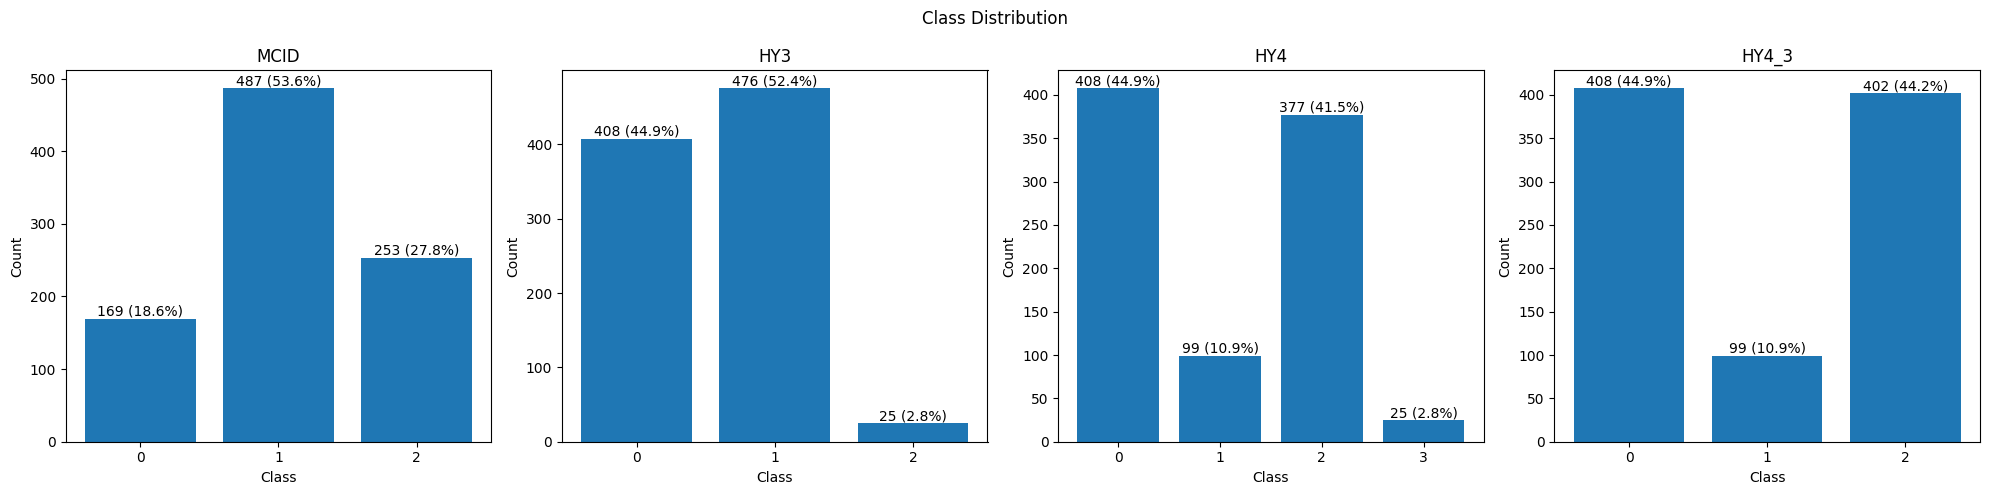

In [60]:
import matplotlib.pyplot as plt

y_MCID = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
y_HY3 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
y_HY4 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
y_HY43 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("y_MCID shape:", y_MCID.shape)
print("y_HY3 shape:", y_HY3.shape)
print("y_HY4 shape:", y_HY4.shape)
print("y_HY4_3 shape:", y_HY43.shape)

datasets = {
    "MCID": y_MCID,
    "HY3": y_HY3,
    "HY4": y_HY4,
    'HY4_3': y_HY43
}

fig, axes = plt.subplots(1, 4, figsize=(20,5))

for ax, (name, df) in zip(axes, datasets.items()):
    
    counts = df.iloc[:,0].value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    
    bars = ax.bar(counts.index.astype(str), counts.values)
    
    # añadir texto con conteo y porcentaje
    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(i, count, f"{count} ({pct:.1f}%)", 
                ha='center', va='bottom')
    
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.suptitle("Class Distribution")
plt.tight_layout()
plt.show()

In [66]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import numpy as np
import pandas as pd

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTEENN


def evaluate_models_10x10_oof_and_test_with_samplers(
    X_df: pd.DataFrame,
    y_df: pd.DataFrame,
    models: dict,
    samplers: dict = None,
    outer_splits: int = 10,
    inner_splits: int = 10,
    test_size: float = 0.3,
    random_state: int = 42,
    strategy: str = "minority",
    decimals: int = 4,
):
    
    y = y_df.iloc[:, 0].to_numpy()
    X = X_df.to_numpy()
    classes = np.unique(y)

    if samplers is None:
        samplers = {
            "RandomOverSampler": RandomOverSampler(
                sampling_strategy=strategy,
                random_state=random_state
            ),
            "SMOTE": SMOTE(
                sampling_strategy=strategy,
                k_neighbors=3,
                random_state=random_state
            ),
            "ADASYN": ADASYN(
                sampling_strategy=strategy,
                n_neighbors=3,
                random_state=random_state
            ),
            "SMOTEENN": SMOTEENN(
                sampling_strategy=strategy,
                smote=SMOTE(
                    sampling_strategy=strategy,
                    k_neighbors=3,
                    random_state=random_state
                ),
                random_state=random_state
            ),
        }

    def build_pipeline(estimator, sampler):
        return Pipeline([
            ("scaler", MinMaxScaler()),
            ("sampler", clone(sampler)),
            ("model", clone(estimator)),
        ])

    def compute_metrics(y_true, y_pred, y_proba):
        metrics = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
            "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
            "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        }

        try:
            metrics["AUC_macro"] = roc_auc_score(
                y_true, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            metrics["AUC_macro"] = np.nan

        try:
            metrics["AUC_weighted"] = roc_auc_score(
                y_true, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception:
            metrics["AUC_weighted"] = np.nan

        return metrics

    def summarize(metrics_list, suffix):
        df = pd.DataFrame(metrics_list)
        mean = df.mean(numeric_only=True)
        std = df.std(ddof=1, numeric_only=True)

        return {
            f"{col}_{suffix}": f"{mean[col]:.{decimals}f} ± {std[col]:.{decimals}f}"
            for col in df.columns
        }

    outer = StratifiedShuffleSplit(
        n_splits=outer_splits,
        test_size=test_size,
        random_state=random_state
    )

    results = []

    for model_name, estimator in models.items():
        for sampler_name, sampler in samplers.items():
            print(f"Evaluating {model_name} + {sampler_name}...")

            test_metrics_all = []
            cv_metrics_all = []

            for train_idx, test_idx in outer.split(X, y):
                X_train, y_train = X[train_idx], y[train_idx]
                X_test, y_test = X[test_idx], y[test_idx]

                inner = StratifiedKFold(
                    n_splits=inner_splits,
                    shuffle=True,
                    random_state=random_state
                )

                oof_pred = np.zeros(len(y_train), dtype=y_train.dtype)
                oof_proba = np.zeros((len(y_train), len(classes)))

                for tr_idx, val_idx in inner.split(X_train, y_train):
                    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
                    X_val = X_train[val_idx]
                    y_val = y_train[val_idx]

                    model = build_pipeline(estimator, sampler)
                    model.fit(X_tr, y_tr)

                    oof_pred[val_idx] = model.predict(X_val)

                    if hasattr(model, "predict_proba"):
                        fold_proba = model.predict_proba(X_val)
                        fold_classes = model.named_steps["model"].classes_

                        aligned_proba = np.zeros((len(y_val), len(classes)))
                        for j, cls in enumerate(fold_classes):
                            aligned_proba[:, np.where(classes == cls)[0][0]] = fold_proba[:, j]

                        oof_proba[val_idx] = aligned_proba
                    else:
                        oof_proba[val_idx] = np.nan

                cv_metrics_all.append(compute_metrics(y_train, oof_pred, oof_proba))

                model_full = build_pipeline(estimator, sampler)
                model_full.fit(X_train, y_train)

                test_pred = model_full.predict(X_test)

                if hasattr(model_full, "predict_proba"):
                    test_proba_raw = model_full.predict_proba(X_test)
                    test_classes = model_full.named_steps["model"].classes_

                    test_proba = np.zeros((len(y_test), len(classes)))
                    for j, cls in enumerate(test_classes):
                        test_proba[:, np.where(classes == cls)[0][0]] = test_proba_raw[:, j]
                else:
                    test_proba = np.full((len(y_test), len(classes)), np.nan)

                test_metrics_all.append(compute_metrics(y_test, test_pred, test_proba))

            summary_test = summarize(test_metrics_all, "Testing")
            summary_cv = summarize(cv_metrics_all, "CV")

            row = {
                "Model": model_name,
                "Sampler": sampler_name,
            }
            row.update(summary_test)
            row.update(summary_cv)

            results.append(row)

    df_final_summary = pd.DataFrame(results)

    ordered_cols = [
        "Model", "Sampler",
        "Accuracy_Testing",
        "Precision_macro_Testing", "Recall_macro_Testing", "F1_macro_Testing", "AUC_macro_Testing",
        "Precision_weighted_Testing", "Recall_weighted_Testing", "F1_weighted_Testing", "AUC_weighted_Testing",
        "Accuracy_CV",
        "Precision_macro_CV", "Recall_macro_CV", "F1_macro_CV", "AUC_macro_CV",
        "Precision_weighted_CV", "Recall_weighted_CV", "F1_weighted_CV", "AUC_weighted_CV",
    ]

    df_final_summary = df_final_summary[ordered_cols]
    return df_final_summary

## HY3

In [62]:
X_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)
y_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_data shape:", X_HY3_data.shape)
print("y_HY3_data shape:", y_HY3_data.shape)
X_HY3_data.head()

X_HY3_data shape: (909, 931)
y_HY3_data shape: (909, 1)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCAALTTM_mean,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,...,NP3PTRMR_std,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,1.000000,1.000000,1.0,1.0,...,0.577350,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350
3018,0,0,0.0,1.0,16.0,63.6,1.000000,0.666667,1.0,1.0,...,1.527525,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525
3020,0,0,0.0,1.0,15.0,77.0,0.666667,0.666667,1.0,1.0,...,1.154701,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701
3028,0,0,1.0,1.0,22.0,78.8,1.000000,1.000000,1.0,1.0,...,0.000000,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525
3051,0,0,1.0,1.0,18.0,74.7,1.000000,1.000000,1.0,1.0,...,0.577350,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350


In [67]:
df_HY3_full_oversampling =evaluate_models_10x10_oof_and_test_with_samplers(
    X_df=X_HY3_data, 
    y_df=y_HY3_data, 
    models=classification_models, 
    samplers=None,
    strategy={2:100},
    random_state=42
)
df_HY3_full_oversampling.to_csv(full_set_path_HY3 / "HY3_full_oversampling.csv", index=False)
df_HY3_full_oversampling.head(10)

Evaluating decision_tree + RandomOverSampler...
Evaluating decision_tree + SMOTE...
Evaluating decision_tree + ADASYN...
Evaluating decision_tree + SMOTEENN...
Evaluating random_forest + RandomOverSampler...
Evaluating random_forest + SMOTE...
Evaluating random_forest + ADASYN...
Evaluating random_forest + SMOTEENN...
Evaluating extra_trees + RandomOverSampler...
Evaluating extra_trees + SMOTE...
Evaluating extra_trees + ADASYN...
Evaluating extra_trees + SMOTEENN...
Evaluating xgboost + RandomOverSampler...
Evaluating xgboost + SMOTE...
Evaluating xgboost + ADASYN...
Evaluating xgboost + SMOTEENN...
Evaluating adaboost + RandomOverSampler...
Evaluating adaboost + SMOTE...
Evaluating adaboost + ADASYN...
Evaluating adaboost + SMOTEENN...
Evaluating svm + RandomOverSampler...
Evaluating svm + SMOTE...
Evaluating svm + ADASYN...
Evaluating svm + SMOTEENN...
Evaluating logistic_regression + RandomOverSampler...
Evaluating logistic_regression + SMOTE...
Evaluating logistic_regression + ADA

,Model,Sampler,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,F1_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,RandomOverSampler,0.8264 ± 0.0281,0.6371 ± 0.0471,0.6434 ± 0.0357,0.6381 ± 0.0419,0.7683 ± 0.0208,0.8278 ± 0.0203,0.8264 ± 0.0281,0.8264 ± 0.0244,0.8397 ± 0.0226,0.8217 ± 0.0113,0.6558 ± 0.0416,0.6492 ± 0.0421,0.6503 ± 0.0394,0.7690 ± 0.0209,0.8217 ± 0.0106,0.8217 ± 0.0113,0.8213 ± 0.0108,0.8331 ± 0.0114
1,decision_tree,SMOTE,0.8242 ± 0.0205,0.6459 ± 0.0360,0.6737 ± 0.0553,0.6500 ± 0.0328,0.7840 ± 0.0249,0.8332 ± 0.0124,0.8242 ± 0.0205,0.8273 ± 0.0164,0.8416 ± 0.0143,0.8222 ± 0.0110,0.6524 ± 0.0318,0.6548 ± 0.0299,0.6510 ± 0.0257,0.7725 ± 0.0153,0.8251 ± 0.0095,0.8222 ± 0.0110,0.8232 ± 0.0099,0.8353 ± 0.0094
2,decision_tree,ADASYN,0.8231 ± 0.0230,0.6503 ± 0.0329,0.6864 ± 0.0588,0.6586 ± 0.0314,0.7900 ± 0.0279,0.8321 ± 0.0168,0.8231 ± 0.0230,0.8262 ± 0.0201,0.8405 ± 0.0180,0.8212 ± 0.0162,0.6523 ± 0.0408,0.6523 ± 0.0319,0.6514 ± 0.0360,0.7707 ± 0.0173,0.8231 ± 0.0146,0.8212 ± 0.0162,0.8219 ± 0.0153,0.8336 ± 0.0146
3,decision_tree,SMOTEENN,0.7711 ± 0.0257,0.6217 ± 0.0215,0.7037 ± 0.0479,0.6074 ± 0.0288,0.7937 ± 0.0295,0.8527 ± 0.0228,0.7711 ± 0.0257,0.7852 ± 0.0232,0.8255 ± 0.0202,0.7717 ± 0.0267,0.6277 ± 0.0153,0.7200 ± 0.0315,0.6177 ± 0.0261,0.8023 ± 0.0181,0.8504 ± 0.0106,0.7717 ± 0.0267,0.7857 ± 0.0240,0.8268 ± 0.0166
4,random_forest,RandomOverSampler,0.8978 ± 0.0124,0.6653 ± 0.1417,0.6242 ± 0.0220,0.6230 ± 0.0367,0.9456 ± 0.0118,0.8803 ± 0.0171,0.8978 ± 0.0124,0.8869 ± 0.0126,0.9591 ± 0.0058,0.8965 ± 0.0060,0.7647 ± 0.1755,0.6277 ± 0.0142,0.6301 ± 0.0267,0.9544 ± 0.0064,0.8852 ± 0.0159,0.8965 ± 0.0060,0.8851 ± 0.0058,0.9606 ± 0.0033
5,random_forest,SMOTE,0.8967 ± 0.0123,0.6645 ± 0.1422,0.6237 ± 0.0228,0.6222 ± 0.0370,0.9447 ± 0.0157,0.8793 ± 0.0180,0.8967 ± 0.0123,0.8858 ± 0.0126,0.9585 ± 0.0065,0.8975 ± 0.0037,0.7238 ± 0.1635,0.6267 ± 0.0171,0.6266 ± 0.0297,0.9549 ± 0.0058,0.8829 ± 0.0148,0.8975 ± 0.0037,0.8859 ± 0.0041,0.9618 ± 0.0036
6,random_forest,ADASYN,0.8963 ± 0.0141,0.5977 ± 0.0093,0.6143 ± 0.0099,0.6056 ± 0.0096,0.9456 ± 0.0162,0.8739 ± 0.0137,0.8963 ± 0.0141,0.8846 ± 0.0139,0.9593 ± 0.0070,0.8970 ± 0.0070,0.7583 ± 0.1684,0.6333 ± 0.0254,0.6380 ± 0.0420,0.9545 ± 0.0067,0.8852 ± 0.0142,0.8970 ± 0.0070,0.8860 ± 0.0074,0.9610 ± 0.0029
7,random_forest,SMOTEENN,0.7802 ± 0.0462,0.6537 ± 0.0222,0.7695 ± 0.0287,0.6419 ± 0.0404,0.9454 ± 0.0130,0.8627 ± 0.0181,0.7802 ± 0.0462,0.7837 ± 0.0510,0.9568 ± 0.0084,0.7769 ± 0.0473,0.6581 ± 0.0245,0.7738 ± 0.0169,0.6509 ± 0.0442,0.9545 ± 0.0062,0.8556 ± 0.0178,0.7769 ± 0.0473,0.7777 ± 0.0510,0.9592 ± 0.0045
8,extra_trees,RandomOverSampler,0.8952 ± 0.0137,0.5971 ± 0.0091,0.6131 ± 0.0097,0.6049 ± 0.0093,0.9496 ± 0.0169,0.8727 ± 0.0134,0.8952 ± 0.0137,0.8835 ± 0.0135,0.9593 ± 0.0067,0.8976 ± 0.0045,0.5989 ± 0.0032,0.6162 ± 0.0031,0.6075 ± 0.0031,0.9528 ± 0.0078,0.8724 ± 0.0046,0.8976 ± 0.0045,0.8848 ± 0.0045,0.9598 ± 0.0033
9,extra_trees,SMOTE,0.9000 ± 0.0105,0.6671 ± 0.1394,0.6258 ± 0.0198,0.6246 ± 0.0343,0.9459 ± 0.0143,0.8829 ± 0.0138,0.9000 ± 0.0105,0.8893 ± 0.0102,0.9589 ± 0.0065,0.8945 ± 0.0057,0.6807 ± 0.1405,0.6192 ± 0.0083,0.6157 ± 0.0158,0.9564 ± 0.0063,0.8770 ± 0.0115,0.8945 ± 0.0057,0.8827 ± 0.0053,0.9613 ± 0.0036


## HY4_3


In [68]:
X_HY43_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY43_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY4_3_data shape:", X_HY4_data.shape)
print("y_HY4_3_data shape:", y_HY4_data.shape)

X_HY4_3_data shape: (909, 931)
y_HY4_3_data shape: (909, 1)


In [69]:
df_HY43_full_oversampling =evaluate_models_10x10_oof_and_test_with_samplers(
    X_df=X_HY43_data, 
    y_df=y_HY43_data, 
    models=classification_models, 
    samplers=None,
    strategy={1:250},
    random_state=42
)
df_HY43_full_oversampling.to_csv(full_set_path_HY4 / "HY43_full_oversampling.csv", index=False)
df_HY43_full_oversampling.head(10)

Evaluating decision_tree + RandomOverSampler...
Evaluating decision_tree + SMOTE...
Evaluating decision_tree + ADASYN...
Evaluating decision_tree + SMOTEENN...
Evaluating random_forest + RandomOverSampler...
Evaluating random_forest + SMOTE...
Evaluating random_forest + ADASYN...
Evaluating random_forest + SMOTEENN...
Evaluating extra_trees + RandomOverSampler...
Evaluating extra_trees + SMOTE...
Evaluating extra_trees + ADASYN...
Evaluating extra_trees + SMOTEENN...
Evaluating xgboost + RandomOverSampler...
Evaluating xgboost + SMOTE...
Evaluating xgboost + ADASYN...
Evaluating xgboost + SMOTEENN...


KeyboardInterrupt: 

## HY4

In [ ]:
X_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_data shape:", X_HY4_data.shape)
print("y_HY4_data shape:", y_HY4_data.shape)

In [ ]:
df_HY4_full_oversampling =evaluate_models_10x10_oof_and_test_with_samplers(
    X_df=X_HY4_data, 
    y_df=y_HY4_data, 
    models=classification_models, 
    samplers=None,
    random_state=42
)
df_HY4_full_oversampling.to_csv(full_set_path_HY4 / "HY4_full_oversampling.csv", index=False)
df_HY4_full_oversampling.head(10)

## MCID

In [ ]:
X_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)
y_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_data shape:", X_MCID_data.shape)
print("y_MCID_data shape:", y_MCID_data.shape)

In [ ]:
df_MCID_full_oversampling =evaluate_models_10x10_oof_and_test_with_samplers(
    X_df=X_MCID_data, 
    y_df=y_MCID_data, 
    models=classification_models, 
    samplers=None,
    random_state=42
)
df_MCID_full_oversampling.to_csv(full_set_path_MCID / "MCID_full_oversampling.csv", index=False)
df_MCID_full_oversampling.head(10)

X_HY3_motor_data shape: (909, 300)
y_HY3_motor_data shape: (909, 1)


# HyperParameter Turning


In [ ]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline

import numpy as np
import pandas as pd

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical


def evaluate_models_nested_bayes(
    X_df: pd.DataFrame,
    y_df: pd.DataFrame,
    models: dict,
    outer_splits: int = 10,
    inner_splits: int = 10,
    test_size: float = 0.3,
    random_state: int = 42,
    decimals: int = 4,
    n_iter_search: int = 25,
    n_jobs_search: int = -1,
):

    y = y_df.iloc[:, 0].to_numpy()
    X = X_df.to_numpy()
    classes = np.unique(y)

    def build_pipeline(estimator):
        return Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", clone(estimator)),
        ])

    def get_search_spaces(model_name):

        spaces = {

            "decision_tree": {
                "model__max_depth": Integer(2, 30),
                "model__min_samples_split": Integer(2, 20),
                "model__min_samples_leaf": Integer(1, 10),
                "model__criterion": Categorical(["gini", "entropy"]),
                "model__max_features": Categorical([None, "sqrt"]),
            },

            "random_forest": {
                "model__n_estimators": Integer(200, 800),
                "model__max_depth": Integer(4, 30),
                "model__min_samples_split": Integer(2, 20),
                "model__min_samples_leaf": Integer(1, 10),
                "model__max_features": Categorical(["sqrt", "log2"]),
                "model__bootstrap": Categorical([True]),
            },

            "extra_trees": {
                "model__n_estimators": Integer(200, 800),
                "model__max_depth": Integer(4, 30),
                "model__min_samples_split": Integer(2, 20),
                "model__min_samples_leaf": Integer(1, 10),
                "model__max_features": Categorical(["sqrt", "log2"]),
            },

            "xgboost": {
                "model__n_estimators": Integer(200, 600),
                "model__max_depth": Integer(3, 10),
                "model__learning_rate": Real(0.01, 0.3, prior="log-uniform"),
                "model__subsample": Real(0.6, 1.0),
                "model__colsample_bytree": Real(0.6, 1.0),
                "model__min_child_weight": Integer(1, 10),
                "model__gamma": Real(1e-8, 5.0, prior="log-uniform"),
                "model__reg_alpha": Real(1e-8, 5.0, prior="log-uniform"),
                "model__reg_lambda": Real(1e-8, 5.0, prior="log-uniform"),
            },

            "adaboost": {
                "model__n_estimators": Integer(50, 500),
                "model__learning_rate": Real(0.01, 1.0, prior="log-uniform"),
            },

            "svm": {
                "model__C": Real(1e-3, 1e3, prior="log-uniform"),
                "model__gamma": Real(1e-5, 1.0, prior="log-uniform"),
                "model__kernel": Categorical(["rbf"]),
            },

            "logistic_regression": {
                "model__C": Real(1e-4, 1e2, prior="log-uniform"),
                "model__solver": Categorical(["lbfgs", "saga"]),
                "model__penalty": Categorical(["l2"]),
            },

            "knn": {
                "model__n_neighbors": Integer(3, 51),
                "model__weights": Categorical(["uniform", "distance"]),
                "model__p": Integer(1, 2),
            },

            "gaussian_nb": {
                "model__var_smoothing": Real(1e-10, 1e-6, prior="log-uniform"),
            },
        }

        if model_name not in spaces:
            raise ValueError(f"No search space definido para {model_name}")

        return spaces[model_name]

    def compute_metrics(y_true, y_pred, y_proba):
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "AUC_macro": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
            "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
            "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
            "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "AUC_weighted": roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted"),
        }

    def summarize(metrics_list, suffix):
        df = pd.DataFrame(metrics_list)
        mean = df.mean(numeric_only=True)
        std = df.std(ddof=1, numeric_only=True)
        return {
            f"{col}_{suffix}": f"{mean[col]:.{decimals}f} ± {std[col]:.{decimals}f}"
            for col in df.columns
        }

    outer = StratifiedShuffleSplit(
        n_splits=outer_splits,
        test_size=test_size,
        random_state=random_state
    )

    test_summary_rows = []
    cv_summary_rows = []
    best_params_rows = []

    for model_name, estimator in models.items():

        print(f"Evaluating {model_name} with Bayesian Search...")

        test_metrics_all = []
        cv_metrics_all = []
        best_params_per_outer_fold = []

        search_spaces = get_search_spaces(model_name)

        for fold_id, (train_idx, test_idx) in enumerate(outer.split(X, y), start=1):

            X_train, y_train = X[train_idx], y[train_idx]
            X_test, y_test = X[test_idx], y[test_idx]

            inner = StratifiedKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=random_state
            )

            base_pipeline = build_pipeline(estimator)

            opt = BayesSearchCV(
                estimator=base_pipeline,
                search_spaces=search_spaces,
                n_iter=n_iter_search,
                scoring="f1_macro",
                cv=inner,
                n_jobs=n_jobs_search,
                refit=True,
                random_state=random_state,
                verbose=0,
            )

            opt.fit(X_train, y_train)

            best_model = opt.best_estimator_
            best_params_per_outer_fold.append(opt.best_params_)

            cv_metrics_all.append({
                "F1_macro": opt.best_score_,
            })

            test_pred = best_model.predict(X_test)
            test_proba_raw = best_model.predict_proba(X_test)

            test_classes = best_model.named_steps["model"].classes_
            test_proba = np.zeros((len(y_test), len(classes)))

            for j, cls in enumerate(test_classes):
                test_proba[:, np.where(classes == cls)[0][0]] = test_proba_raw[:, j]

            test_metrics_all.append(compute_metrics(y_test, test_pred, test_proba))

            print(f"  Fold {fold_id}: best inner F1_macro = {opt.best_score_:.4f}")

        test_summary_rows.append(
            pd.Series(summarize(test_metrics_all, "Testing"), name=model_name)
        )

        cv_summary_rows.append(
            pd.Series(summarize(cv_metrics_all, "CV"), name=model_name)
        )

        best_params_rows.append(
            pd.Series({"Best_Params_Outer_Folds": best_params_per_outer_fold}, name=model_name)
        )

    df_test_summary = pd.DataFrame(test_summary_rows)[[
        "Accuracy_Testing",
        "Precision_macro_Testing", "Recall_macro_Testing", "F1_macro_Testing", "AUC_macro_Testing",
        "Precision_weighted_Testing", "Recall_weighted_Testing", "F1_weighted_Testing", "AUC_weighted_Testing"
    ]]

    df_cv_summary = pd.DataFrame(cv_summary_rows)[[
        "F1_macro_CV"
    ]]

    df_best_params = pd.DataFrame(best_params_rows)

    df_final_summary = pd.concat(
        [df_test_summary, df_cv_summary, df_best_params],
        axis=1
    )

    return df_final_summary

## HY3

In [84]:
X_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)
y_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_data shape:", X_HY3_data.shape)
print("y_HY3_data shape:", y_HY3_data.shape)
X_HY3_data.head()

X_HY3_data shape: (909, 931)
y_HY3_data shape: (909, 1)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCAALTTM_mean,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,...,NP3PTRMR_std,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,1.000000,1.000000,1.0,1.0,...,0.577350,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350
3018,0,0,0.0,1.0,16.0,63.6,1.000000,0.666667,1.0,1.0,...,1.527525,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525
3020,0,0,0.0,1.0,15.0,77.0,0.666667,0.666667,1.0,1.0,...,1.154701,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701
3028,0,0,1.0,1.0,22.0,78.8,1.000000,1.000000,1.0,1.0,...,0.000000,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525
3051,0,0,1.0,1.0,18.0,74.7,1.000000,1.000000,1.0,1.0,...,0.577350,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350


In [86]:
df_HY3_full_bayesian=evaluate_models_nested_bayes(
                                        X_df= X_HY3_data,
                                        y_df= y_HY3_data,
                                        models=classification_models,
                                        outer_splits=10,
                                        inner_splits=5,
                                        n_iter_search=60)
df_HY3_full_bayesian.to_csv(full_set_path_HY3 / "HY3_full_bayesian.csv", index=False)
df_HY3_full_bayesian.head(10)

Evaluating decision_tree with Bayesian Search...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('entropy'), np.int64(3), np.str_('sqrt'), np.int64(10), np.int64(2)] before, using random point ['entropy', np.int64(21), None, np.int64(2), np.int64(18)]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('entropy'), np.int64(3), np.str_('sqrt'), np.int64(10), np.int64(2)] before, using random point ['gini', np.int64(15), 'sqrt', np.int64(5), np.int64(13)]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(3), np.str_('sqrt'), np.int64(10), np.int64(2)] before, using random point ['gini', np.int64(19), None, np.int64(4), np.int64(

  Fold 1: best inner F1_macro = 0.7413


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


  Fold 2: best inner F1_macro = 0.7824


...

/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.993268144489922e-07] before, using random point [2.009968809059832e-09]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.992672637755316e-07] before, using random point [5.669458601337459e-10]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.99611019985148e-07] before, using random point [3.500689741432206e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.993644655979395e-07] before, using random point [1.4147963402677167e-08]
 

  Fold 8: best inner F1_macro = 0.5565
  Fold 9: best inner F1_macro = 0.5976


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.5264652482295983e-09] before, using random point [2.009968809059832e-09]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [2.396582829815405e-10] before, using random point [5.669458601337459e-10]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [2.329336209298402e-10] before, using random point [3.500689741432206e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.993644655979395e-07] before, using random point [3.439260240085048e-10]


  Fold 10: best inner F1_macro = 0.5430


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,F1_macro_CV,Best_Params_Outer_Folds
decision_tree,0.8487 ± 0.0239,0.6638 ± 0.0635,0.6456 ± 0.0515,0.6485 ± 0.0534,0.8302 ± 0.0308,0.8457 ± 0.0222,0.8487 ± 0.0239,0.8455 ± 0.0239,0.8906 ± 0.0186,0.7243 ± 0.0430,"[{'model__criterion': 'entropy', 'model__max_d..."
random_forest,0.9000 ± 0.0127,0.7720 ± 0.0759,0.7169 ± 0.0461,0.7293 ± 0.0449,0.9503 ± 0.0085,0.8989 ± 0.0125,0.9000 ± 0.0127,0.8973 ± 0.0118,0.9620 ± 0.0067,0.7733 ± 0.0291,"[{'model__bootstrap': True, 'model__max_depth'..."
extra_trees,0.9018 ± 0.0131,0.6011 ± 0.0087,0.6184 ± 0.0091,0.6093 ± 0.0089,0.9511 ± 0.0105,0.8793 ± 0.0128,0.9018 ± 0.0131,0.8899 ± 0.0129,0.9589 ± 0.0086,0.6151 ± 0.0082,"[{'model__max_depth': 23, 'model__max_features..."
xgboost,0.8982 ± 0.0154,0.7554 ± 0.1534,0.6614 ± 0.0470,0.6770 ± 0.0690,0.9319 ± 0.0240,0.8899 ± 0.0228,0.8982 ± 0.0154,0.8907 ± 0.0166,0.9563 ± 0.0100,0.7276 ± 0.0218,[{'model__colsample_bytree': 0.711186268582808...
adaboost,0.8817 ± 0.0257,0.7442 ± 0.0779,0.7083 ± 0.0474,0.7043 ± 0.0330,0.9125 ± 0.0251,0.8847 ± 0.0209,0.8817 ± 0.0257,0.8807 ± 0.0229,0.9224 ± 0.0338,0.7387 ± 0.0303,"[{'model__learning_rate': 0.1728091250365026, ..."
svm,0.8901 ± 0.0116,0.7239 ± 0.0962,0.6652 ± 0.0463,0.6780 ± 0.0596,0.9354 ± 0.0113,0.8827 ± 0.0140,0.8901 ± 0.0116,0.8839 ± 0.0114,0.9491 ± 0.0082,0.7143 ± 0.0387,"[{'model__C': 18.59006401546194, 'model__gamma..."
logistic_regression,0.8637 ± 0.0185,0.6900 ± 0.0463,0.7489 ± 0.0738,0.7005 ± 0.0469,0.9366 ± 0.0180,0.8836 ± 0.0148,0.8637 ± 0.0185,0.8662 ± 0.0162,0.9466 ± 0.0092,0.7486 ± 0.0300,"[{'model__C': 0.008599894157959172, 'model__pe..."
knn,0.7498 ± 0.0179,0.5245 ± 0.0066,0.5226 ± 0.0110,0.5038 ± 0.0136,0.7847 ± 0.0300,0.7747 ± 0.0092,0.7498 ± 0.0179,0.7332 ± 0.0206,0.8619 ± 0.0209,0.5228 ± 0.0143,"[{'model__n_neighbors': 10, 'model__p': 2, 'mo..."
gaussian_nb,0.7421 ± 0.0577,0.6040 ± 0.0158,0.6280 ± 0.0701,0.5720 ± 0.0385,0.7863 ± 0.0422,0.8530 ± 0.0111,0.7421 ± 0.0577,0.7810 ± 0.0431,0.8894 ± 0.0090,0.5803 ± 0.0318,[{'model__var_smoothing': 1.5783879853890547e-...


## HY4_3


In [87]:
X_HY43_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY43_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY4_3_data shape:", X_HY4_data.shape)
print("y_HY4_3_data shape:", y_HY4_data.shape)

X_HY4_3_data shape: (909, 931)
y_HY4_3_data shape: (909, 1)


In [88]:
df_HY43_full_bayesian=evaluate_models_nested_bayes(
                                        X_df= X_HY43_data,
                                        y_df= y_HY43_data,
                                        models=classification_models,
                                        outer_splits=10,
                                        inner_splits=5,
                                        n_iter_search=60)
df_HY43_full_bayesian.to_csv(full_set_path_HY4 / "HY43_full_bayesian.csv", index=False)
df_HY43_full_bayesian.head(10)

Evaluating decision_tree with Bayesian Search...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(30), None, np.int64(7), np.int64(2)] before, using random point ['gini', np.int64(3), 'sqrt', np.int64(7), np.int64(7)]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(30), None, np.int64(7), np.int64(20)] before, using random point ['gini', np.int64(27), 'sqrt', np.int64(5), np.int64(18)]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(30), None, np.int64(7), np.int64(20)] before, using random point ['gini', np.int64(5), None, np.int64(2), np.int64(3)]
  warnings.warn(
/home/fsc/Desktop/PD

  Fold 1: best inner F1_macro = 0.6618


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(30), None, np.int64(10), np.int64(20)] before, using random point ['entropy', np.int64(16), 'sqrt', np.int64(10), np.int64(10)]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(30), None, np.int64(10), np.int64(19)] before, using random point ['entropy', np.int64(21), None, np.int64(2), np.int64(18)]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has be

  Fold 2: best inner F1_macro = 0.6722


...

/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.99611019985148e-07] before, using random point [3.500689741432206e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.993644655979395e-07] before, using random point [1.4147963402677167e-08]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.987092735334505e-07] before, using random point [6.894873272633249e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.997913683799222e-07] before, using random point [6.026228293326813e-09]
 

  Fold 8: best inner F1_macro = 0.5071
  Fold 9: best inner F1_macro = 0.5418


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.993268144489922e-07] before, using random point [2.009968809059832e-09]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.992672637755316e-07] before, using random point [5.669458601337459e-10]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.99611019985148e-07] before, using random point [3.500689741432206e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.993644655979395e-07] before, using random point [1.4147963402677167e-08]
 

  Fold 10: best inner F1_macro = 0.5518


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,F1_macro_CV,Best_Params_Outer_Folds
decision_tree,0.7912 ± 0.0288,0.6265 ± 0.0424,0.6326 ± 0.0299,0.6271 ± 0.0343,0.8198 ± 0.0176,0.7758 ± 0.0232,0.7912 ± 0.0288,0.7816 ± 0.0213,0.8901 ± 0.0133,0.6598 ± 0.0135,"[{'model__criterion': 'gini', 'model__max_dept..."
random_forest,0.8597 ± 0.0135,0.7430 ± 0.0319,0.6907 ± 0.0159,0.6936 ± 0.0204,0.8938 ± 0.0129,0.8356 ± 0.0114,0.8597 ± 0.0135,0.8390 ± 0.0126,0.9423 ± 0.0085,0.6982 ± 0.0144,"[{'model__bootstrap': True, 'model__max_depth'..."
extra_trees,0.8619 ± 0.0079,0.5750 ± 0.0054,0.6455 ± 0.0059,0.6081 ± 0.0057,0.8867 ± 0.0146,0.7678 ± 0.0073,0.8619 ± 0.0079,0.8119 ± 0.0076,0.9394 ± 0.0084,0.6070 ± 0.0032,"[{'model__max_depth': 26, 'model__max_features..."
xgboost,0.8447 ± 0.0147,0.6939 ± 0.0877,0.6527 ± 0.0140,0.6397 ± 0.0207,0.8734 ± 0.0197,0.8080 ± 0.0300,0.8447 ± 0.0147,0.8140 ± 0.0113,0.9282 ± 0.0105,0.6555 ± 0.0075,"[{'model__colsample_bytree': 0.6, 'model__gamm..."
adaboost,0.8128 ± 0.0171,0.6645 ± 0.0211,0.6588 ± 0.0161,0.6572 ± 0.0179,0.8495 ± 0.0142,0.8009 ± 0.0127,0.8128 ± 0.0171,0.8043 ± 0.0116,0.9215 ± 0.0079,0.6707 ± 0.0131,"[{'model__learning_rate': 0.9960467865487066, ..."
svm,0.8190 ± 0.0293,0.6565 ± 0.0494,0.6527 ± 0.0322,0.6493 ± 0.0376,0.8554 ± 0.0168,0.7959 ± 0.0248,0.8190 ± 0.0293,0.8050 ± 0.0245,0.9198 ± 0.0091,0.6472 ± 0.0177,"[{'model__C': 1000.0, 'model__gamma': 0.007320..."
logistic_regression,0.7985 ± 0.0226,0.6563 ± 0.0230,0.6540 ± 0.0227,0.6530 ± 0.0227,0.8581 ± 0.0189,0.8031 ± 0.0141,0.7985 ± 0.0226,0.7988 ± 0.0174,0.9235 ± 0.0105,0.6613 ± 0.0151,"[{'model__C': 0.002835798651964616, 'model__pe..."
knn,0.7055 ± 0.0253,0.5844 ± 0.1071,0.5362 ± 0.0237,0.5154 ± 0.0284,0.7772 ± 0.0385,0.7116 ± 0.0443,0.7055 ± 0.0253,0.6708 ± 0.0252,0.8438 ± 0.0349,0.5361 ± 0.0145,"[{'model__n_neighbors': 3, 'model__p': 2, 'mod..."
gaussian_nb,0.6004 ± 0.0268,0.6259 ± 0.0176,0.5888 ± 0.0334,0.5457 ± 0.0233,0.8092 ± 0.0195,0.7823 ± 0.0166,0.6004 ± 0.0268,0.6459 ± 0.0224,0.8771 ± 0.0135,0.5379 ± 0.0152,"[{'model__var_smoothing': 1e-06}, {'model__var..."


## HY4

In [89]:
X_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_data shape:", X_HY4_data.shape)
print("y_HY4_data shape:", y_HY4_data.shape)

X_HY4_data shape: (909, 931)
y_HY4_data shape: (909, 1)


In [90]:
df_HY4_full_bayesian=evaluate_models_nested_bayes(
                                        X_df= X_HY4_data,
                                        y_df= y_HY4_data,
                                        models=classification_models,
                                        outer_splits=10,
                                        inner_splits=5,
                                        n_iter_search=60)
df_HY4_full_bayesian.to_csv(full_set_path_HY4 / "HY4_full_bayesian.csv", index=False)
df_HY4_full_bayesian.head(10)

Evaluating decision_tree with Bayesian Search...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(30), None, np.int64(2), np.int64(20)] before, using random point ['gini', np.int64(27), None, np.int64(3), np.int64(16)]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(30), None, np.int64(2), np.int64(20)] before, using random point ['entropy', np.int64(26), 'sqrt', np.int64(7), np.int64(3)]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(30), None, np.int64(2), np.int64(20)] before, using random point ['gini', np.int64(15), 'sqrt', np.int64(8), np.int64(5)]
  warnings.warn(


  Fold 1: best inner F1_macro = 0.5790


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


  Fold 2: best inner F1_macro = 0.5596


...

/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.4195217940455722e-09] before, using random point [5.669458601337459e-10]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.997913683799222e-07] before, using random point [6.026228293326813e-09]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.990828682126345e-07] before, using random point [2.760837137758653e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [8.915617806968867e-10] before, using random point [2.4240274422081745e-09]

  Fold 9: best inner F1_macro = 0.4280


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.993268144489922e-07] before, using random point [2.009968809059832e-09]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.992672637755316e-07] before, using random point [5.669458601337459e-10]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.99611019985148e-07] before, using random point [3.500689741432206e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.993644655979395e-07] before, using random point [1.4147963402677167e-08]
 

  Fold 10: best inner F1_macro = 0.3865


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,F1_macro_CV,Best_Params_Outer_Folds
decision_tree,0.7516 ± 0.0507,0.5465 ± 0.0805,0.5102 ± 0.0377,0.5138 ± 0.0402,0.7478 ± 0.0499,0.7408 ± 0.0377,0.7516 ± 0.0507,0.7419 ± 0.0397,0.8369 ± 0.0541,0.5687 ± 0.0278,"[{'model__criterion': 'gini', 'model__max_dept..."
random_forest,0.8253 ± 0.0138,0.6774 ± 0.0540,0.6385 ± 0.0363,0.6461 ± 0.0304,0.8948 ± 0.0097,0.8067 ± 0.0146,0.8253 ± 0.0138,0.8125 ± 0.0139,0.9305 ± 0.0082,0.6330 ± 0.0171,"[{'model__bootstrap': True, 'model__max_depth'..."
extra_trees,0.8370 ± 0.0092,0.4188 ± 0.0048,0.4838 ± 0.0054,0.4487 ± 0.0051,0.8927 ± 0.0111,0.7256 ± 0.0084,0.8370 ± 0.0092,0.7770 ± 0.0087,0.9280 ± 0.0074,0.4522 ± 0.0076,"[{'model__max_depth': 29, 'model__max_features..."
xgboost,0.8293 ± 0.0190,0.6752 ± 0.1159,0.5427 ± 0.0495,0.5474 ± 0.0548,0.8771 ± 0.0159,0.7898 ± 0.0383,0.8293 ± 0.0190,0.7928 ± 0.0219,0.9201 ± 0.0092,0.5552 ± 0.0218,[{'model__colsample_bytree': 0.993191309058990...
adaboost,0.7700 ± 0.0227,0.5665 ± 0.0623,0.5630 ± 0.0603,0.5599 ± 0.0564,0.8511 ± 0.0135,0.7654 ± 0.0191,0.7700 ± 0.0227,0.7659 ± 0.0203,0.9002 ± 0.0121,0.5843 ± 0.0392,"[{'model__learning_rate': 1.0, 'model__n_estim..."
svm,0.7938 ± 0.0239,0.5802 ± 0.0676,0.5429 ± 0.0307,0.5504 ± 0.0419,0.8646 ± 0.0146,0.7638 ± 0.0184,0.7938 ± 0.0239,0.7758 ± 0.0162,0.9082 ± 0.0054,0.5395 ± 0.0259,"[{'model__C': 32.99308586225066, 'model__gamma..."
logistic_regression,0.7535 ± 0.0176,0.5591 ± 0.0211,0.6117 ± 0.0472,0.5697 ± 0.0228,0.8651 ± 0.0220,0.7675 ± 0.0146,0.7535 ± 0.0176,0.7546 ± 0.0157,0.9075 ± 0.0126,0.5659 ± 0.0206,"[{'model__C': 0.0050891596173902294, 'model__p..."
knn,0.6758 ± 0.0189,0.4168 ± 0.0415,0.4022 ± 0.0138,0.3892 ± 0.0210,0.7341 ± 0.0266,0.6516 ± 0.0174,0.6758 ± 0.0189,0.6375 ± 0.0165,0.8264 ± 0.0217,0.4041 ± 0.0160,"[{'model__n_neighbors': 3, 'model__p': 2, 'mod..."
gaussian_nb,0.5267 ± 0.0353,0.4629 ± 0.0401,0.4987 ± 0.0656,0.4017 ± 0.0421,0.7424 ± 0.0508,0.7050 ± 0.0434,0.5267 ± 0.0353,0.5520 ± 0.0375,0.8499 ± 0.0181,0.4124 ± 0.0188,[{'model__var_smoothing': 9.970112347691563e-0...


## MCID

In [91]:
X_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)
y_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_data shape:", X_MCID_data.shape)
print("y_MCID_data shape:", y_MCID_data.shape)

X_MCID_data shape: (909, 936)
y_MCID_data shape: (909, 1)


In [92]:
df_MCID_full_bayesian=evaluate_models_nested_bayes(
                                        X_df= X_MCID_data,
                                        y_df= y_MCID_data,
                                        models=classification_models,
                                        outer_splits=10,
                                        inner_splits=5,
                                        n_iter_search=60)
df_MCID_full_bayesian.to_csv(full_set_path_MCID / "MCID_full_bayesian.csv", index=False)
df_MCID_full_bayesian.head(10)

Evaluating decision_tree with Bayesian Search...


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(6), np.str_('sqrt'), np.int64(9), np.int64(2)] before, using random point ['entropy', np.int64(21), None, np.int64(7), np.int64(11)]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(6), np.str_('sqrt'), np.int64(9), np.int64(2)] before, using random point ['gini', np.int64(3), None, np.int64(9), np.int64(7)]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(6), np.str_('sqrt'), np.int64(10), np.int64(2)] before, using random point ['entropy', np.int64(24), 'sqrt', np.int64(3), np.int64(18)]
  

  Fold 1: best inner F1_macro = 0.4434
  Fold 2: best inner F1_macro = 0.4489


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


  Fold 3: best inner F1_macro = 0.4628


...

/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.4578310746259326e-09] before, using random point [3.500689741432206e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.4642125159044618e-09] before, using random point [3.439260240085048e-10]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.5696876236744322e-09] before, using random point [6.894873272633249e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.5728359217487315e-09] before, using random point [6.026228293326813e-0

  Fold 9: best inner F1_macro = 0.4645


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.99611019985148e-07] before, using random point [3.500689741432206e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.993644655979395e-07] before, using random point [1.4147963402677167e-08]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.98465051281178e-07] before, using random point [3.084077089032354e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.6454781601444614e-10] before, using random point [1.0449916907346228e-08]


  Fold 10: best inner F1_macro = 0.4093


,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,F1_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,F1_macro_CV,Best_Params_Outer_Folds
decision_tree,0.5315 ± 0.0267,0.4490 ± 0.0288,0.4412 ± 0.0252,0.4416 ± 0.0257,0.6358 ± 0.0248,0.5148 ± 0.0230,0.5315 ± 0.0267,0.5199 ± 0.0234,0.6543 ± 0.0244,0.4585 ± 0.0112,"[{'model__criterion': 'gini', 'model__max_dept..."
random_forest,0.5736 ± 0.0201,0.4884 ± 0.0175,0.4907 ± 0.0166,0.4828 ± 0.0194,0.7285 ± 0.0108,0.5805 ± 0.0153,0.5736 ± 0.0201,0.5720 ± 0.0157,0.7494 ± 0.0117,0.4979 ± 0.0163,"[{'model__bootstrap': True, 'model__max_depth'..."
extra_trees,0.5971 ± 0.0117,0.4227 ± 0.0611,0.4651 ± 0.0168,0.4255 ± 0.0225,0.7150 ± 0.0164,0.5173 ± 0.0356,0.5971 ± 0.0117,0.5440 ± 0.0153,0.7378 ± 0.0169,0.4425 ± 0.0150,"[{'model__max_depth': 20, 'model__max_features..."
xgboost,0.5681 ± 0.0231,0.4469 ± 0.0317,0.4467 ± 0.0239,0.4368 ± 0.0247,0.6981 ± 0.0175,0.5260 ± 0.0244,0.5681 ± 0.0231,0.5394 ± 0.0215,0.7228 ± 0.0186,0.4577 ± 0.0123,[{'model__colsample_bytree': 0.785019328865293...
adaboost,0.5538 ± 0.0308,0.4478 ± 0.0439,0.4355 ± 0.0253,0.4291 ± 0.0279,0.6516 ± 0.0204,0.5177 ± 0.0304,0.5538 ± 0.0308,0.5263 ± 0.0257,0.6817 ± 0.0202,0.4608 ± 0.0065,"[{'model__learning_rate': 0.45283675335020096,..."
svm,0.5498 ± 0.0264,0.4379 ± 0.0359,0.4362 ± 0.0281,0.4328 ± 0.0305,0.6932 ± 0.0279,0.5186 ± 0.0249,0.5498 ± 0.0264,0.5302 ± 0.0238,0.7151 ± 0.0277,0.4579 ± 0.0141,"[{'model__C': 106.55867530930068, 'model__gamm..."
logistic_regression,0.5696 ± 0.0207,0.4897 ± 0.0216,0.4845 ± 0.0175,0.4830 ± 0.0163,0.7053 ± 0.0146,0.5758 ± 0.0181,0.5696 ± 0.0207,0.5695 ± 0.0154,0.7290 ± 0.0148,0.4882 ± 0.0089,"[{'model__C': 0.0054572084495632155, 'model__p..."
knn,0.5429 ± 0.0106,0.4292 ± 0.0242,0.4081 ± 0.0168,0.3962 ± 0.0233,0.6096 ± 0.0194,0.4969 ± 0.0204,0.5429 ± 0.0106,0.4973 ± 0.0180,0.6371 ± 0.0196,0.4201 ± 0.0092,"[{'model__n_neighbors': 3, 'model__p': 2, 'mod..."
gaussian_nb,0.5407 ± 0.0239,0.4792 ± 0.0334,0.4744 ± 0.0254,0.4637 ± 0.0240,0.6757 ± 0.0237,0.5676 ± 0.0288,0.5407 ± 0.0239,0.5444 ± 0.0208,0.6986 ± 0.0219,0.4493 ± 0.0206,[{'model__var_smoothing': 5.464142592721832e-0...


# AGNOSTIC FEATURE SELECTION FULL 
- Variance treshold
- Correlation de spearman
- MI
- Chi2

In [207]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


# =========================================================
# Feature selectors
# =========================================================

class SpearmanSULOVSelector(BaseEstimator, TransformerMixin):
    """
    Elimina variables altamente correlacionadas usando correlación de Spearman.
    Entre dos variables correlacionadas, conserva la que tenga mayor mutual information con y.
    """
    def __init__(self, threshold=0.9, random_state=42):
        self.threshold = threshold
        self.random_state = random_state
        self.feature_names_in_ = None
        self.mi_scores_ = None
        self.vars_to_drop_ = None
        self.selected_features_ = None
        self.n_features_selected_ = None

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        self.feature_names_in_ = X.columns.to_list()

        mi = mutual_info_classif(X, y, random_state=self.random_state)
        self.mi_scores_ = pd.Series(mi, index=X.columns)

        corr_df = X.corr(method="spearman").abs()
        upper = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))

        vars_to_drop = set()

        for col in upper.columns:
            correlated_features = upper.index[upper[col] > self.threshold].tolist()

            for row_feature in correlated_features:
                if row_feature in vars_to_drop or col in vars_to_drop:
                    continue

                if self.mi_scores_[row_feature] <= self.mi_scores_[col]:
                    vars_to_drop.add(row_feature)
                else:
                    vars_to_drop.add(col)

        self.vars_to_drop_ = list(vars_to_drop)
        self.selected_features_ = [c for c in X.columns if c not in self.vars_to_drop_]
        self.n_features_selected_ = len(self.selected_features_)

        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names_in_)
        return X.drop(columns=self.vars_to_drop_, errors="ignore")


class SpearmanCorrelationDiscard(BaseEstimator, TransformerMixin):
    """
    Elimina variables altamente correlacionadas según Spearman,
    conservando la que tenga mayor correlación absoluta con el target.
    """
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.vars_to_drop_ = None
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        if y is None:
            raise ValueError("SpearmanCorrelationDiscard requiere y en fit().")

        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        self.feature_names_in_ = X.columns.to_list()

        data = X.copy()
        data["_target_"] = y

        corr_df = data.corr(method="spearman")

        mask = np.tril(np.ones(corr_df.shape), k=-1).astype(bool)

        corr_long = (
            corr_df.where(mask)
            .stack()
            .reset_index()
            .rename(columns={"level_0": "V1", "level_1": "V2", 0: "CORR"})
        )

        corr_long = corr_long[
            (corr_long["V1"] != "_target_") & (corr_long["V2"] != "_target_")
        ].copy()

        target_corr = corr_df["_target_"]

        corr_long["V1target"] = corr_long["V1"].map(target_corr)
        corr_long["V2target"] = corr_long["V2"].map(target_corr)

        corr_long["WORST_VAR"] = np.where(
            abs(corr_long["V1target"]) <= abs(corr_long["V2target"]),
            corr_long["V1"],
            corr_long["V2"]
        )

        discard_corr_long = corr_long.loc[corr_long["CORR"].abs() > self.threshold]
        self.vars_to_drop_ = list(set(discard_corr_long["WORST_VAR"]))

        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.drop(columns=self.vars_to_drop_, errors="ignore")

        X_df = pd.DataFrame(X, columns=self.feature_names_in_)
        X_df = X_df.drop(columns=self.vars_to_drop_, errors="ignore")
        return X_df


class MIThresholdSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01, random_state=42):
        self.threshold = threshold
        self.random_state = random_state
        self.support_ = None
        self.mi_scores_ = None
        self.feature_names_in_ = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.to_list()
            X_fit = X.values
        else:
            self.feature_names_in_ = None
            X_fit = X

        self.mi_scores_ = mutual_info_classif(X_fit, y, random_state=self.random_state)
        self.support_ = self.mi_scores_ >= self.threshold

        if not np.any(self.support_):
            self.support_[np.argmax(self.mi_scores_)] = True

        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            cols = X.columns[np.asarray(self.support_)]
            return X.loc[:, cols]

        return X[:, self.support_]


class Chi2ThresholdSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.0):
        self.threshold = threshold
        self.support_ = None
        self.chi2_scores_ = None
        self.pvalues_ = None
        self.feature_names_in_ = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.to_list()
            X_fit = X.values
        else:
            self.feature_names_in_ = None
            X_fit = X

        self.chi2_scores_, self.pvalues_ = chi2(X_fit, y)
        self.support_ = self.chi2_scores_ >= self.threshold

        if not np.any(self.support_):
            self.support_[np.argmax(self.chi2_scores_)] = True

        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            cols = X.columns[np.asarray(self.support_)]
            return X.loc[:, cols]

        return X[:, self.support_]


class Chi2MIUnionTopKSelector(BaseEstimator, TransformerMixin):
    """
    Selecciona la unión entre:
    - top_k variables según chi2
    - top_k variables según mutual information

    Nota:
    - chi2 requiere valores no negativos, por eso este selector debe usarse
      después de un MinMaxScaler.
    """
    def __init__(self, top_k=100, random_state=42):
        self.top_k = top_k
        self.random_state = random_state
        self.feature_names_in_ = None
        self.chi2_scores_ = None
        self.mi_scores_ = None
        self.selected_features_ = None
        self.support_ = None
        self.n_features_selected_ = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.to_list()
            X_fit = X.values
        else:
            self.feature_names_in_ = None
            X_fit = X

        n_features = X_fit.shape[1]
        k = min(self.top_k, n_features)

        self.chi2_scores_, _ = chi2(X_fit, y)
        self.mi_scores_ = mutual_info_classif(X_fit, y, random_state=self.random_state)

        top_chi2_idx = np.argsort(self.chi2_scores_)[::-1][:k]
        top_mi_idx = np.argsort(self.mi_scores_)[::-1][:k]

        selected_idx = np.union1d(top_chi2_idx, top_mi_idx)

        self.support_ = np.zeros(n_features, dtype=bool)
        self.support_[selected_idx] = True
        self.n_features_selected_ = int(self.support_.sum())

        if self.feature_names_in_ is not None:
            self.selected_features_ = [self.feature_names_in_[i] for i in selected_idx]
        else:
            self.selected_features_ = selected_idx.tolist()

        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            cols = X.columns[np.asarray(self.support_)]
            return X.loc[:, cols]

        return X[:, self.support_]


# =========================================================
# Helpers
# =========================================================

def build_pipeline(
    estimator,
    selector_name,
    spearman_threshold=0.9,
    mi_threshold=0.01,
    chi2_threshold=3.84,
    chi2_mi_top_k=100,
    random_state=42,
):
    if selector_name == "spearman_corr":
        return Pipeline([
            ("selector", SpearmanCorrelationDiscard(threshold=spearman_threshold)),
            ("scaler", MinMaxScaler()),
            ("model", clone(estimator)),
        ])

    elif selector_name == "spearman_sulov":
        return Pipeline([
            ("selector", SpearmanSULOVSelector(
                threshold=spearman_threshold,
                random_state=random_state
            )),
            ("scaler", MinMaxScaler()),
            ("model", clone(estimator)),
        ])

    elif selector_name == "mutual_info":
        return Pipeline([
            ("selector", MIThresholdSelector(
                threshold=mi_threshold,
                random_state=random_state
            )),
            ("scaler", MinMaxScaler()),
            ("model", clone(estimator)),
        ])

    elif selector_name == "chi2":
        return Pipeline([
            ("minmax_before_chi2", MinMaxScaler()),
            ("selector", Chi2ThresholdSelector(threshold=chi2_threshold)),
            ("scaler", MinMaxScaler()),
            ("model", clone(estimator)),
        ])

    elif selector_name == "chi2_mi_union_topk":
        return Pipeline([
            ("minmax_before_union", MinMaxScaler()),
            ("selector", Chi2MIUnionTopKSelector(
                top_k=chi2_mi_top_k,
                random_state=random_state
            )),
            ("scaler", MinMaxScaler()),
            ("model", clone(estimator)),
        ])

    else:
        raise ValueError(f"Selector no soportado: {selector_name}")


def safe_multiclass_auc(y_true, y_proba, average="macro"):
    try:
        present_classes = np.unique(y_true)
        if len(present_classes) < 2:
            return np.nan

        y_proba_used = y_proba[:, present_classes]
        mapper = {cls: i for i, cls in enumerate(present_classes)}
        y_true_mapped = np.array([mapper[v] for v in y_true])

        return roc_auc_score(
            y_true_mapped,
            y_proba_used,
            multi_class="ovr",
            average=average
        )
    except Exception:
        return np.nan


def compute_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "AUC_macro": safe_multiclass_auc(y_true, y_proba, average="macro"),
        "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "AUC_weighted": safe_multiclass_auc(y_true, y_proba, average="weighted"),
    }


def summarize(metrics_list, suffix="CV", decimals=4):
    df = pd.DataFrame(metrics_list)
    mean = df.mean(numeric_only=True)
    std = df.std(ddof=1, numeric_only=True)

    return {
        f"{c}_{suffix}": f"{mean[c]:.{decimals}f} ± {std[c]:.{decimals}f}"
        for c in mean.index
    }


def _predict_proba_aligned(pipe, X, classes_global):
    proba = pipe.predict_proba(X)
    model_classes = pipe.named_steps["model"].classes_

    aligned = np.zeros((len(X), len(classes_global)), dtype=float)
    class_to_global_idx = {c: i for i, c in enumerate(classes_global)}

    for local_idx, cls in enumerate(model_classes):
        aligned[:, class_to_global_idx[cls]] = proba[:, local_idx]

    return aligned


# =========================================================
# Función principal
# =========================================================

def evaluate_models_oof_and_test_with_fs(
    X_df: pd.DataFrame,
    y_df: pd.DataFrame,
    models: dict,
    outer_splits: int = 10,
    inner_splits: int = 10,
    test_size: float = 0.3,
    random_state: int = 42,
    decimals: int = 4,
    selectors=None,
    spearman_threshold: float = 0.9,
    mi_threshold: float = 0.01,
    chi2_threshold: float = 3.84,
    chi2_mi_top_k: int = 100,
):
    if selectors is None:
        selectors = [
            "spearman_corr",
            "spearman_sulov",
            "mutual_info",
            "chi2",
            "chi2_mi_union_topk",
        ]

    X = X_df.copy()
    y = y_df.iloc[:, 0].to_numpy()

    models = {
        name: model
        for name, model in models.items()
        if hasattr(model, "predict_proba")
    }

    if len(models) == 0:
        raise ValueError("Ningún modelo tiene el método predict_proba().")

    classes_global = np.unique(y)
    outer = StratifiedShuffleSplit(
        n_splits=outer_splits,
        test_size=test_size,
        random_state=random_state
    )

    all_rows = []

    for model_name, estimator in models.items():
        for selector_name in selectors:
            print(f"Evaluating {model_name} + {selector_name}...")

            test_metrics_all = []
            cv_metrics_all = []

            for train_idx, test_idx in outer.split(X, y):
                X_train = X.iloc[train_idx].copy()
                X_test = X.iloc[test_idx].copy()
                y_train = y[train_idx]
                y_test = y[test_idx]

                _, class_counts = np.unique(y_train, return_counts=True)
                min_class_count = class_counts.min()
                effective_inner_splits = min(inner_splits, min_class_count)

                if effective_inner_splits < 2:
                    raise ValueError(
                        "No hay suficientes muestras por clase para realizar StratifiedKFold."
                    )

                inner = StratifiedKFold(
                    n_splits=effective_inner_splits,
                    shuffle=True,
                    random_state=random_state
                )

                oof_pred = np.empty(len(y_train), dtype=y_train.dtype)
                oof_proba = np.zeros((len(y_train), len(classes_global)), dtype=float)

                for tr_idx, val_idx in inner.split(X_train, y_train):
                    X_tr = X_train.iloc[tr_idx].copy()
                    X_val = X_train.iloc[val_idx].copy()
                    y_tr = y_train[tr_idx]

                    pipe = build_pipeline(
                        estimator=estimator,
                        selector_name=selector_name,
                        spearman_threshold=spearman_threshold,
                        mi_threshold=mi_threshold,
                        chi2_threshold=chi2_threshold,
                        chi2_mi_top_k=chi2_mi_top_k,
                        random_state=random_state,
                    )

                    pipe.fit(X_tr, y_tr)

                    oof_pred[val_idx] = pipe.predict(X_val)
                    oof_proba[val_idx] = _predict_proba_aligned(pipe, X_val, classes_global)

                cv_metrics_all.append(
                    compute_metrics(
                        y_true=y_train,
                        y_pred=oof_pred,
                        y_proba=oof_proba
                    )
                )

                pipe_full = build_pipeline(
                    estimator=estimator,
                    selector_name=selector_name,
                    spearman_threshold=spearman_threshold,
                    mi_threshold=mi_threshold,
                    chi2_threshold=chi2_threshold,
                    chi2_mi_top_k=chi2_mi_top_k,
                    random_state=random_state,
                )

                pipe_full.fit(X_train, y_train)

                test_pred = pipe_full.predict(X_test)
                test_proba = _predict_proba_aligned(pipe_full, X_test, classes_global)

                test_metrics_all.append(
                    compute_metrics(
                        y_true=y_test,
                        y_pred=test_pred,
                        y_proba=test_proba
                    )
                )

            row = {
                "F1_macro_CV": summarize(cv_metrics_all, suffix="CV", decimals=decimals)["F1_macro_CV"],
                "F1_macro_Testing": summarize(test_metrics_all, suffix="Testing", decimals=decimals)["F1_macro_Testing"],
                "Model": model_name,
                "Feature_Selection": selector_name,
            }

            row.update(summarize(test_metrics_all, suffix="Testing", decimals=decimals))
            row.update(summarize(cv_metrics_all, suffix="CV", decimals=decimals))

            all_rows.append(row)

    df_final_summary = pd.DataFrame(all_rows)[[
        "Model",
        "Feature_Selection",
        "F1_macro_CV",
        "F1_macro_Testing",
        "Accuracy_Testing",
        "Precision_macro_Testing",
        "Recall_macro_Testing",
        "AUC_macro_Testing",
        "Precision_weighted_Testing",
        "Recall_weighted_Testing",
        "F1_weighted_Testing",
        "AUC_weighted_Testing",
        "Accuracy_CV",
        "Precision_macro_CV",
        "Recall_macro_CV",
        "AUC_macro_CV",
        "Precision_weighted_CV",
        "Recall_weighted_CV",
        "F1_weighted_CV",
        "AUC_weighted_CV",
    ]]

    return df_final_summary



## HY3

### FULL SET SC+M+NM

In [210]:
X_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)
y_HY3_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_data shape:", X_HY3_data.shape)
print("y_HY3_data shape:", y_HY3_data.shape)

X_HY3_data shape: (909, 931)
y_HY3_data shape: (909, 1)


In [211]:
HY3_fe_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY3_data,
    y_df=y_HY3_data,
    models=classification_models)
HY3_fe_results.to_csv(feature_selection_path_HY3 / "HY3_full_fe_results.csv", index=False)
HY3_fe_results.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + spearman_sulov...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating decision_tree + chi2_mi_union_topk...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + spearman_sulov...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating random_forest + chi2_mi_union_topk...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + spearman_sulov...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating extra_trees + chi2_mi_union_topk...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + spearman_sulov...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating xgboost + chi2_mi_union_topk...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + spearman_sulov...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating adaboost + chi2_mi_unio

,Model,Feature_Selection,F1_macro_CV,F1_macro_Testing,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,spearman_corr,0.6375 ± 0.0313,0.6188 ± 0.0332,0.8201 ± 0.0156,0.6183 ± 0.0337,0.6253 ± 0.0344,0.7579 ± 0.0198,0.8258 ± 0.0116,0.8201 ± 0.0156,0.8219 ± 0.0130,0.8356 ± 0.0131,0.8258 ± 0.0090,0.6392 ± 0.0326,0.6383 ± 0.0315,0.7654 ± 0.0165,0.8268 ± 0.0113,0.8258 ± 0.0090,0.8261 ± 0.0098,0.8387 ± 0.0100
1,decision_tree,spearman_sulov,0.6233 ± 0.0210,0.6287 ± 0.0457,0.8333 ± 0.0105,0.6300 ± 0.0464,0.6298 ± 0.0478,0.7639 ± 0.0261,0.8359 ± 0.0096,0.8333 ± 0.0105,0.8341 ± 0.0097,0.8470 ± 0.0100,0.8182 ± 0.0132,0.6227 ± 0.0215,0.6244 ± 0.0210,0.7562 ± 0.0134,0.8198 ± 0.0129,0.8182 ± 0.0132,0.8189 ± 0.0130,0.8318 ± 0.0123
2,decision_tree,mutual_info,0.6424 ± 0.0316,0.6003 ± 0.0292,0.8238 ± 0.0196,0.6053 ± 0.0404,0.6007 ± 0.0252,0.7464 ± 0.0167,0.8263 ± 0.0149,0.8238 ± 0.0196,0.8245 ± 0.0169,0.8382 ± 0.0154,0.8255 ± 0.0121,0.6439 ± 0.0318,0.6433 ± 0.0329,0.7675 ± 0.0165,0.8254 ± 0.0100,0.8255 ± 0.0121,0.8252 ± 0.0109,0.8376 ± 0.0110
3,decision_tree,chi2,0.6541 ± 0.0267,0.5904 ± 0.0292,0.8198 ± 0.0226,0.5921 ± 0.0331,0.5934 ± 0.0296,0.7418 ± 0.0171,0.8236 ± 0.0157,0.8198 ± 0.0226,0.8210 ± 0.0187,0.8351 ± 0.0179,0.8308 ± 0.0144,0.6572 ± 0.0251,0.6536 ± 0.0307,0.7739 ± 0.0127,0.8300 ± 0.0123,0.8308 ± 0.0144,0.8301 ± 0.0132,0.8415 ± 0.0138
4,decision_tree,chi2_mi_union_topk,0.6600 ± 0.0362,0.6367 ± 0.0521,0.8293 ± 0.0306,0.6481 ± 0.0629,0.6406 ± 0.0642,0.7652 ± 0.0381,0.8309 ± 0.0309,0.8293 ± 0.0306,0.8289 ± 0.0296,0.8382 ± 0.0275,0.8335 ± 0.0127,0.6595 ± 0.0311,0.6624 ± 0.0416,0.7782 ± 0.0230,0.8342 ± 0.0145,0.8335 ± 0.0127,0.8335 ± 0.0136,0.8429 ± 0.0133
5,random_forest,spearman_corr,0.6074 ± 0.0035,0.6073 ± 0.0092,0.8989 ± 0.0135,0.5994 ± 0.0088,0.6163 ± 0.0097,0.9400 ± 0.0159,0.8766 ± 0.0132,0.8989 ± 0.0135,0.8871 ± 0.0133,0.9572 ± 0.0056,0.8976 ± 0.0052,0.5987 ± 0.0035,0.6164 ± 0.0036,0.9509 ± 0.0080,0.8722 ± 0.0050,0.8976 ± 0.0052,0.8847 ± 0.0051,0.9601 ± 0.0024
6,random_forest,spearman_sulov,0.6071 ± 0.0042,0.6068 ± 0.0073,0.8982 ± 0.0108,0.5989 ± 0.0070,0.6157 ± 0.0077,0.9329 ± 0.0167,0.8758 ± 0.0105,0.8982 ± 0.0108,0.8864 ± 0.0106,0.9559 ± 0.0052,0.8972 ± 0.0061,0.5984 ± 0.0043,0.6160 ± 0.0040,0.9500 ± 0.0076,0.8718 ± 0.0060,0.8972 ± 0.0061,0.8843 ± 0.0061,0.9592 ± 0.0030
7,random_forest,mutual_info,0.6076 ± 0.0030,0.6086 ± 0.0095,0.9007 ± 0.0140,0.6005 ± 0.0093,0.6174 ± 0.0096,0.9420 ± 0.0161,0.8781 ± 0.0136,0.9007 ± 0.0140,0.8889 ± 0.0138,0.9582 ± 0.0071,0.8980 ± 0.0044,0.5989 ± 0.0030,0.6167 ± 0.0029,0.9525 ± 0.0070,0.8726 ± 0.0043,0.8980 ± 0.0044,0.8850 ± 0.0043,0.9602 ± 0.0036
8,random_forest,chi2,0.6096 ± 0.0120,0.6160 ± 0.0274,0.8996 ± 0.0117,0.6331 ± 0.1061,0.6214 ± 0.0171,0.9440 ± 0.0112,0.8798 ± 0.0146,0.8996 ± 0.0117,0.8882 ± 0.0117,0.9574 ± 0.0076,0.8958 ± 0.0054,0.6308 ± 0.1059,0.6168 ± 0.0070,0.9502 ± 0.0093,0.8732 ± 0.0109,0.8958 ± 0.0054,0.8831 ± 0.0055,0.9595 ± 0.0035
9,random_forest,chi2_mi_union_topk,0.6506 ± 0.0447,0.6591 ± 0.0428,0.9026 ± 0.0078,0.8018 ± 0.1722,0.6463 ± 0.0247,0.9376 ± 0.0193,0.8961 ± 0.0159,0.9026 ± 0.0078,0.8935 ± 0.0082,0.9544 ± 0.0075,0.8976 ± 0.0081,0.7575 ± 0.1510,0.6412 ± 0.0269,0.9492 ± 0.0099,0.8861 ± 0.0178,0.8976 ± 0.0081,0.8875 ± 0.0091,0.9581 ± 0.0036


### M

In [212]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[valid_cols]
y_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_motor_data shape:", X_HY3_motor_data.shape)
print("y_HY3_motor_data shape:", y_HY3_motor_data.shape)

X_HY3_motor_data shape: (909, 300)
y_HY3_motor_data shape: (909, 1)


In [213]:
HY3_fe_results_MOTOR = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY3_motor_data,
    y_df=y_HY3_motor_data,
    models=classification_models)

HY3_fe_results_MOTOR.to_csv(feature_selection_path_HY3 / "HY3_MOTOR_fe_results.csv", index=False)
HY3_fe_results_MOTOR.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + spearman_sulov...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating decision_tree + chi2_mi_union_topk...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + spearman_sulov...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating random_forest + chi2_mi_union_topk...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + spearman_sulov...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating extra_trees + chi2_mi_union_topk...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + spearman_sulov...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating xgboost + chi2_mi_union_topk...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + spearman_sulov...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating adaboost + chi2_mi_unio

,Model,Feature_Selection,F1_macro_CV,F1_macro_Testing,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,spearman_corr,0.6454 ± 0.0244,0.6546 ± 0.0263,0.8385 ± 0.0190,0.6540 ± 0.0246,0.6698 ± 0.0513,0.7860 ± 0.0269,0.8439 ± 0.0177,0.8385 ± 0.0190,0.8400 ± 0.0172,0.8533 ± 0.0172,0.8318 ± 0.0138,0.6465 ± 0.0265,0.6456 ± 0.0230,0.7708 ± 0.0137,0.8330 ± 0.0113,0.8318 ± 0.0138,0.8322 ± 0.0125,0.8439 ± 0.0116
1,decision_tree,spearman_sulov,0.6317 ± 0.0276,0.6278 ± 0.0424,0.8344 ± 0.0170,0.6257 ± 0.0396,0.6356 ± 0.0495,0.7678 ± 0.0261,0.8397 ± 0.0141,0.8344 ± 0.0170,0.8360 ± 0.0149,0.8500 ± 0.0146,0.8261 ± 0.0130,0.6329 ± 0.0285,0.6315 ± 0.0283,0.7618 ± 0.0145,0.8251 ± 0.0122,0.8261 ± 0.0130,0.8255 ± 0.0126,0.8380 ± 0.0130
2,decision_tree,mutual_info,0.6429 ± 0.0255,0.6305 ± 0.0260,0.8377 ± 0.0171,0.6383 ± 0.0326,0.6282 ± 0.0242,0.7639 ± 0.0157,0.8372 ± 0.0145,0.8377 ± 0.0171,0.8369 ± 0.0154,0.8496 ± 0.0150,0.8311 ± 0.0141,0.6418 ± 0.0228,0.6472 ± 0.0332,0.7716 ± 0.0142,0.8320 ± 0.0109,0.8311 ± 0.0141,0.8313 ± 0.0124,0.8440 ± 0.0122
3,decision_tree,chi2,0.6375 ± 0.0263,0.6015 ± 0.0456,0.8245 ± 0.0163,0.5994 ± 0.0462,0.6099 ± 0.0531,0.7507 ± 0.0293,0.8246 ± 0.0171,0.8245 ± 0.0163,0.8237 ± 0.0158,0.8372 ± 0.0152,0.8352 ± 0.0106,0.6425 ± 0.0307,0.6359 ± 0.0243,0.7670 ± 0.0139,0.8350 ± 0.0101,0.8352 ± 0.0106,0.8349 ± 0.0100,0.8471 ± 0.0093
4,decision_tree,chi2_mi_union_topk,0.6518 ± 0.0253,0.6581 ± 0.0433,0.8443 ± 0.0187,0.6605 ± 0.0430,0.6644 ± 0.0520,0.7811 ± 0.0288,0.8446 ± 0.0189,0.8443 ± 0.0187,0.8437 ± 0.0181,0.8513 ± 0.0178,0.8340 ± 0.0100,0.6562 ± 0.0189,0.6502 ± 0.0302,0.7709 ± 0.0172,0.8334 ± 0.0118,0.8340 ± 0.0100,0.8333 ± 0.0110,0.8408 ± 0.0112
5,random_forest,spearman_corr,0.6110 ± 0.0115,0.6261 ± 0.0362,0.9022 ± 0.0112,0.6683 ± 0.1414,0.6278 ± 0.0211,0.9378 ± 0.0206,0.8852 ± 0.0158,0.9022 ± 0.0112,0.8913 ± 0.0113,0.9596 ± 0.0072,0.8978 ± 0.0053,0.6319 ± 0.1054,0.6185 ± 0.0066,0.9493 ± 0.0080,0.8752 ± 0.0103,0.8978 ± 0.0053,0.8851 ± 0.0053,0.9607 ± 0.0022
6,random_forest,spearman_sulov,0.6076 ± 0.0032,0.6173 ± 0.0255,0.9015 ± 0.0078,0.6342 ± 0.1045,0.6228 ± 0.0140,0.9389 ± 0.0159,0.8817 ± 0.0096,0.9015 ± 0.0078,0.8900 ± 0.0076,0.9581 ± 0.0049,0.8980 ± 0.0047,0.5987 ± 0.0031,0.6169 ± 0.0033,0.9500 ± 0.0058,0.8726 ± 0.0045,0.8980 ± 0.0047,0.8850 ± 0.0046,0.9609 ± 0.0027
7,random_forest,mutual_info,0.6231 ± 0.0246,0.6422 ± 0.0459,0.9018 ± 0.0102,0.7346 ± 0.1752,0.6366 ± 0.0275,0.9354 ± 0.0241,0.8900 ± 0.0198,0.9018 ± 0.0102,0.8919 ± 0.0112,0.9584 ± 0.0079,0.8965 ± 0.0061,0.7035 ± 0.1462,0.6246 ± 0.0143,0.9534 ± 0.0088,0.8803 ± 0.0157,0.8965 ± 0.0061,0.8848 ± 0.0067,0.9607 ± 0.0043
8,random_forest,chi2,0.6321 ± 0.0459,0.6343 ± 0.0398,0.9022 ± 0.0067,0.7017 ± 0.1608,0.6323 ± 0.0223,0.9416 ± 0.0152,0.8880 ± 0.0137,0.9022 ± 0.0067,0.8918 ± 0.0070,0.9593 ± 0.0076,0.8970 ± 0.0070,0.6983 ± 0.1636,0.6301 ± 0.0278,0.9484 ± 0.0077,0.8804 ± 0.0183,0.8970 ± 0.0070,0.8858 ± 0.0086,0.9594 ± 0.0038
9,random_forest,chi2_mi_union_topk,0.6412 ± 0.0438,0.6653 ± 0.0546,0.9026 ± 0.0109,0.8017 ± 0.1750,0.6508 ± 0.0343,0.9286 ± 0.0228,0.8960 ± 0.0204,0.9026 ± 0.0109,0.8936 ± 0.0120,0.9541 ± 0.0074,0.8981 ± 0.0062,0.7074 ± 0.1421,0.6363 ± 0.0254,0.9474 ± 0.0142,0.8825 ± 0.0137,0.8981 ± 0.0062,0.8874 ± 0.0067,0.9582 ± 0.0044


## HY4_3

### FULL SET SC+M+NM

In [214]:
X_HY43_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY43_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY43_data shape:", X_HY4_data.shape)
print("y_HY43_data shape:", y_HY4_data.shape)

X_HY43_data shape: (909, 931)
y_HY43_data shape: (909, 1)


In [215]:
HY43_fe_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY43_data,
    y_df=y_HY43_data,
    models=classification_models)
HY43_fe_results.to_csv(feature_selection_path_HY4/ "HY43_full_fe_results.csv", index=False)
HY43_fe_results.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + spearman_sulov...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating decision_tree + chi2_mi_union_topk...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + spearman_sulov...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating random_forest + chi2_mi_union_topk...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + spearman_sulov...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating extra_trees + chi2_mi_union_topk...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + spearman_sulov...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating xgboost + chi2_mi_union_topk...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + spearman_sulov...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating adaboost + chi2_mi_unio

,Model,Feature_Selection,F1_macro_CV,F1_macro_Testing,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,spearman_corr,0.6168 ± 0.0227,0.6239 ± 0.0156,0.7590 ± 0.0140,0.6247 ± 0.0148,0.6244 ± 0.0160,0.7509 ± 0.0107,0.7671 ± 0.0134,0.7590 ± 0.0140,0.7624 ± 0.0139,0.8161 ± 0.0118,0.7498 ± 0.0194,0.6181 ± 0.0218,0.6169 ± 0.0236,0.7449 ± 0.0163,0.7622 ± 0.0171,0.7498 ± 0.0194,0.7556 ± 0.0181,0.8095 ± 0.0152
1,decision_tree,spearman_sulov,0.6184 ± 0.0206,0.6267 ± 0.0249,0.7652 ± 0.0202,0.6283 ± 0.0239,0.6274 ± 0.0262,0.7537 ± 0.0174,0.7700 ± 0.0186,0.7652 ± 0.0202,0.7668 ± 0.0177,0.8199 ± 0.0152,0.7538 ± 0.0139,0.6189 ± 0.0203,0.6183 ± 0.0210,0.7459 ± 0.0139,0.7599 ± 0.0133,0.7538 ± 0.0139,0.7567 ± 0.0134,0.8101 ± 0.0106
2,decision_tree,mutual_info,0.6221 ± 0.0258,0.6229 ± 0.0234,0.7557 ± 0.0258,0.6268 ± 0.0213,0.6228 ± 0.0250,0.7504 ± 0.0179,0.7734 ± 0.0184,0.7557 ± 0.0258,0.7632 ± 0.0209,0.8171 ± 0.0178,0.7530 ± 0.0202,0.6237 ± 0.0234,0.6221 ± 0.0280,0.7488 ± 0.0179,0.7675 ± 0.0128,0.7530 ± 0.0202,0.7598 ± 0.0164,0.8131 ± 0.0132
3,decision_tree,chi2,0.6218 ± 0.0302,0.6306 ± 0.0183,0.7648 ± 0.0221,0.6327 ± 0.0177,0.6321 ± 0.0197,0.7569 ± 0.0139,0.7766 ± 0.0159,0.7648 ± 0.0221,0.7694 ± 0.0175,0.8226 ± 0.0155,0.7494 ± 0.0198,0.6233 ± 0.0277,0.6223 ± 0.0329,0.7482 ± 0.0210,0.7667 ± 0.0165,0.7494 ± 0.0198,0.7575 ± 0.0181,0.8111 ± 0.0142
4,decision_tree,chi2_mi_union_topk,0.6332 ± 0.0208,0.6284 ± 0.0300,0.7656 ± 0.0268,0.6301 ± 0.0293,0.6293 ± 0.0317,0.7534 ± 0.0227,0.7756 ± 0.0235,0.7656 ± 0.0268,0.7697 ± 0.0238,0.8201 ± 0.0209,0.7635 ± 0.0120,0.6341 ± 0.0196,0.6344 ± 0.0231,0.7553 ± 0.0148,0.7785 ± 0.0143,0.7635 ± 0.0120,0.7705 ± 0.0127,0.8191 ± 0.0107
5,random_forest,spearman_corr,0.6039 ± 0.0027,0.6105 ± 0.0083,0.8623 ± 0.0067,0.6088 ± 0.1059,0.6466 ± 0.0060,0.8886 ± 0.0150,0.7795 ± 0.0358,0.8623 ± 0.0067,0.8130 ± 0.0066,0.9395 ± 0.0095,0.8564 ± 0.0041,0.5716 ± 0.0026,0.6404 ± 0.0030,0.8857 ± 0.0078,0.7646 ± 0.0035,0.8564 ± 0.0041,0.8078 ± 0.0037,0.9368 ± 0.0038
6,random_forest,spearman_sulov,0.6043 ± 0.0030,0.6095 ± 0.0089,0.8608 ± 0.0055,0.6080 ± 0.1069,0.6455 ± 0.0058,0.8875 ± 0.0085,0.7783 ± 0.0370,0.8608 ± 0.0055,0.8117 ± 0.0063,0.9391 ± 0.0066,0.8571 ± 0.0042,0.5719 ± 0.0029,0.6409 ± 0.0032,0.8819 ± 0.0071,0.7651 ± 0.0039,0.8571 ± 0.0042,0.8083 ± 0.0041,0.9354 ± 0.0037
7,random_forest,mutual_info,0.6187 ± 0.0132,0.6207 ± 0.0199,0.8630 ± 0.0099,0.6980 ± 0.1623,0.6513 ± 0.0119,0.8897 ± 0.0144,0.8091 ± 0.0553,0.8630 ± 0.0099,0.8162 ± 0.0117,0.9397 ± 0.0088,0.8602 ± 0.0040,0.7795 ± 0.1513,0.6483 ± 0.0066,0.8852 ± 0.0110,0.8346 ± 0.0477,0.8602 ± 0.0040,0.8144 ± 0.0052,0.9363 ± 0.0055
8,random_forest,chi2,0.6374 ± 0.0208,0.6414 ± 0.0159,0.8648 ± 0.0104,0.8111 ± 0.1090,0.6611 ± 0.0103,0.8872 ± 0.0132,0.8484 ± 0.0382,0.8648 ± 0.0104,0.8235 ± 0.0103,0.9382 ± 0.0077,0.8624 ± 0.0046,0.8313 ± 0.0665,0.6576 ± 0.0113,0.8870 ± 0.0067,0.8530 ± 0.0205,0.8624 ± 0.0046,0.8210 ± 0.0083,0.9370 ± 0.0035
9,random_forest,chi2_mi_union_topk,0.6574 ± 0.0183,0.6605 ± 0.0209,0.8659 ± 0.0120,0.7912 ± 0.0814,0.6711 ± 0.0136,0.8819 ± 0.0136,0.8452 ± 0.0298,0.8659 ± 0.0120,0.8306 ± 0.0116,0.9359 ± 0.0089,0.8618 ± 0.0065,0.7601 ± 0.0433,0.6670 ± 0.0116,0.8884 ± 0.0078,0.8325 ± 0.0171,0.8618 ± 0.0065,0.8274 ± 0.0090,0.9379 ± 0.0041


### M

In [217]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY43_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY43_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY43_motor_data shape:", X_HY43_motor_data.shape)
print("y_HY43_motor_data shape:", y_HY43_motor_data.shape)

X_HY43_motor_data shape: (909, 300)
y_HY43_motor_data shape: (909, 1)


In [216]:
HY43_fe_results_MOTOR = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY43_motor_data,
    y_df=y_HY43_motor_data,
    models=classification_models)

HY43_fe_results_MOTOR.to_csv(feature_selection_path_HY4 / "HY43_MOTOR_fe_results.csv", index=False)
HY43_fe_results_MOTOR.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + spearman_sulov...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating decision_tree + chi2_mi_union_topk...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + spearman_sulov...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating random_forest + chi2_mi_union_topk...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + spearman_sulov...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating extra_trees + chi2_mi_union_topk...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + spearman_sulov...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating xgboost + chi2_mi_union_topk...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + spearman_sulov...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating adaboost + chi2_mi_unio

,Model,Feature_Selection,F1_macro_CV,F1_macro_Testing,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,spearman_corr,0.6335 ± 0.0260,0.6290 ± 0.0336,0.7542 ± 0.0223,0.6323 ± 0.0315,0.6309 ± 0.0388,0.7543 ± 0.0247,0.7748 ± 0.0236,0.7542 ± 0.0223,0.7628 ± 0.0212,0.8165 ± 0.0175,0.7649 ± 0.0231,0.6341 ± 0.0243,0.6344 ± 0.0276,0.7578 ± 0.0189,0.7758 ± 0.0182,0.7649 ± 0.0231,0.7700 ± 0.0203,0.8218 ± 0.0169
1,decision_tree,spearman_sulov,0.6269 ± 0.0162,0.6083 ± 0.0260,0.7527 ± 0.0217,0.6101 ± 0.0248,0.6080 ± 0.0274,0.7409 ± 0.0188,0.7589 ± 0.0190,0.7527 ± 0.0217,0.7549 ± 0.0200,0.8106 ± 0.0170,0.7627 ± 0.0159,0.6275 ± 0.0154,0.6272 ± 0.0171,0.7533 ± 0.0116,0.7711 ± 0.0114,0.7627 ± 0.0159,0.7667 ± 0.0136,0.8191 ± 0.0117
2,decision_tree,mutual_info,0.6346 ± 0.0229,0.6181 ± 0.0271,0.7524 ± 0.0228,0.6204 ± 0.0259,0.6186 ± 0.0294,0.7474 ± 0.0197,0.7681 ± 0.0189,0.7524 ± 0.0228,0.7593 ± 0.0201,0.8142 ± 0.0170,0.7615 ± 0.0198,0.6350 ± 0.0214,0.6358 ± 0.0243,0.7576 ± 0.0166,0.7738 ± 0.0162,0.7615 ± 0.0198,0.7672 ± 0.0179,0.8190 ± 0.0149
3,decision_tree,chi2,0.6283 ± 0.0291,0.6213 ± 0.0238,0.7579 ± 0.0176,0.6237 ± 0.0231,0.6219 ± 0.0261,0.7505 ± 0.0165,0.7727 ± 0.0164,0.7579 ± 0.0176,0.7644 ± 0.0154,0.8187 ± 0.0127,0.7594 ± 0.0184,0.6291 ± 0.0272,0.6291 ± 0.0314,0.7539 ± 0.0199,0.7723 ± 0.0166,0.7594 ± 0.0184,0.7655 ± 0.0171,0.8181 ± 0.0135
4,decision_tree,chi2_mi_union_topk,0.6385 ± 0.0209,0.6264 ± 0.0305,0.7634 ± 0.0261,0.6279 ± 0.0298,0.6277 ± 0.0314,0.7511 ± 0.0226,0.7704 ± 0.0211,0.7634 ± 0.0261,0.7660 ± 0.0217,0.8162 ± 0.0208,0.7637 ± 0.0155,0.6392 ± 0.0190,0.6403 ± 0.0233,0.7582 ± 0.0149,0.7795 ± 0.0112,0.7637 ± 0.0155,0.7710 ± 0.0128,0.8190 ± 0.0109
5,random_forest,spearman_corr,0.6319 ± 0.0148,0.6462 ± 0.0172,0.8670 ± 0.0086,0.8593 ± 0.0852,0.6644 ± 0.0091,0.8933 ± 0.0143,0.8658 ± 0.0278,0.8670 ± 0.0086,0.8264 ± 0.0080,0.9410 ± 0.0086,0.8621 ± 0.0065,0.8053 ± 0.0592,0.6548 ± 0.0089,0.8929 ± 0.0076,0.8445 ± 0.0203,0.8621 ± 0.0065,0.8195 ± 0.0082,0.9395 ± 0.0038
6,random_forest,spearman_sulov,0.6349 ± 0.0138,0.6442 ± 0.0200,0.8659 ± 0.0093,0.8343 ± 0.1138,0.6627 ± 0.0128,0.8908 ± 0.0104,0.8570 ± 0.0373,0.8659 ± 0.0093,0.8252 ± 0.0115,0.9402 ± 0.0063,0.8616 ± 0.0053,0.8214 ± 0.0724,0.6559 ± 0.0082,0.8947 ± 0.0067,0.8494 ± 0.0237,0.8616 ± 0.0053,0.8199 ± 0.0072,0.9403 ± 0.0034
7,random_forest,mutual_info,0.6496 ± 0.0165,0.6599 ± 0.0265,0.8692 ± 0.0099,0.8583 ± 0.0756,0.6719 ± 0.0160,0.8910 ± 0.0127,0.8667 ± 0.0274,0.8692 ± 0.0099,0.8315 ± 0.0130,0.9401 ± 0.0076,0.8627 ± 0.0048,0.8189 ± 0.0493,0.6634 ± 0.0093,0.8905 ± 0.0058,0.8499 ± 0.0162,0.8627 ± 0.0048,0.8248 ± 0.0069,0.9384 ± 0.0033
8,random_forest,chi2,0.6533 ± 0.0176,0.6568 ± 0.0286,0.8674 ± 0.0099,0.8444 ± 0.0772,0.6697 ± 0.0173,0.8896 ± 0.0149,0.8610 ± 0.0281,0.8674 ± 0.0099,0.8293 ± 0.0140,0.9390 ± 0.0097,0.8648 ± 0.0055,0.8246 ± 0.0501,0.6660 ± 0.0105,0.8915 ± 0.0072,0.8529 ± 0.0174,0.8648 ± 0.0055,0.8272 ± 0.0083,0.9390 ± 0.0039
9,random_forest,chi2_mi_union_topk,0.6596 ± 0.0136,0.6600 ± 0.0224,0.8648 ± 0.0126,0.7945 ± 0.0952,0.6703 ± 0.0152,0.8896 ± 0.0125,0.8462 ± 0.0326,0.8648 ± 0.0126,0.8300 ± 0.0130,0.9394 ± 0.0082,0.8608 ± 0.0046,0.7651 ± 0.0353,0.6678 ± 0.0084,0.8893 ± 0.0068,0.8336 ± 0.0120,0.8608 ± 0.0046,0.8273 ± 0.0063,0.9383 ± 0.0036


## HY4

### FULL SET SC+M+NM

In [218]:
X_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)
y_HY4_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_data shape:", X_HY4_data.shape)
print("y_HY4_data shape:", y_HY4_data.shape)

X_HY4_data shape: (909, 931)
y_HY4_data shape: (909, 1)


In [219]:
HY4_fe_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY4_data,
    y_df=y_HY4_data,
    models=classification_models)
HY4_fe_results.to_csv(feature_selection_path_HY4 / "HY4_full_fe_results.csv", index=False)
HY4_fe_results.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + spearman_sulov...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating decision_tree + chi2_mi_union_topk...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + spearman_sulov...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating random_forest + chi2_mi_union_topk...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + spearman_sulov...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating extra_trees + chi2_mi_union_topk...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + spearman_sulov...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating xgboost + chi2_mi_union_topk...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + spearman_sulov...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating adaboost + chi2_mi_unio

,Model,Feature_Selection,F1_macro_CV,F1_macro_Testing,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,spearman_corr,0.5023 ± 0.0360,0.5124 ± 0.0318,0.7220 ± 0.0168,0.5185 ± 0.0409,0.5188 ± 0.0405,0.7086 ± 0.0207,0.7363 ± 0.0153,0.7220 ± 0.0168,0.7273 ± 0.0154,0.7969 ± 0.0116,0.7143 ± 0.0214,0.5040 ± 0.0374,0.5023 ± 0.0354,0.6984 ± 0.0212,0.7231 ± 0.0195,0.7143 ± 0.0214,0.7184 ± 0.0203,0.7890 ± 0.0157
1,decision_tree,spearman_sulov,0.5029 ± 0.0270,0.5017 ± 0.0557,0.7143 ± 0.0400,0.5075 ± 0.0516,0.5026 ± 0.0615,0.6987 ± 0.0358,0.7258 ± 0.0276,0.7143 ± 0.0400,0.7182 ± 0.0338,0.7897 ± 0.0262,0.7159 ± 0.0141,0.5026 ± 0.0257,0.5050 ± 0.0287,0.7001 ± 0.0161,0.7244 ± 0.0139,0.7159 ± 0.0141,0.7197 ± 0.0136,0.7903 ± 0.0107
2,decision_tree,mutual_info,0.5032 ± 0.0244,0.5299 ± 0.0397,0.7333 ± 0.0218,0.5343 ± 0.0427,0.5328 ± 0.0448,0.7171 ± 0.0250,0.7396 ± 0.0237,0.7333 ± 0.0218,0.7353 ± 0.0225,0.8026 ± 0.0184,0.7094 ± 0.0151,0.5034 ± 0.0252,0.5050 ± 0.0234,0.6992 ± 0.0136,0.7224 ± 0.0132,0.7094 ± 0.0151,0.7154 ± 0.0135,0.7870 ± 0.0109
3,decision_tree,chi2,0.5011 ± 0.0304,0.5190 ± 0.0293,0.7381 ± 0.0189,0.5275 ± 0.0312,0.5205 ± 0.0378,0.7118 ± 0.0205,0.7446 ± 0.0145,0.7381 ± 0.0189,0.7400 ± 0.0159,0.8062 ± 0.0128,0.7110 ± 0.0199,0.5015 ± 0.0306,0.5029 ± 0.0310,0.6983 ± 0.0183,0.7217 ± 0.0169,0.7110 ± 0.0199,0.7159 ± 0.0176,0.7873 ± 0.0143
4,decision_tree,chi2_mi_union_topk,0.5293 ± 0.0251,0.5301 ± 0.0361,0.7326 ± 0.0247,0.5390 ± 0.0444,0.5292 ± 0.0350,0.7115 ± 0.0190,0.7450 ± 0.0127,0.7326 ± 0.0247,0.7373 ± 0.0183,0.7978 ± 0.0128,0.7267 ± 0.0174,0.5328 ± 0.0316,0.5289 ± 0.0217,0.7126 ± 0.0140,0.7376 ± 0.0172,0.7267 ± 0.0174,0.7317 ± 0.0169,0.7968 ± 0.0138
5,random_forest,spearman_corr,0.4449 ± 0.0027,0.4470 ± 0.0040,0.8341 ± 0.0073,0.4171 ± 0.0039,0.4821 ± 0.0043,0.8882 ± 0.0085,0.7229 ± 0.0070,0.8341 ± 0.0073,0.7741 ± 0.0069,0.9278 ± 0.0063,0.8291 ± 0.0050,0.4152 ± 0.0025,0.4801 ± 0.0029,0.8866 ± 0.0098,0.7188 ± 0.0044,0.8291 ± 0.0050,0.7693 ± 0.0046,0.9239 ± 0.0050
6,random_forest,spearman_sulov,0.4449 ± 0.0038,0.4500 ± 0.0054,0.8366 ± 0.0074,0.4434 ± 0.0782,0.4842 ± 0.0044,0.8820 ± 0.0142,0.7360 ± 0.0338,0.8366 ± 0.0074,0.7770 ± 0.0065,0.9250 ± 0.0055,0.8278 ± 0.0051,0.4273 ± 0.0402,0.4797 ± 0.0032,0.8836 ± 0.0094,0.7235 ± 0.0186,0.8278 ± 0.0051,0.7685 ± 0.0049,0.9228 ± 0.0050
7,random_forest,mutual_info,0.4544 ± 0.0083,0.4620 ± 0.0067,0.8396 ± 0.0073,0.6072 ± 0.1060,0.4903 ± 0.0045,0.8889 ± 0.0115,0.8096 ± 0.0464,0.8396 ± 0.0073,0.7834 ± 0.0064,0.9288 ± 0.0073,0.8296 ± 0.0053,0.5906 ± 0.1073,0.4844 ± 0.0050,0.8900 ± 0.0070,0.7873 ± 0.0476,0.8296 ± 0.0053,0.7724 ± 0.0053,0.9257 ± 0.0052
8,random_forest,chi2,0.4753 ± 0.0128,0.4740 ± 0.0168,0.8399 ± 0.0111,0.6116 ± 0.0884,0.4963 ± 0.0102,0.8873 ± 0.0073,0.8033 ± 0.0474,0.8399 ± 0.0111,0.7862 ± 0.0120,0.9273 ± 0.0076,0.8329 ± 0.0058,0.7276 ± 0.1102,0.4950 ± 0.0079,0.8866 ± 0.0055,0.8282 ± 0.0211,0.8329 ± 0.0058,0.7799 ± 0.0060,0.9251 ± 0.0036
9,random_forest,chi2_mi_union_topk,0.5192 ± 0.0268,0.5363 ± 0.0498,0.8451 ± 0.0104,0.7009 ± 0.1486,0.5339 ± 0.0353,0.8864 ± 0.0069,0.8206 ± 0.0319,0.8451 ± 0.0104,0.8027 ± 0.0113,0.9256 ± 0.0060,0.8362 ± 0.0087,0.7215 ± 0.1207,0.5188 ± 0.0169,0.8843 ± 0.0077,0.8136 ± 0.0248,0.8362 ± 0.0087,0.7932 ± 0.0096,0.9249 ± 0.0043


### M

In [220]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY4_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY4_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_motor_data shape:", X_HY4_motor_data.shape)
print("y_HY4_motor_data shape:", y_HY4_motor_data.shape)

X_HY4_motor_data shape: (909, 300)
y_HY4_motor_data shape: (909, 1)


In [221]:
HY4_fe_results_MOTOR = evaluate_models_oof_and_test_with_fs(
    X_df=X_HY4_motor_data,
    y_df=y_HY4_motor_data,
    models=classification_models)

HY4_fe_results_MOTOR.to_csv(feature_selection_path_HY4 / "HY4_MOTOR_fe_results.csv", index=False)
HY4_fe_results_MOTOR.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + spearman_sulov...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating decision_tree + chi2_mi_union_topk...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + spearman_sulov...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating random_forest + chi2_mi_union_topk...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + spearman_sulov...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating extra_trees + chi2_mi_union_topk...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + spearman_sulov...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating xgboost + chi2_mi_union_topk...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + spearman_sulov...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating adaboost + chi2_mi_unio

,Model,Feature_Selection,F1_macro_CV,F1_macro_Testing,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,spearman_corr,0.5195 ± 0.0200,0.5346 ± 0.0302,0.7278 ± 0.0237,0.5347 ± 0.0308,0.5397 ± 0.0294,0.7204 ± 0.0166,0.7448 ± 0.0134,0.7278 ± 0.0237,0.7348 ± 0.0193,0.8023 ± 0.0149,0.7237 ± 0.0114,0.5231 ± 0.0210,0.5187 ± 0.0210,0.7087 ± 0.0114,0.7356 ± 0.0084,0.7237 ± 0.0114,0.7292 ± 0.0097,0.7975 ± 0.0085
1,decision_tree,spearman_sulov,0.5164 ± 0.0329,0.5242 ± 0.0550,0.7319 ± 0.0304,0.5281 ± 0.0558,0.5286 ± 0.0558,0.7155 ± 0.0308,0.7462 ± 0.0219,0.7319 ± 0.0304,0.7371 ± 0.0256,0.8048 ± 0.0192,0.7220 ± 0.0205,0.5169 ± 0.0342,0.5183 ± 0.0327,0.7084 ± 0.0191,0.7356 ± 0.0163,0.7220 ± 0.0205,0.7282 ± 0.0183,0.7969 ± 0.0147
2,decision_tree,mutual_info,0.5221 ± 0.0231,0.5233 ± 0.0374,0.7330 ± 0.0262,0.5253 ± 0.0387,0.5256 ± 0.0369,0.7140 ± 0.0217,0.7444 ± 0.0179,0.7330 ± 0.0262,0.7376 ± 0.0215,0.8046 ± 0.0169,0.7222 ± 0.0121,0.5220 ± 0.0234,0.5247 ± 0.0246,0.7115 ± 0.0136,0.7350 ± 0.0108,0.7222 ± 0.0121,0.7280 ± 0.0109,0.7967 ± 0.0087
3,decision_tree,chi2,0.5195 ± 0.0201,0.5189 ± 0.0442,0.7315 ± 0.0281,0.5293 ± 0.0501,0.5171 ± 0.0468,0.7090 ± 0.0275,0.7387 ± 0.0196,0.7315 ± 0.0281,0.7336 ± 0.0240,0.8018 ± 0.0188,0.7220 ± 0.0112,0.5182 ± 0.0171,0.5232 ± 0.0246,0.7109 ± 0.0119,0.7358 ± 0.0120,0.7220 ± 0.0112,0.7283 ± 0.0110,0.7971 ± 0.0095
4,decision_tree,chi2_mi_union_topk,0.5311 ± 0.0323,0.5257 ± 0.0445,0.7282 ± 0.0304,0.5258 ± 0.0410,0.5329 ± 0.0498,0.7138 ± 0.0302,0.7467 ± 0.0184,0.7282 ± 0.0304,0.7356 ± 0.0239,0.7976 ± 0.0214,0.7281 ± 0.0114,0.5314 ± 0.0348,0.5327 ± 0.0307,0.7137 ± 0.0174,0.7406 ± 0.0136,0.7281 ± 0.0114,0.7339 ± 0.0122,0.7963 ± 0.0104
5,random_forest,spearman_corr,0.4715 ± 0.0150,0.4855 ± 0.0173,0.8432 ± 0.0084,0.6613 ± 0.1016,0.5024 ± 0.0100,0.8961 ± 0.0067,0.8274 ± 0.0253,0.8432 ± 0.0084,0.7929 ± 0.0087,0.9312 ± 0.0085,0.8338 ± 0.0037,0.6457 ± 0.0720,0.4937 ± 0.0087,0.8921 ± 0.0085,0.8080 ± 0.0195,0.8338 ± 0.0037,0.7802 ± 0.0052,0.9274 ± 0.0045
6,random_forest,spearman_sulov,0.4707 ± 0.0171,0.4803 ± 0.0243,0.8410 ± 0.0122,0.6372 ± 0.1004,0.4994 ± 0.0149,0.8900 ± 0.0125,0.8152 ± 0.0392,0.8410 ± 0.0122,0.7893 ± 0.0145,0.9293 ± 0.0082,0.8335 ± 0.0047,0.6935 ± 0.1494,0.4930 ± 0.0094,0.8929 ± 0.0083,0.8178 ± 0.0312,0.8335 ± 0.0047,0.7795 ± 0.0062,0.9278 ± 0.0049
7,random_forest,mutual_info,0.4974 ± 0.0264,0.5066 ± 0.0358,0.8458 ± 0.0106,0.6985 ± 0.1350,0.5144 ± 0.0212,0.8973 ± 0.0122,0.8286 ± 0.0278,0.8458 ± 0.0106,0.7988 ± 0.0142,0.9317 ± 0.0095,0.8358 ± 0.0058,0.7370 ± 0.1362,0.5075 ± 0.0164,0.8913 ± 0.0101,0.8243 ± 0.0267,0.8358 ± 0.0058,0.7870 ± 0.0081,0.9271 ± 0.0060
8,random_forest,chi2,0.4826 ± 0.0134,0.5193 ± 0.0392,0.8476 ± 0.0095,0.7374 ± 0.1258,0.5228 ± 0.0247,0.8907 ± 0.0141,0.8422 ± 0.0238,0.8476 ± 0.0095,0.8015 ± 0.0100,0.9292 ± 0.0080,0.8319 ± 0.0047,0.6771 ± 0.1037,0.4982 ± 0.0078,0.8918 ± 0.0079,0.8040 ± 0.0170,0.8319 ± 0.0047,0.7818 ± 0.0052,0.9270 ± 0.0047
9,random_forest,chi2_mi_union_topk,0.5231 ± 0.0303,0.5500 ± 0.0482,0.8473 ± 0.0091,0.7273 ± 0.1200,0.5425 ± 0.0333,0.8853 ± 0.0125,0.8257 ± 0.0268,0.8473 ± 0.0091,0.8064 ± 0.0104,0.9258 ± 0.0099,0.8374 ± 0.0043,0.7408 ± 0.0846,0.5221 ± 0.0194,0.8883 ± 0.0069,0.8158 ± 0.0097,0.8374 ± 0.0043,0.7945 ± 0.0042,0.9257 ± 0.0046


## MCID

### FULL SET SC+M+NM

In [222]:
X_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)
y_MCID_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_data shape:", X_MCID_data.shape)
print("y_MCID_data shape:", y_MCID_data.shape)

X_MCID_data shape: (909, 936)
y_MCID_data shape: (909, 1)


In [223]:
MCID_fe_results = evaluate_models_oof_and_test_with_fs(
    X_df=X_MCID_data,
    y_df=y_MCID_data,
    models=classification_models)
MCID_fe_results.to_csv(feature_selection_path_MCID / "MCID_full_fe_results.csv", index=False)
MCID_fe_results.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + spearman_sulov...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating decision_tree + chi2_mi_union_topk...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + spearman_sulov...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating random_forest + chi2_mi_union_topk...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + spearman_sulov...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating extra_trees + chi2_mi_union_topk...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + spearman_sulov...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating xgboost + chi2_mi_union_topk...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + spearman_sulov...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating adaboost + chi2_mi_unio

,Model,Feature_Selection,F1_macro_CV,F1_macro_Testing,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,spearman_corr,0.4160 ± 0.0201,0.3961 ± 0.0343,0.4692 ± 0.0310,0.3972 ± 0.0348,0.3969 ± 0.0331,0.5554 ± 0.0235,0.4737 ± 0.0280,0.4692 ± 0.0310,0.4706 ± 0.0291,0.5708 ± 0.0217,0.4893 ± 0.0176,0.4165 ± 0.0202,0.4161 ± 0.0201,0.5703 ± 0.0153,0.4931 ± 0.0200,0.4893 ± 0.0176,0.4910 ± 0.0186,0.5868 ± 0.0174
1,decision_tree,spearman_sulov,0.4148 ± 0.0252,0.3893 ± 0.0370,0.4685 ± 0.0318,0.3901 ± 0.0375,0.3903 ± 0.0369,0.5509 ± 0.0276,0.4681 ± 0.0348,0.4685 ± 0.0318,0.4675 ± 0.0327,0.5672 ± 0.0284,0.4869 ± 0.0242,0.4150 ± 0.0251,0.4151 ± 0.0254,0.5689 ± 0.0186,0.4904 ± 0.0221,0.4869 ± 0.0242,0.4884 ± 0.0230,0.5841 ± 0.0193
2,decision_tree,mutual_info,0.4086 ± 0.0166,0.4147 ± 0.0270,0.4916 ± 0.0297,0.4170 ± 0.0283,0.4157 ± 0.0273,0.5691 ± 0.0201,0.4896 ± 0.0246,0.4916 ± 0.0297,0.4892 ± 0.0255,0.5838 ± 0.0200,0.4808 ± 0.0141,0.4091 ± 0.0163,0.4094 ± 0.0168,0.5644 ± 0.0123,0.4848 ± 0.0148,0.4808 ± 0.0141,0.4823 ± 0.0140,0.5791 ± 0.0123
3,decision_tree,chi2,0.3938 ± 0.0234,0.3958 ± 0.0258,0.4784 ± 0.0282,0.3959 ± 0.0264,0.3971 ± 0.0259,0.5560 ± 0.0195,0.4733 ± 0.0228,0.4784 ± 0.0282,0.4751 ± 0.0248,0.5728 ± 0.0210,0.4697 ± 0.0177,0.3940 ± 0.0234,0.3941 ± 0.0234,0.5534 ± 0.0165,0.4719 ± 0.0188,0.4697 ± 0.0177,0.4706 ± 0.0181,0.5692 ± 0.0151
4,decision_tree,chi2_mi_union_topk,0.4107 ± 0.0174,0.4047 ± 0.0220,0.4868 ± 0.0208,0.4059 ± 0.0223,0.4057 ± 0.0221,0.5636 ± 0.0170,0.4848 ± 0.0229,0.4868 ± 0.0208,0.4849 ± 0.0206,0.5822 ± 0.0199,0.4811 ± 0.0199,0.4113 ± 0.0173,0.4111 ± 0.0174,0.5660 ± 0.0134,0.4880 ± 0.0167,0.4811 ± 0.0199,0.4841 ± 0.0180,0.5814 ± 0.0145
5,random_forest,spearman_corr,0.4130 ± 0.0155,0.4175 ± 0.0298,0.5799 ± 0.0167,0.4367 ± 0.0626,0.4421 ± 0.0189,0.7155 ± 0.0186,0.5114 ± 0.0391,0.5799 ± 0.0167,0.5287 ± 0.0207,0.7371 ± 0.0192,0.5708 ± 0.0092,0.4546 ± 0.0338,0.4332 ± 0.0115,0.7081 ± 0.0090,0.5159 ± 0.0196,0.5708 ± 0.0092,0.5213 ± 0.0113,0.7264 ± 0.0085
6,random_forest,spearman_sulov,0.4018 ± 0.0190,0.4151 ± 0.0243,0.5773 ± 0.0202,0.4653 ± 0.0711,0.4390 ± 0.0210,0.7219 ± 0.0180,0.5260 ± 0.0454,0.5773 ± 0.0202,0.5263 ± 0.0205,0.7427 ± 0.0194,0.5665 ± 0.0160,0.4436 ± 0.0468,0.4258 ± 0.0183,0.7048 ± 0.0093,0.5072 ± 0.0293,0.5665 ± 0.0160,0.5133 ± 0.0160,0.7240 ± 0.0091
7,random_forest,mutual_info,0.4170 ± 0.0178,0.4372 ± 0.0231,0.5861 ± 0.0121,0.4703 ± 0.0392,0.4572 ± 0.0160,0.7150 ± 0.0130,0.5375 ± 0.0246,0.5861 ± 0.0121,0.5440 ± 0.0165,0.7371 ± 0.0156,0.5717 ± 0.0128,0.4400 ± 0.0270,0.4380 ± 0.0156,0.7045 ± 0.0104,0.5133 ± 0.0186,0.5717 ± 0.0128,0.5269 ± 0.0146,0.7240 ± 0.0100
8,random_forest,chi2,0.4233 ± 0.0198,0.4287 ± 0.0195,0.5784 ± 0.0182,0.4414 ± 0.0254,0.4504 ± 0.0166,0.7056 ± 0.0189,0.5229 ± 0.0200,0.5784 ± 0.0182,0.5386 ± 0.0174,0.7298 ± 0.0197,0.5704 ± 0.0148,0.4406 ± 0.0308,0.4412 ± 0.0175,0.6941 ± 0.0126,0.5163 ± 0.0208,0.5704 ± 0.0148,0.5308 ± 0.0158,0.7161 ± 0.0107
9,random_forest,chi2_mi_union_topk,0.4360 ± 0.0205,0.4356 ± 0.0327,0.5835 ± 0.0181,0.4539 ± 0.0498,0.4560 ± 0.0255,0.7089 ± 0.0133,0.5301 ± 0.0348,0.5835 ± 0.0181,0.5434 ± 0.0236,0.7316 ± 0.0139,0.5736 ± 0.0110,0.4564 ± 0.0306,0.4512 ± 0.0182,0.6963 ± 0.0113,0.5288 ± 0.0201,0.5736 ± 0.0110,0.5392 ± 0.0142,0.7174 ± 0.0103


### M

In [224]:
cols=datos['M_data']
X_MCID_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)[cols]
y_MCID_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_motor_data shape:", X_MCID_motor_data.shape)
print("y_MCID_motor_data shape:", y_MCID_motor_data.shape)

X_MCID_motor_data shape: (909, 305)
y_MCID_motor_data shape: (909, 1)


In [225]:
MCID_fe_results_MOTOR = evaluate_models_oof_and_test_with_fs(
    X_df=X_MCID_motor_data,
    y_df=y_MCID_motor_data,
    models=classification_models)

MCID_fe_results_MOTOR.to_csv(feature_selection_path_MCID / "MCID_MOTOR_fe_results.csv", index=False)
MCID_fe_results_MOTOR.head(10)

Evaluating decision_tree + spearman_corr...
Evaluating decision_tree + spearman_sulov...
Evaluating decision_tree + mutual_info...
Evaluating decision_tree + chi2...
Evaluating decision_tree + chi2_mi_union_topk...
Evaluating random_forest + spearman_corr...
Evaluating random_forest + spearman_sulov...
Evaluating random_forest + mutual_info...
Evaluating random_forest + chi2...
Evaluating random_forest + chi2_mi_union_topk...
Evaluating extra_trees + spearman_corr...
Evaluating extra_trees + spearman_sulov...
Evaluating extra_trees + mutual_info...
Evaluating extra_trees + chi2...
Evaluating extra_trees + chi2_mi_union_topk...
Evaluating xgboost + spearman_corr...
Evaluating xgboost + spearman_sulov...
Evaluating xgboost + mutual_info...
Evaluating xgboost + chi2...
Evaluating xgboost + chi2_mi_union_topk...
Evaluating adaboost + spearman_corr...
Evaluating adaboost + spearman_sulov...
Evaluating adaboost + mutual_info...
Evaluating adaboost + chi2...
Evaluating adaboost + chi2_mi_unio

,Model,Feature_Selection,F1_macro_CV,F1_macro_Testing,Accuracy_Testing,Precision_macro_Testing,Recall_macro_Testing,AUC_macro_Testing,Precision_weighted_Testing,Recall_weighted_Testing,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,spearman_corr,0.4241 ± 0.0117,0.4014 ± 0.0325,0.4784 ± 0.0292,0.4025 ± 0.0327,0.4028 ± 0.0315,0.5603 ± 0.0237,0.4790 ± 0.0298,0.4784 ± 0.0292,0.4776 ± 0.0291,0.5765 ± 0.0248,0.4947 ± 0.0131,0.4248 ± 0.0118,0.4242 ± 0.0117,0.5751 ± 0.0092,0.4971 ± 0.0124,0.4947 ± 0.0131,0.4955 ± 0.0126,0.5889 ± 0.0117
1,decision_tree,spearman_sulov,0.4001 ± 0.0204,0.4070 ± 0.0399,0.4857 ± 0.0322,0.4087 ± 0.0406,0.4078 ± 0.0399,0.5636 ± 0.0281,0.4836 ± 0.0337,0.4857 ± 0.0322,0.4834 ± 0.0318,0.5792 ± 0.0259,0.4791 ± 0.0173,0.4004 ± 0.0205,0.4004 ± 0.0203,0.5590 ± 0.0145,0.4795 ± 0.0173,0.4791 ± 0.0173,0.4790 ± 0.0171,0.5765 ± 0.0137
2,decision_tree,mutual_info,0.4174 ± 0.0171,0.4157 ± 0.0519,0.4930 ± 0.0436,0.4173 ± 0.0520,0.4168 ± 0.0524,0.5711 ± 0.0382,0.4951 ± 0.0439,0.4930 ± 0.0436,0.4931 ± 0.0432,0.5890 ± 0.0360,0.4923 ± 0.0163,0.4179 ± 0.0173,0.4175 ± 0.0167,0.5697 ± 0.0123,0.4906 ± 0.0161,0.4923 ± 0.0163,0.4912 ± 0.0161,0.5835 ± 0.0144
3,decision_tree,chi2,0.4024 ± 0.0302,0.4020 ± 0.0307,0.4824 ± 0.0268,0.4031 ± 0.0304,0.4034 ± 0.0313,0.5556 ± 0.0234,0.4801 ± 0.0287,0.4824 ± 0.0268,0.4802 ± 0.0265,0.5714 ± 0.0251,0.4772 ± 0.0270,0.4027 ± 0.0299,0.4025 ± 0.0303,0.5536 ± 0.0230,0.4790 ± 0.0268,0.4772 ± 0.0270,0.4779 ± 0.0267,0.5674 ± 0.0227
4,decision_tree,chi2_mi_union_topk,0.3992 ± 0.0236,0.4134 ± 0.0164,0.4912 ± 0.0182,0.4146 ± 0.0156,0.4146 ± 0.0172,0.5627 ± 0.0123,0.4890 ± 0.0171,0.4912 ± 0.0182,0.4892 ± 0.0167,0.5775 ± 0.0172,0.4719 ± 0.0216,0.3998 ± 0.0230,0.3995 ± 0.0245,0.5526 ± 0.0208,0.4780 ± 0.0240,0.4719 ± 0.0216,0.4745 ± 0.0221,0.5680 ± 0.0226
5,random_forest,spearman_corr,0.4231 ± 0.0193,0.4237 ± 0.0264,0.5769 ± 0.0256,0.4442 ± 0.0514,0.4470 ± 0.0238,0.7034 ± 0.0178,0.5223 ± 0.0359,0.5769 ± 0.0256,0.5347 ± 0.0235,0.7279 ± 0.0188,0.5709 ± 0.0140,0.4529 ± 0.0291,0.4422 ± 0.0173,0.6994 ± 0.0102,0.5223 ± 0.0222,0.5709 ± 0.0140,0.5303 ± 0.0166,0.7201 ± 0.0109
6,random_forest,spearman_sulov,0.4201 ± 0.0134,0.4226 ± 0.0303,0.5777 ± 0.0228,0.4335 ± 0.0389,0.4464 ± 0.0261,0.7048 ± 0.0144,0.5168 ± 0.0290,0.5777 ± 0.0228,0.5348 ± 0.0244,0.7285 ± 0.0163,0.5670 ± 0.0101,0.4432 ± 0.0226,0.4377 ± 0.0120,0.6996 ± 0.0100,0.5166 ± 0.0152,0.5670 ± 0.0101,0.5278 ± 0.0120,0.7209 ± 0.0088
7,random_forest,mutual_info,0.4240 ± 0.0222,0.4305 ± 0.0302,0.5780 ± 0.0175,0.4487 ± 0.0538,0.4517 ± 0.0245,0.7033 ± 0.0138,0.5280 ± 0.0347,0.5780 ± 0.0175,0.5398 ± 0.0208,0.7266 ± 0.0129,0.5667 ± 0.0150,0.4479 ± 0.0419,0.4400 ± 0.0195,0.6959 ± 0.0126,0.5198 ± 0.0271,0.5667 ± 0.0150,0.5297 ± 0.0165,0.7176 ± 0.0119
8,random_forest,chi2,0.4277 ± 0.0208,0.4262 ± 0.0232,0.5725 ± 0.0184,0.4367 ± 0.0303,0.4474 ± 0.0216,0.7020 ± 0.0135,0.5198 ± 0.0226,0.5725 ± 0.0184,0.5352 ± 0.0180,0.7242 ± 0.0135,0.5627 ± 0.0152,0.4490 ± 0.0243,0.4407 ± 0.0196,0.6910 ± 0.0119,0.5195 ± 0.0197,0.5627 ± 0.0152,0.5294 ± 0.0170,0.7114 ± 0.0118
9,random_forest,chi2_mi_union_topk,0.4314 ± 0.0236,0.4385 ± 0.0290,0.5773 ± 0.0232,0.4587 ± 0.0446,0.4551 ± 0.0244,0.6964 ± 0.0109,0.5313 ± 0.0314,0.5773 ± 0.0232,0.5419 ± 0.0233,0.7192 ± 0.0124,0.5654 ± 0.0187,0.4523 ± 0.0336,0.4455 ± 0.0219,0.6886 ± 0.0112,0.5239 ± 0.0242,0.5654 ± 0.0187,0.5331 ± 0.0190,0.7094 ± 0.0121


---

# Otros metodos de FS

In [ ]:
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, chi2, RFECV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


# =========================================================
# Feature selectors
# =========================================================

class Chi2MIUnionTopKSelector(BaseEstimator, TransformerMixin):
    """
    Selecciona la unión entre:
    - top_k variables según chi2
    - top_k variables según mutual information

    Nota:
    - chi2 requiere valores no negativos, por eso este selector debe usarse
      después de un MinMaxScaler.
    """
    def __init__(self, top_k=100, random_state=42):
        self.top_k = top_k
        self.random_state = random_state
        self.feature_names_in_ = None
        self.chi2_scores_ = None
        self.mi_scores_ = None
        self.selected_features_ = None
        self.support_ = None
        self.n_features_selected_ = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.to_list()
            X_fit = X.values
        else:
            self.feature_names_in_ = None
            X_fit = X

        n_features = X_fit.shape[1]
        k = min(self.top_k, n_features)

        self.chi2_scores_, _ = chi2(X_fit, y)
        self.mi_scores_ = mutual_info_classif(X_fit, y, random_state=self.random_state)

        top_chi2_idx = np.argsort(self.chi2_scores_)[::-1][:k]
        top_mi_idx = np.argsort(self.mi_scores_)[::-1][:k]

        selected_idx = np.union1d(top_chi2_idx, top_mi_idx)

        self.support_ = np.zeros(n_features, dtype=bool)
        self.support_[selected_idx] = True
        self.n_features_selected_ = int(self.support_.sum())

        if self.feature_names_in_ is not None:
            self.selected_features_ = [self.feature_names_in_[i] for i in selected_idx]
        else:
            self.selected_features_ = selected_idx.tolist()

        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            cols = X.columns[np.asarray(self.support_)]
            return X.loc[:, cols]

        return X[:, self.support_]


class WrapperRFECVSelector(BaseEstimator, TransformerMixin):
    """
    RFECV usando un estimador wrapper que puede ser distinto
    del modelo final.
    """
    def __init__(
        self,
        wrapper_estimator,
        cv=3,
        scoring="f1_macro",
        step=1,
        min_features_to_select=1,
    ):
        self.wrapper_estimator = wrapper_estimator
        self.cv = cv
        self.scoring = scoring
        self.step = step
        self.min_features_to_select = min_features_to_select
        self.support_ = None
        self.selected_features_ = None
        self.n_features_selected_ = None
        self.best_score_ = None
        self.feature_names_in_ = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.to_list()
            X_fit = X
        else:
            self.feature_names_in_ = None
            X_fit = X

        self.selector_ = RFECV(
            estimator=clone(self.wrapper_estimator),
            step=self.step,
            cv=self.cv,
            scoring=self.scoring,
            min_features_to_select=self.min_features_to_select,
            n_jobs=-1,
        )

        self.selector_.fit(X_fit, y)

        self.support_ = self.selector_.support_
        self.n_features_selected_ = int(np.sum(self.support_))

        if self.feature_names_in_ is not None:
            self.selected_features_ = list(np.array(self.feature_names_in_)[self.support_])
        else:
            self.selected_features_ = np.where(self.support_)[0].tolist()

        if hasattr(self.selector_, "cv_results_") and "mean_test_score" in self.selector_.cv_results_:
            self.best_score_ = float(np.max(self.selector_.cv_results_["mean_test_score"]))
        else:
            self.best_score_ = np.nan

        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.loc[:, self.selected_features_]

        return X[:, self.support_]


# =========================================================
# Helpers
# =========================================================

def build_pipeline_with_wrapper(
    final_estimator,
    wrapper_estimator,
    chi2_mi_top_k=100,
    rfecv_cv=3,
    rfecv_step=1,
    rfecv_scoring="f1_macro",
    min_features_to_select=5,
    random_state=42,
):
    return Pipeline([
        ("minmax_before_union", MinMaxScaler()),
        ("selector_union", Chi2MIUnionTopKSelector(
            top_k=chi2_mi_top_k,
            random_state=random_state
        )),
        ("selector_wrapper", WrapperRFECVSelector(
            wrapper_estimator=clone(wrapper_estimator),
            cv=rfecv_cv,
            scoring=rfecv_scoring,
            step=rfecv_step,
            min_features_to_select=min_features_to_select,
        )),
        ("model", clone(final_estimator)),
    ])


def safe_multiclass_auc(y_true, y_proba, average="macro"):
    try:
        present_classes = np.unique(y_true)
        if len(present_classes) < 2:
            return np.nan

        y_proba_used = y_proba[:, present_classes]
        mapper = {cls: i for i, cls in enumerate(present_classes)}
        y_true_mapped = np.array([mapper[v] for v in y_true])

        return roc_auc_score(
            y_true_mapped,
            y_proba_used,
            multi_class="ovr",
            average=average
        )
    except Exception:
        return np.nan


def compute_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "AUC_macro": safe_multiclass_auc(y_true, y_proba, average="macro"),
        "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "AUC_weighted": safe_multiclass_auc(y_true, y_proba, average="weighted"),
    }


def summarize(metrics_list, suffix="CV", decimals=4):
    df = pd.DataFrame(metrics_list)
    mean = df.mean(numeric_only=True)
    std = df.std(ddof=1, numeric_only=True)

    return {
        f"{c}_{suffix}": f"{mean[c]:.{decimals}f} ± {std[c]:.{decimals}f}"
        for c in mean.index
    }


def _predict_proba_aligned(pipe, X, classes_global):
    proba = pipe.predict_proba(X)
    model_classes = pipe.named_steps["model"].classes_

    aligned = np.zeros((len(X), len(classes_global)), dtype=float)
    class_to_global_idx = {c: i for i, c in enumerate(classes_global)}

    for local_idx, cls in enumerate(model_classes):
        aligned[:, class_to_global_idx[cls]] = proba[:, local_idx]

    return aligned


# =========================================================
# Función principal
# =========================================================

def evaluate_models_oof_and_test_with_wrappers(
    X_df: pd.DataFrame,
    y_df: pd.DataFrame,
    models: dict,
    outer_splits: int = 10,
    inner_splits: int = 10,
    test_size: float = 0.3,
    random_state: int = 42,
    decimals: int = 4,
    chi2_mi_top_k: int = 100,
    rfecv_cv: int = 3,
    rfecv_step: int = 1,
    rfecv_scoring: str = "f1_macro",
    min_features_to_select: int = 5,
):
    X = X_df.copy()
    y = y_df.iloc[:, 0].to_numpy()

    classes_global = np.unique(y)

    outer = StratifiedShuffleSplit(
        n_splits=outer_splits,
        test_size=test_size,
        random_state=random_state
    )

    all_rows = []

    wrapper_estimators = {
    "rf_wrapper": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "et_wrapper": ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "xgb_wrapper": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    ),}
    
    total_combinations = len(models) * len(wrapper_estimators)

    combo_bar = tqdm(
        total=total_combinations,
        desc="Model + wrapper combinations",
        position=0,
        leave=True
    )

    for model_name, final_estimator in models.items():
        for wrapper_name, wrapper_estimator in wrapper_estimators.items():
            combo_bar.set_postfix({
                "model": model_name,
                "wrapper": wrapper_name
            })

            test_metrics_all = []
            cv_metrics_all = []
            prefilter_n_all = []
            wrapper_n_all = []
            wrapper_score_all = []

            outer_bar = tqdm(
                outer.split(X, y),
                total=outer_splits,
                desc=f"{model_name} | {wrapper_name} | outer",
                position=1,
                leave=False
            )

            for train_idx, test_idx in outer_bar:
                X_train = X.iloc[train_idx].copy()
                X_test = X.iloc[test_idx].copy()
                y_train = y[train_idx]
                y_test = y[test_idx]

                _, class_counts = np.unique(y_train, return_counts=True)
                min_class_count = class_counts.min()
                effective_inner_splits = min(inner_splits, min_class_count)

                inner = StratifiedKFold(
                    n_splits=effective_inner_splits,
                    shuffle=True,
                    random_state=random_state
                )

                oof_pred = np.empty(len(y_train), dtype=y_train.dtype)
                oof_proba = np.zeros((len(y_train), len(classes_global)), dtype=float)

                fold_prefilter_n = []
                fold_wrapper_n = []
                fold_wrapper_score = []

                inner_bar = tqdm(
                    inner.split(X_train, y_train),
                    total=effective_inner_splits,
                    desc=f"{model_name} | {wrapper_name} | inner",
                    position=2,
                    leave=False
                )

                for tr_idx, val_idx in inner_bar:
                    X_tr = X_train.iloc[tr_idx].copy()
                    X_val = X_train.iloc[val_idx].copy()
                    y_tr = y_train[tr_idx]

                    pipe = build_pipeline_with_wrapper(
                        final_estimator=final_estimator,
                        wrapper_estimator=wrapper_estimator,
                        chi2_mi_top_k=chi2_mi_top_k,
                        rfecv_cv=rfecv_cv,
                        rfecv_step=rfecv_step,
                        rfecv_scoring=rfecv_scoring,
                        min_features_to_select=min_features_to_select,
                        random_state=random_state,
                    )

                    pipe.fit(X_tr, y_tr)

                    fold_prefilter_n.append(pipe.named_steps["selector_union"].n_features_selected_)
                    fold_wrapper_n.append(pipe.named_steps["selector_wrapper"].n_features_selected_)
                    fold_wrapper_score.append(pipe.named_steps["selector_wrapper"].best_score_)

                    oof_pred[val_idx] = pipe.predict(X_val)
                    oof_proba[val_idx] = _predict_proba_aligned(pipe, X_val, classes_global)

                    inner_bar.set_postfix({
                        "prefilter_n": pipe.named_steps["selector_union"].n_features_selected_,
                        "wrapper_n": pipe.named_steps["selector_wrapper"].n_features_selected_,
                        "wrapper_score": f"{pipe.named_steps['selector_wrapper'].best_score_:.4f}"
                        if pipe.named_steps["selector_wrapper"].best_score_ is not None else "nan"
                    })

                cv_metrics_all.append(
                    compute_metrics(
                        y_true=y_train,
                        y_pred=oof_pred,
                        y_proba=oof_proba
                    )
                )

                prefilter_n_all.append(np.mean(fold_prefilter_n))
                wrapper_n_all.append(np.mean(fold_wrapper_n))
                wrapper_score_all.append(np.mean(fold_wrapper_score))

                pipe_full = build_pipeline_with_wrapper(
                    final_estimator=final_estimator,
                    wrapper_estimator=wrapper_estimator,
                    chi2_mi_top_k=chi2_mi_top_k,
                    rfecv_cv=rfecv_cv,
                    rfecv_step=rfecv_step,
                    rfecv_scoring=rfecv_scoring,
                    min_features_to_select=min_features_to_select,
                    random_state=random_state,
                )

                pipe_full.fit(X_train, y_train)

                test_pred = pipe_full.predict(X_test)
                test_proba = _predict_proba_aligned(pipe_full, X_test, classes_global)

                test_metrics_all.append(
                    compute_metrics(
                        y_true=y_test,
                        y_pred=test_pred,
                        y_proba=test_proba
                    )
                )

                outer_bar.set_postfix({
                    "F1_test_last": f"{test_metrics_all[-1]['F1_macro']:.4f}",
                    "wrapper_n_last": pipe_full.named_steps["selector_wrapper"].n_features_selected_
                })

            row = {
                "Model": model_name,
                "Wrapper_Estimator": wrapper_name,
                "Feature_Selection": "Chi2MIUnionTopK + RFECV(wrapper) + FinalModel",
                "Prefilter_n_features_CV": f"{np.mean(prefilter_n_all):.{decimals}f} ± {np.std(prefilter_n_all, ddof=1):.{decimals}f}",
                "Wrapper_n_features_CV": f"{np.mean(wrapper_n_all):.{decimals}f} ± {np.std(wrapper_n_all, ddof=1):.{decimals}f}",
                "Wrapper_best_score_CV": f"{np.mean(wrapper_score_all):.{decimals}f} ± {np.std(wrapper_score_all, ddof=1):.{decimals}f}",
                "F1_macro_CV": summarize(cv_metrics_all, suffix="CV", decimals=decimals)["F1_macro_CV"],
                "F1_macro_Testing": summarize(test_metrics_all, suffix="Testing", decimals=decimals)["F1_macro_Testing"],
            }

            row.update(summarize(test_metrics_all, suffix="Testing", decimals=decimals))
            row.update(summarize(cv_metrics_all, suffix="CV", decimals=decimals))

            all_rows.append(row)
            combo_bar.update(1)

            outer_bar.close()

    combo_bar.close()

    df_final_summary = pd.DataFrame(all_rows)[[
        "Model",
        "Wrapper_Estimator",
        "Feature_Selection",
        "Prefilter_n_features_CV",
        "Wrapper_n_features_CV",
        "Wrapper_best_score_CV",
        "F1_macro_CV",
        "F1_macro_Testing",
        "Accuracy_Testing",
        "Precision_macro_Testing",
        "Recall_macro_Testing",
        "AUC_macro_Testing",
        "Precision_weighted_Testing",
        "Recall_weighted_Testing",
        "F1_weighted_Testing",
        "AUC_weighted_Testing",
        "Accuracy_CV",
        "Precision_macro_CV",
        "Recall_macro_CV",
        "AUC_macro_CV",
        "Precision_weighted_CV",
        "Recall_weighted_CV",
        "F1_weighted_CV",
        "AUC_weighted_CV",
    ]]

    return df_final_summary

## HY3

In [226]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY3_full.csv", index_col=0)[valid_cols]
y_HY3_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3_full.csv", index_col=0)
print("X_HY3_motor_data shape:", X_HY3_motor_data.shape)
print("y_HY3_motor_data shape:", y_HY3_motor_data.shape)

X_HY3_motor_data shape: (909, 300)
y_HY3_motor_data shape: (909, 1)


In [227]:
HY3_MOTOR_Wrapper_results = evaluate_models_oof_and_test_with_wrappers(
    X_df=X_HY3_motor_data,
    y_df=y_HY3_motor_data,
    models=classification_models,
    outer_splits=5,
    inner_splits=5,
    test_size=0.3,
    random_state=42,
    decimals=4,
    chi2_mi_top_k=60,
    rfecv_cv=3,
    rfecv_step=1,
    rfecv_scoring="f1_macro",
    min_features_to_select=5,
)

HY3_MOTOR_Wrapper_results.to_csv(feature_selection_path_HY3 / "HY3_MOTOR_fe_wrapper_results.csv")
HY3_MOTOR_Wrapper_results.head(10)

Model + wrapper combinations:   0%|          | 0/27 [00:00<?, ?it/s]

decision_tree | rf_wrapper | outer:   0%|          | 0/5 [00:00<?, ?it/s]

decision_tree | rf_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

decision_tree | rf_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

decision_tree | rf_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

...

gaussian_nb | xgb_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

gaussian_nb | xgb_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

gaussian_nb | xgb_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

gaussian_nb | xgb_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

,Model,Wrapper_Estimator,Feature_Selection,Prefilter_n_features_CV,Wrapper_n_features_CV,Wrapper_best_score_CV,F1_macro_CV,F1_macro_Testing,Accuracy_Testing,Precision_macro_Testing,...,F1_weighted_Testing,AUC_weighted_Testing,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,AUC_macro_CV,Precision_weighted_CV,Recall_weighted_CV,F1_weighted_CV,AUC_weighted_CV
0,decision_tree,rf_wrapper,Chi2MIUnionTopK + RFECV(wrapper) + FinalModel,75.9200 ± 1.3828,46.2400 ± 5.0742,0.7250 ± 0.0122,0.6924 ± 0.0566,0.6355 ± 0.0378,0.8462 ± 0.0319,0.6327 ± 0.0374,...,0.8469 ± 0.0302,0.8505 ± 0.0271,0.8528 ± 0.0224,0.6955 ± 0.0552,0.6904 ± 0.0590,0.7925 ± 0.0364,0.8515 ± 0.0230,0.8528 ± 0.0224,0.8521 ± 0.0227,0.8526 ± 0.0227
1,decision_tree,et_wrapper,Chi2MIUnionTopK + RFECV(wrapper) + FinalModel,75.9200 ± 1.3828,46.4000 ± 5.1069,0.7356 ± 0.0160,0.6793 ± 0.0174,0.6369 ± 0.0490,0.8469 ± 0.0387,0.6354 ± 0.0489,...,0.8471 ± 0.0354,0.8518 ± 0.0353,0.8516 ± 0.0082,0.6798 ± 0.0177,0.6792 ± 0.0176,0.7871 ± 0.0112,0.8514 ± 0.0071,0.8516 ± 0.0082,0.8514 ± 0.0076,0.8528 ± 0.0086
2,decision_tree,xgb_wrapper,Chi2MIUnionTopK + RFECV(wrapper) + FinalModel,75.9200 ± 1.3828,28.0400 ± 14.3718,0.7549 ± 0.0172,0.6703 ± 0.0420,0.6459 ± 0.0105,0.8527 ± 0.0297,0.6491 ± 0.0202,...,0.8519 ± 0.0264,0.8559 ± 0.0270,0.8588 ± 0.0085,0.6749 ± 0.0466,0.6676 ± 0.0385,0.7857 ± 0.0224,0.8575 ± 0.0095,0.8588 ± 0.0085,0.8575 ± 0.0085,0.8588 ± 0.0095
3,random_forest,rf_wrapper,Chi2MIUnionTopK + RFECV(wrapper) + FinalModel,75.9200 ± 1.3828,46.2400 ± 5.0742,0.7250 ± 0.0122,0.6338 ± 0.0269,0.6383 ± 0.0499,0.8960 ± 0.0161,0.7309 ± 0.1863,...,0.8863 ± 0.0165,0.9520 ± 0.0059,0.8918 ± 0.0050,0.6889 ± 0.0850,0.6301 ± 0.0146,0.9489 ± 0.0058,0.8760 ± 0.0064,0.8918 ± 0.0050,0.8815 ± 0.0031,0.9597 ± 0.0040
4,random_forest,et_wrapper,Chi2MIUnionTopK + RFECV(wrapper) + FinalModel,75.9200 ± 1.3828,46.4000 ± 5.1069,0.7356 ± 0.0160,0.6637 ± 0.0251,0.6575 ± 0.0466,0.9004 ± 0.0150,0.8001 ± 0.1833,...,0.8912 ± 0.0150,0.9521 ± 0.0074,0.8969 ± 0.0029,0.8484 ± 0.0919,0.6477 ± 0.0156,0.9419 ± 0.0112,0.8936 ± 0.0079,0.8969 ± 0.0029,0.8878 ± 0.0037,0.9571 ± 0.0071
5,random_forest,xgb_wrapper,Chi2MIUnionTopK + RFECV(wrapper) + FinalModel,75.9200 ± 1.3828,28.0400 ± 14.3718,0.7549 ± 0.0172,0.6606 ± 0.0197,0.6463 ± 0.0633,0.8930 ± 0.0120,0.7073 ± 0.1621,...,0.8841 ± 0.0126,0.9481 ± 0.0043,0.8827 ± 0.0140,0.7714 ± 0.1144,0.6450 ± 0.0133,0.9317 ± 0.0205,0.8776 ± 0.0181,0.8827 ± 0.0140,0.8759 ± 0.0131,0.9492 ± 0.0085
6,extra_trees,rf_wrapper,Chi2MIUnionTopK + RFECV(wrapper) + FinalModel,75.9200 ± 1.3828,46.2400 ± 5.0742,0.7250 ± 0.0122,0.6669 ± 0.0490,0.6364 ± 0.0399,0.8930 ± 0.0125,0.7290 ± 0.1769,...,0.8834 ± 0.0105,0.9497 ± 0.0098,0.8918 ± 0.0065,0.7659 ± 0.0763,0.6510 ± 0.0351,0.9497 ± 0.0056,0.8831 ± 0.0109,0.8918 ± 0.0065,0.8838 ± 0.0084,0.9574 ± 0.0042
7,extra_trees,et_wrapper,Chi2MIUnionTopK + RFECV(wrapper) + FinalModel,75.9200 ± 1.3828,46.4000 ± 5.1069,0.7356 ± 0.0160,0.6751 ± 0.0221,0.6540 ± 0.0466,0.8945 ± 0.0128,0.7971 ± 0.1829,...,0.8860 ± 0.0129,0.9506 ± 0.0061,0.8925 ± 0.0050,0.7963 ± 0.0316,0.6548 ± 0.0162,0.9463 ± 0.0052,0.8860 ± 0.0061,0.8925 ± 0.0050,0.8848 ± 0.0051,0.9539 ± 0.0086
8,extra_trees,xgb_wrapper,Chi2MIUnionTopK + RFECV(wrapper) + FinalModel,75.9200 ± 1.3828,28.0400 ± 14.3718,0.7549 ± 0.0172,0.6704 ± 0.0329,0.6313 ± 0.0399,0.8879 ± 0.0157,0.6930 ± 0.1482,...,0.8786 ± 0.0140,0.9401 ± 0.0066,0.8830 ± 0.0084,0.7481 ± 0.0707,0.6521 ± 0.0238,0.9221 ± 0.0223,0.8751 ± 0.0101,0.8830 ± 0.0084,0.8763 ± 0.0091,0.9390 ± 0.0147
9,xgboost,rf_wrapper,Chi2MIUnionTopK + RFECV(wrapper) + FinalModel,75.9200 ± 1.3828,46.2400 ± 5.0742,0.7250 ± 0.0122,0.6934 ± 0.0415,0.6532 ± 0.0372,0.8835 ± 0.0165,0.6986 ± 0.0734,...,0.8777 ± 0.0163,0.9380 ± 0.0051,0.8840 ± 0.0083,0.7432 ± 0.0623,0.6736 ± 0.0316,0.9279 ± 0.0087,0.8773 ± 0.0098,0.8840 ± 0.0083,0.8792 ± 0.0085,0.9394 ± 0.0036


## HY43

In [228]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY43_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY43_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_3_full.csv", index_col=0)
print("X_HY43_motor_data shape:", X_HY43_motor_data.shape)
print("y_HY43_motor_data shape:", y_HY43_motor_data.shape)

X_HY43_motor_data shape: (909, 300)
y_HY43_motor_data shape: (909, 1)


In [230]:
df_HY43_MOTOR_Wrapper_results = evaluate_models_oof_and_test_with_wrappers(
    X_df=X_HY43_motor_data,
    y_df=y_HY43_motor_data,
    models=classification_models,
    outer_splits=5,
    inner_splits=5,
    test_size=0.3,
    random_state=42,
    decimals=4,
    chi2_mi_top_k=60,
    rfecv_cv=3,
    rfecv_step=1,
    rfecv_scoring="f1_macro",
    min_features_to_select=5,
)

df_HY43_MOTOR_Wrapper_results.to_csv(feature_selection_path_HY4 / "HY43_MOTOR_fe_wrapper_results.csv")
df_HY43_MOTOR_Wrapper_results.head(10)

Model + wrapper combinations:   0%|          | 0/27 [00:00<?, ?it/s]

decision_tree | rf_wrapper | outer:   0%|          | 0/5 [00:00<?, ?it/s]

decision_tree | rf_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

decision_tree | rf_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

decision_tree | rf_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

...

random_forest | et_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

random_forest | et_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

random_forest | xgb_wrapper | outer:   0%|          | 0/5 [00:00<?, ?it/s]

random_forest | xgb_wrapper | inner:   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

## HY4

In [ ]:
cols=datos['M_data']
remove_cols = ['NHY_mean', 'NHY_min', 'NHY_max', 'NHY_var', 'NHY_std']
valid_cols = [x for x in cols if x not in remove_cols]
X_HY4_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_HY4_full.csv", index_col=0)[valid_cols]
y_HY4_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4_full.csv", index_col=0)
print("X_HY4_motor_data shape:", X_HY4_motor_data.shape)
print("y_HY4_motor_data shape:", y_HY4_motor_data.shape)

In [ ]:
df_HY4_MOTOR_Wrapper_results = evaluate_models_oof_and_test_with_wrappers(
    X_df=X_HY4_motor_data,
    y_df=y_HY4_motor_data,
    models=classification_models,
    outer_splits=5,
    inner_splits=5,
    test_size=0.3,
    random_state=42,
    decimals=4,
    chi2_mi_top_k=60,
    rfecv_cv=3,
    rfecv_step=1,
    rfecv_scoring="f1_macro",
    min_features_to_select=5,
)

df_HY4_MOTOR_Wrapper_results.to_csv(feature_selection_path_HY4 / "HY4_MOTOR_fe_wrapper_results.csv")
df_HY4_MOTOR_Wrapper_results.head(10)

## MCID

In [ ]:
cols=datos['M_data']
X_MCID_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/X_MCID_full.csv", index_col=0)[cols]
y_MCID_motor_data = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL ANALYSIS/DATA/UPDRS3/FULL_FEATURES/y_MCID_full.csv", index_col=0)
print("X_MCID_motor_data shape:", X_MCID_motor_data.shape)
print("y_MCID_motor_data shape:", y_MCID_motor_data.shape)

In [ ]:
df_MCID_MOTOR_Wrapper_results = evaluate_models_oof_and_test_with_wrappers(
    X_df=X_MCID_motor_data,
    y_df=y_MCID_motor_data,
    models=classification_models,
    outer_splits=5,
    inner_splits=5,
    test_size=0.3,
    random_state=42,
    decimals=4,
    chi2_mi_top_k=60,
    rfecv_cv=3,
    rfecv_step=1,
    rfecv_scoring="f1_macro",
    min_features_to_select=5,
)

df_MCID_MOTOR_Wrapper_results.to_csv(feature_selection_path_MCID / "MCID_MOTOR_fe_wrapper_results.csv")
df_MCID_MOTOR_Wrapper_results.head(10)